# Notebook to compute the LSST's passbands and the impact of the atmospheric parameters on the colors of reference sources 

In this notebook we are going to take the reference spectra from the pysynphot's spectral atlases and make them pass through the LSST's throughput and the simulated atmospheres from the previous notebooks. 

This notebook requires [pysynphot](https://pysynphot.readthedocs.io/en/latest/) 


# Load necessary packages 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import pysynphot as S
from scipy.interpolate import interp1d
from scipy import integrate
from astropy.io import fits
from scipy.optimize import curve_fit
#import quadpy

# allow interactive plots
#%matplotlib widget

In [2]:
S.refs.showref()

graphtable: /home/mrmonroy/auxtel_lsst/External/pysynphot_data/grp/redcat/trds/mtab/57g1733im_tmg.fits
 comptable: /home/mrmonroy/auxtel_lsst/External/pysynphot_data/grp/redcat/trds/mtab/5as18041m_tmc.fits
thermtable: /home/mrmonroy/auxtel_lsst/External/pysynphot_data/grp/redcat/trds/mtab/3241637sm_tmt.fits
      area: 45238.93416
   waveset: Min: 500, Max: 26000, Num: 10000, Delta: None, Log: True


# Define LaTeX commands 

$\newcommand{\AA}{\mathit{\unicode{x212B}}}$
Angstrom symbol: $\AA$

# Set LSST's parameters 

In [3]:
WLMIN=3400. # Minimum wavelength : PySynPhot works with Angstrom
WLMAX=10600. # Minimum wavelength : PySynPhot works with Angstrom

NBINS=int(WLMAX-WLMIN) # Number of bins between WLMIN and WLMAX
BinWidth=(WLMAX-WLMIN)/float(NBINS) # Bin width in Angstrom
WL=np.linspace(WLMIN,WLMAX,NBINS)   # Array of wavelength in Angstrom
# from key numbers
Reff=642.3/2. # effective radius in cm
Seff= np.pi*Reff**2  # in cm2
print(Seff)
exptime=30.0

324015.4546769212


In [4]:
S.refs.setref(area=Seff, waveset=None) # set by default to 6.4230 m effective aperture 
S.refs.set_default_waveset(minwave=WLMIN, maxwave=WLMAX, num=NBINS, delta=BinWidth, log=False)
S.refs.showref()

graphtable: /home/mrmonroy/auxtel_lsst/External/pysynphot_data/grp/redcat/trds/mtab/57g1733im_tmg.fits
 comptable: /home/mrmonroy/auxtel_lsst/External/pysynphot_data/grp/redcat/trds/mtab/5as18041m_tmc.fits
thermtable: /home/mrmonroy/auxtel_lsst/External/pysynphot_data/grp/redcat/trds/mtab/3241637sm_tmt.fits
      area: 324015.4546769212
   waveset: Min: 3400.0, Max: 10600.0, Num: None, Delta: 1.0, Log: False


# Set wavelength units 

In [5]:
waveunits = 'angstrom'
wavelabel = r'$\AA$'

# Define general paths 

In [6]:
outdir_plots0 = 'output_plots/'
if os.path.exists(outdir_plots0)==False:
    os.mkdir(outdir_plots0)
outdir_files = 'output_files/'
if os.path.exists(outdir_files)==False:
    os.mkdir(outdir_files)

# Load LSST's throughput 

https://github.com/lsst/throughputs/tree/main/baseline

In [7]:
throughput_path = 'data/lsst/'
throughput_label = 'hardware_{0}.dat'

In [8]:
filters = ['u','g','r','i','z','Y']
filter_names = {0:'u',1:'g',2:'r',3:'i',4:'z',5:'Y'}
filter_colors = {0:'b',1:'g',2:'darkgreen',3:'orange',4:'darkorange',5:'r'}

Write the throughputs in pysynphot format 

In [9]:
lsst_bp0 = []
for i,f in enumerate(filters):
    throughput_ = np.loadtxt(throughput_path+throughput_label.format(f.lower()))
    wl = throughput_[:,0]*10.
    lsst_bp0.append(S.ArrayBandpass(wl, throughput_[:,1] , name=f))
    assert str(lsst_bp0[i].waveunits)==waveunits


<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_39740/3958616332.py:7: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


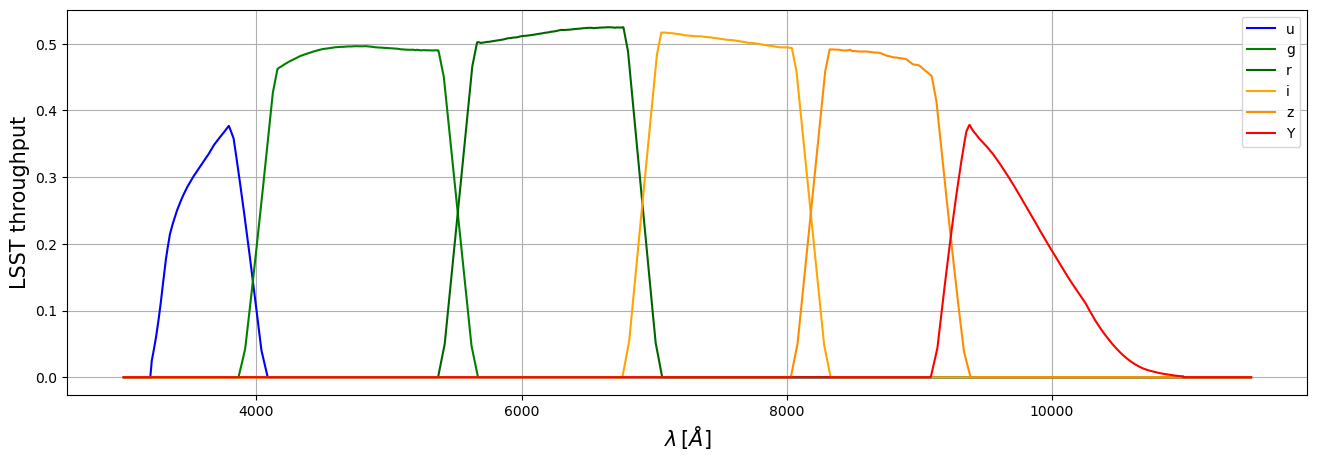

In [10]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)
for index in range(len(lsst_bp0)):
    ax.plot(lsst_bp0[index].wave,lsst_bp0[index].throughput,label=filter_names[index],color=filter_colors[index])
    
ax.grid()
plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
plt.ylabel('LSST throughput',fontsize=15)
plt.legend()

In [11]:
for filter in lsst_bp0:
    assert (filter.wave==lsst_bp0[0].wave).all()

In [12]:
wl_lsst = lsst_bp0[0].wave

# Load Euclid's filters 

In [13]:
euclid_path = './data/euclid/'

euclid_file_Y = 'NISP-PHOTO-PASSBANDS-V1-Y_throughput.dat'
euclid_file_J = 'NISP-PHOTO-PASSBANDS-V1-J_throughput.dat'
euclid_file_H = 'NISP-PHOTO-PASSBANDS-V1-H_throughput.dat'

In [14]:
fYe = np.loadtxt(os.path.join(euclid_path,euclid_file_Y))
fJe = np.loadtxt(os.path.join(euclid_path,euclid_file_J))
fHe = np.loadtxt(os.path.join(euclid_path,euclid_file_H))

In [15]:
eu_filters = ['Ye','Je','He']
eu_colors = {'Ye':'grey','Je':'brown','He':'k'}

9050.0 12450.0
1.91012e-08 0.784344
10050.0 16950.0
-1.79183e-05 0.80494
14050.0 21450.0
-0.000125533 0.792756


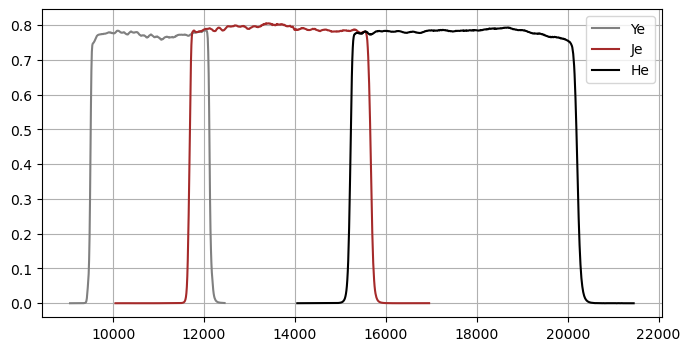

In [16]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)

for filter_ in eu_filters:
    f_ = eval('f{0}'.format(filter_))
    wl_ = f_[:,0]*10
    T_ = f_[:,1]
    ax.plot(wl_,T_,label=filter_,color=eu_colors[filter_])
    print(np.min(wl_),np.max(wl_))
    print(np.min(T_),np.max(T_))
    
ax.grid()
ax.legend(loc="best")

# Load SWIFT's filters 

Reference: https://arxiv.org/pdf/0811.1205 

Files: http://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?mode=browse&gname=Swift&asttype= 

In [17]:
swift_path = './data/swift/'

swift_file_uvw2 = 'Swift_UVOT.UVW2_fil.dat'
swift_file_uvm2 = 'Swift_UVOT.UVM2_fil.dat'
swift_file_uvw1 = 'Swift_UVOT.UVW1_fil.dat'

In [18]:
suvw2 = np.loadtxt(os.path.join(swift_path,swift_file_uvw2))
suvm2 = np.loadtxt(os.path.join(swift_path,swift_file_uvm2))
suvw1 = np.loadtxt(os.path.join(swift_path,swift_file_uvw1))

In [19]:
swift_filters = ['UVW2','UVM2','UVW1']
swift_colors = {'UVW2':'cyan','UVM2':'magenta','UVW1':'purple'}

1600.0 4310.0
0.00199501 0.43275
1600.0 3110.0
0.000999287 0.375385
1600.0 5970.0
0.00139696 0.40478


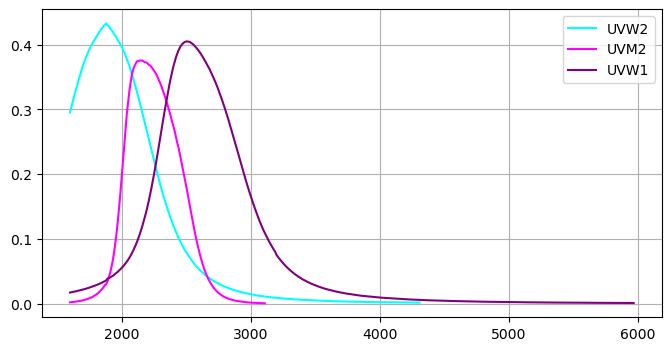

In [20]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)

for filter_ in swift_filters:
    f_ = eval('s{0}'.format(filter_.lower()))
    wl_ = f_[:,0]
    T_ = f_[:,1]
    ax.plot(wl_,T_,label=filter_,color=swift_colors[filter_])
    print(np.min(wl_),np.max(wl_))
    print(np.min(T_),np.max(T_))
    
ax.grid()
ax.legend(loc="best")

## Define common wavelength range 

In [21]:
wl_lsst[-1],wl_lsst[-2]

(11500.000000001932, 11499.000000001934)

In [22]:
eu_max_wls = []
for filter_ in eu_filters:
    f_ = eval('f{0}'.format(filter_))
    wl_ = f_[:,0]*10
    
    eu_max_wls.append(np.max(wl_))
    
eu_max_wl = np.max(np.array(eu_max_wls))
print(eu_max_wl)

21450.0


In [23]:
swift_min_wls = []
for filter_ in swift_filters:
    f_ = eval('s{0}'.format(filter_.lower()))
    wl_ = f_[:,0]
    
    swift_min_wls.append(np.min(wl_))
    
swift_min_wl = np.min(np.array(swift_min_wls))
print(swift_min_wl)

1600.0


## Define common wavelength, $\lambda_{baseline}$ 

In [24]:
dwl = np.unique(np.diff(lsst_bp0[0].wave))
np.mean(dwl)

1.000000000000273

### We introduce $\lambda_0$ and $\lambda_{\infty}$ for later purposes 

In [25]:
lambda_0 = 0.0
lambda_inf = 1e8

In [26]:
wl_baseline = np.arange(lambda_0+1.,eu_max_wl)
print(len(wl_baseline),wl_baseline[0],wl_baseline[-1])

21449 1.0 21449.0


In [27]:
wl_baseline

array([1.0000e+00, 2.0000e+00, 3.0000e+00, ..., 2.1447e+04, 2.1448e+04,
       2.1449e+04])

## Effective wavelengths 

For each filter we can define the effective wavelength, $\lambda_b^{eff}$, as 

$$\lambda_b^{eff} = \frac{\int \lambda \, T_{tel,b}(\lambda) \, d\lambda}{\int T_{tel,b}(\lambda) \, d\lambda} \, . $$

In [28]:
def calc_eff_lambda(T):
    assert (np.isnan(T.throughput)==True).any()==False
    
    wl_ = T.wave
    trans_ = T.throughput
    
    num_ = np.trapz(wl_*trans_,x=wl_)
    den_ = np.trapz(trans_,x=wl_)
    
    return num_/den_

# Interpolate all filters to evaluate them at $\lambda_{baseline}$ 

In [29]:
lsst_bp = []
eff_lambda = {}
for fi_ in range(len(filters)):
    print(filters[fi_])
    wl_ = lsst_bp0[fi_].wave
    T_ = lsst_bp0[fi_].throughput
    T_[T_<=1e-3] = 0.
    print(len(wl_),len(T_))
    
    finterp_ = interp1d(wl_,T_,bounds_error=False,fill_value=0.)
    T_2 = finterp_(wl_baseline)
    
    lsst_i = S.ArrayBandpass(wl_baseline,T_2, name='LSST {0}'.format(filters[fi_]))
    assert (lsst_i.wave==wl_baseline).all()
    lsst_bp.append(lsst_i)
    eff_wl_ = calc_eff_lambda(lsst_i)
    eff_lambda[filters[fi_]] = eff_wl_
    assert str(lsst_i.waveunits)==waveunits
    

u
8501 8501
g
8501 8501
r
8501 8501
i
8501 8501
z
8501 8501
Y
8501 8501


In [30]:
eff_lambda

{'u': 3646.662679925946,
 'g': 4775.691487833466,
 'r': 6221.859926396509,
 'i': 7538.740989090991,
 'z': 8695.989678941447,
 'Y': 9703.267866775377}

<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_39740/1497953944.py:7: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


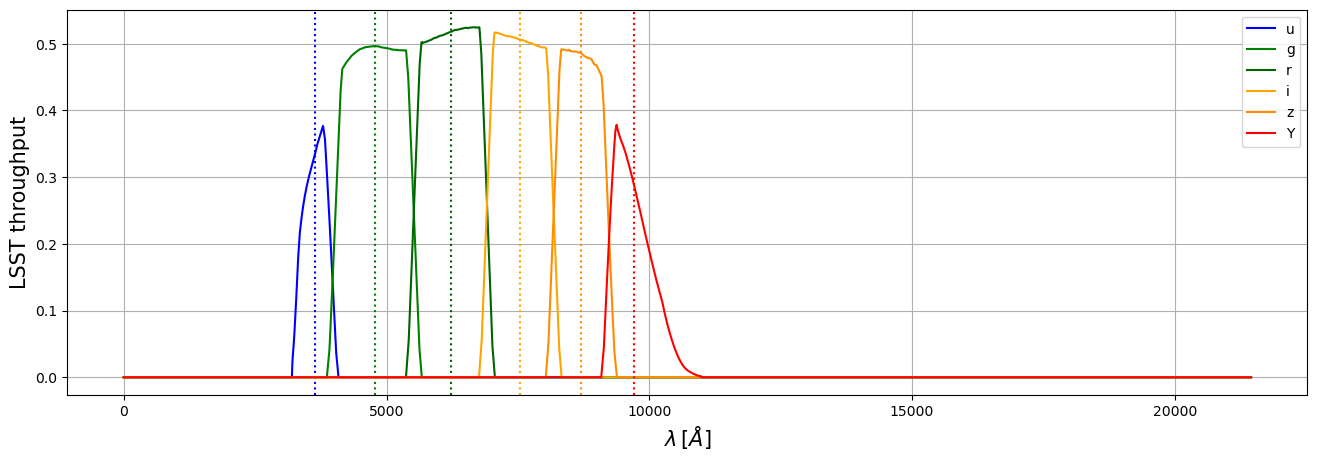

In [31]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)
for i,filter in enumerate(filters):
    ax.plot(lsst_bp[i].wave,lsst_bp[i].throughput,label=filter_names[i],color=filter_colors[i])
    ax.axvline(x=eff_lambda[filter],ls=':',color=filter_colors[i],alpha=1.0)
ax.grid()
plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
plt.ylabel('LSST throughput',fontsize=15)
plt.legend()

In [32]:
euclid_bp = []
eu_eff_lambda = {}
for filter_ in eu_filters:
    print(filter_)
    f_ = eval('f{0}'.format(filter_))
    wl_ = f_[:,0]*10
    T_ = f_[:,1]
    T_[T_<=1e-3] = 0.
    print(len(wl_),len(T_))
    
    finterp_ = interp1d(wl_,T_,bounds_error=False,fill_value=0.)
    T_2 = finterp_(wl_baseline)
    
    eu_i = S.ArrayBandpass(wl_baseline,T_2, name='Euclid {0}'.format(filter_))
    assert (eu_i.wave==wl_baseline).all()
    eu_eff_wl_ = calc_eff_lambda(eu_i)
    eu_eff_lambda[filter_] = eu_eff_wl_
    assert str(eu_i.waveunits)==waveunits
    euclid_bp.append(eu_i)


Ye
341 341
Je
691 691
He
741 741


In [33]:
eu_eff_lambda

{'Ye': 10812.418203760846, 'Je': 13669.513885076847, 'He': 17707.85747696563}

In [34]:
euclid_bp[0].wave.max()

21449.0

In [35]:
swift_bp = []
swift_eff_lambda = {}
for filter_ in swift_filters:
    print(filter_)
    f_ = eval('s{0}'.format(filter_.lower()))
    wl_ = f_[:,0]
    T_ = f_[:,1]
    T_[T_<=1e-3] = 0.
    print(len(wl_),len(T_))
    
    finterp_ = interp1d(wl_,T_,bounds_error=False,fill_value=0.)
    T_2 = finterp_(wl_baseline)
    
    s_i = S.ArrayBandpass(wl_baseline,T_2, name='SWIFT {0}'.format(filter_))
    assert (s_i.wave==wl_baseline).all()
    swift_eff_wl_ = calc_eff_lambda(s_i)
    swift_eff_lambda[filter_] = swift_eff_wl_
    assert str(s_i.waveunits)==waveunits
    swift_bp.append(s_i)


UVW2
272 272
UVM2
152 152
UVW1
438 438


In [36]:
swift_eff_lambda

{'UVW2': 2048.1172088131475,
 'UVM2': 2254.554140044102,
 'UVW1': 2676.8884517473484}

In [37]:
swift_bp[0].wave.min()

1.0

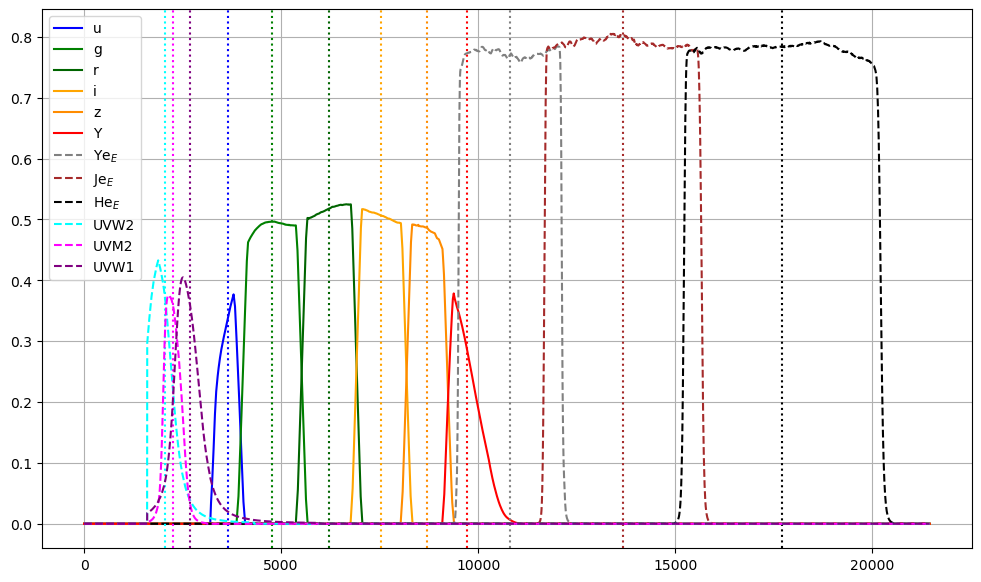

In [38]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

for i,filter_ in enumerate(filters):
    ax.plot(lsst_bp[i].wave,lsst_bp[i].throughput,label=filter_names[i],color=filter_colors[i])
    ax.axvline(x=eff_lambda[filter_],ls=':',color=filter_colors[i],alpha=1.0)
    
for i,filter_ in enumerate(eu_filters):
    ax.plot(euclid_bp[i].wave,euclid_bp[i].throughput,ls='--',color=eu_colors[filter_],label=filter_+r'$_E$')
    ax.axvline(x=eu_eff_lambda[filter_],ls=':',color=eu_colors[filter_],alpha=1.0)
    
for i,filter_ in enumerate(swift_filters):
    ax.plot(swift_bp[i].wave,swift_bp[i].throughput,ls='--',color=swift_colors[filter_],label=filter_)
    ax.axvline(x=swift_eff_lambda[filter_],ls=':',color=swift_colors[filter_],alpha=1.0)
    
ax.grid()
ax.legend(loc="best")

## Overlap wavelengths 

For each pair of filters we can define the overlap wavelength, $\hat{\lambda}_{b_1}$, as 

$$\hat{\lambda}_{b_1} = \frac{\int \lambda \, T_{tel,b_1}(\lambda) \, T_{tel,b_2}(\lambda) \, d\lambda}{\int T_{tel,b_1}(\lambda) \, T_{tel,b_2}(\lambda) \, d\lambda} \, . $$

In [39]:
def calc_overlap_lambda(T1,T2):
    assert (np.isnan(T1.throughput)==True).any()==False
    assert (np.isnan(T2.throughput)==True).any()==False
    
    assert (T1.wave==T2.wave).all()
    
    wl_ = T1.wave
    trans1_ = T1.throughput
    trans2_ = T2.throughput
    
    num_ = np.trapz(wl_*trans1_*trans2_,x=wl_)
    den_ = np.trapz(trans1_*trans2_,x=wl_)
    
    return num_/den_

In [40]:
all_bp = swift_bp+lsst_bp+euclid_bp
all_filters = swift_filters+filters+eu_filters

over_lambda = {}
for fi_ in range(len(all_bp)-1):
    
    pb_1_ = all_bp[fi_]
    pb_2_ = all_bp[fi_+1]
    over_wl_ = calc_overlap_lambda(pb_1_,pb_2_)
    over_lambda[all_filters[fi_]] = over_wl_
    

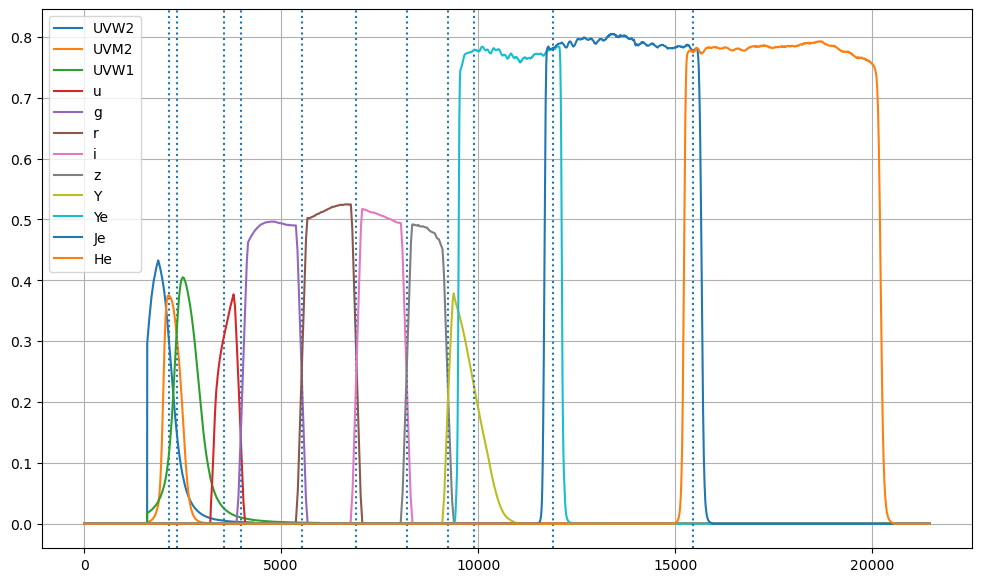

In [41]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

for i in range(len(all_filters)-1):
    ax.plot(all_bp[i].wave,all_bp[i].throughput,label=all_filters[i])
    ax.axvline(x=over_lambda[all_filters[i]],ls=':',alpha=1.0)
ax.plot(euclid_bp[-1].wave,euclid_bp[-1].throughput,label=eu_filters[-1])

ax.grid()
ax.legend(loc="best")

In [42]:
over_lambda

{'UVW2': 2161.465483268082,
 'UVM2': 2360.6981769690046,
 'UVW1': 3549.013668763476,
 'u': 3977.0063597990943,
 'g': 5520.333550251726,
 'r': 6909.852254990963,
 'i': 8180.049481029574,
 'z': 9230.428697471196,
 'Y': 9881.168570719628,
 'Ye': 11902.636862925166,
 'Je': 15441.641295084075}

## Create synthetic filters 

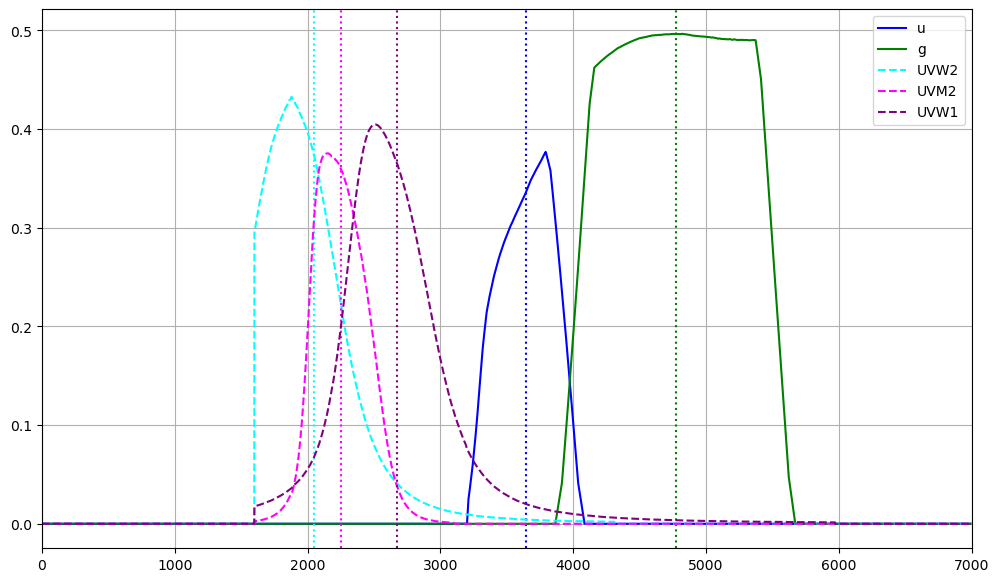

In [43]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

for i,filter_ in enumerate(filters[:2]):
    ax.plot(lsst_bp[i].wave,lsst_bp[i].throughput,label=filter_names[i],color=filter_colors[i])
    ax.axvline(x=eff_lambda[filter_],ls=':',color=filter_colors[i],alpha=1.0)
    
for i,filter_ in enumerate(swift_filters):
    ax.plot(swift_bp[i].wave,swift_bp[i].throughput,ls='--',color=swift_colors[filter_],label=filter_)
    ax.axvline(x=swift_eff_lambda[filter_],ls=':',color=swift_colors[filter_],alpha=1.0)
    
ax.set_xlim(0.,7000.)
ax.grid()
ax.legend(loc="best")

In [44]:
def gauss_filter(l,A,mu,sigma):
    gauss_ = A*np.exp((-(l-mu)**2.)/(2.*sigma**2.))
    return gauss_

In [45]:
max_gauss = 0.8
sigma_gauss = 40.

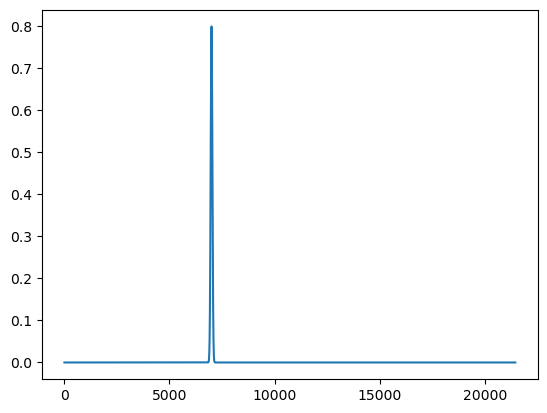

In [46]:
plt.plot(wl_baseline,gauss_filter(wl_baseline,max_gauss,7000.,sigma_gauss))

In [47]:
N_gauss = 5
wl_range_gauss = np.linspace(swift_eff_lambda['UVW2'],0.75*eff_lambda['u'],N_gauss)
Nsynth = len(wl_range_gauss)
wl_range_gauss,Nsynth

(array([2048.11720881, 2219.8371591 , 2391.55710938, 2563.27705966,
        2734.99700994]),
 5)

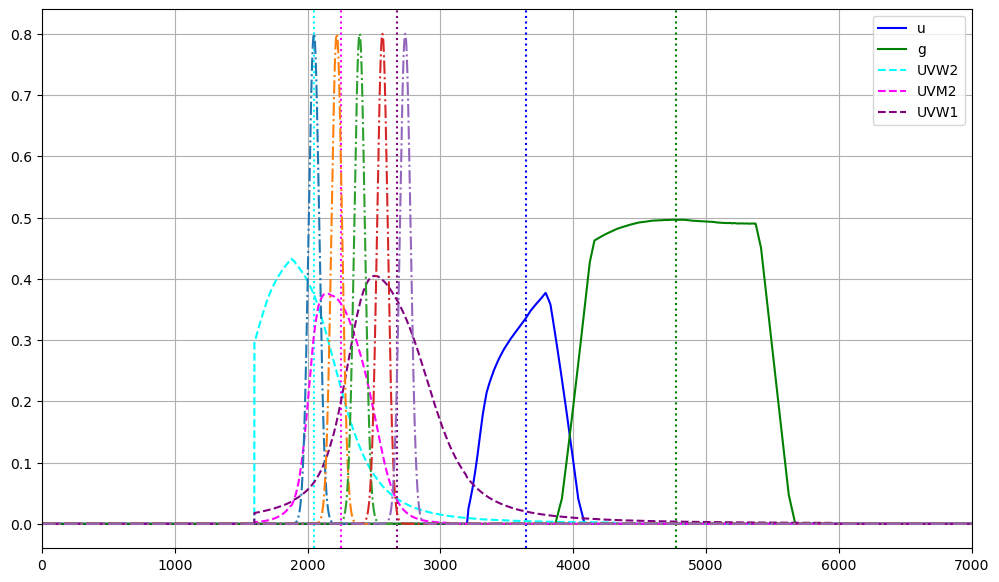

In [48]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

for i,filter_ in enumerate(filters[:2]):
    ax.plot(lsst_bp[i].wave,lsst_bp[i].throughput,label=filter_names[i],color=filter_colors[i])
    ax.axvline(x=eff_lambda[filter_],ls=':',color=filter_colors[i],alpha=1.0)
    
for i,filter_ in enumerate(swift_filters):
    ax.plot(swift_bp[i].wave,swift_bp[i].throughput,ls='--',color=swift_colors[filter_],label=filter_)
    ax.axvline(x=swift_eff_lambda[filter_],ls=':',color=swift_colors[filter_],alpha=1.0)
    
for wl_ in wl_range_gauss:
    ax.plot(wl_baseline,gauss_filter(wl_baseline,max_gauss,wl_,sigma_gauss),ls='-.')

ax.set_xlim(0.,7000.)
ax.grid()
ax.legend(loc="best")

### Set the Gaussian filters in pysynphot format 

In [49]:
gauss_filters = []
gauss_bp = []
gauss_eff_lambda = {}
for i,wl_ in enumerate(wl_range_gauss):
    gauss_i = S.ArrayBandpass(wl_baseline,gauss_filter(wl_baseline,max_gauss,wl_,sigma_gauss),name='Gauss {0}'.format(i))
    assert (gauss_i.wave==wl_baseline).all()
    gauss_eff_wl_ = calc_eff_lambda(gauss_i)
    gauss_eff_lambda['gauss_{0}'.format(i)] = gauss_eff_wl_
    assert str(gauss_i.waveunits)==waveunits
    gauss_filters.append('gauss_{0}'.format(i))
    gauss_bp.append(gauss_i)

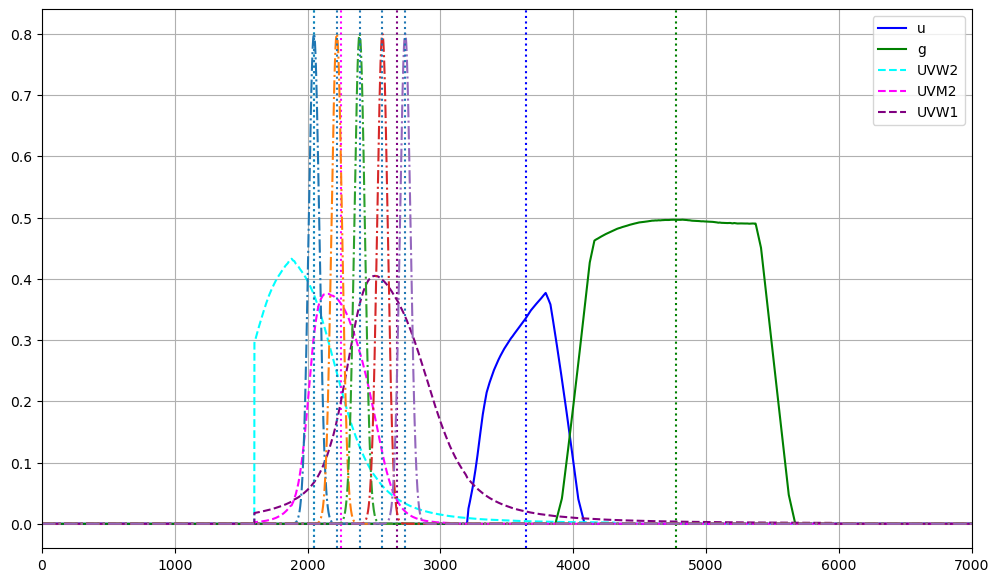

In [50]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

for i,filter_ in enumerate(filters[:2]):
    ax.plot(lsst_bp[i].wave,lsst_bp[i].throughput,label=filter_names[i],color=filter_colors[i])
    ax.axvline(x=eff_lambda[filter_],ls=':',color=filter_colors[i],alpha=1.0)
    
for i,filter_ in enumerate(swift_filters):
    ax.plot(swift_bp[i].wave,swift_bp[i].throughput,ls='--',color=swift_colors[filter_],label=filter_)
    ax.axvline(x=swift_eff_lambda[filter_],ls=':',color=swift_colors[filter_],alpha=1.0)
    
for i,filter_ in enumerate(gauss_filters):
    ax.plot(gauss_bp[i].wave,gauss_bp[i].throughput,ls='-.')
    ax.axvline(x=gauss_eff_lambda[filter_],ls=':',alpha=1.0)

ax.set_xlim(0.,7000.)
ax.grid()
ax.legend(loc="best")

# Load simulated transparencies 

Select variable parameter and specify airmass and clouds 

In [51]:
variable_param = 'pwv'
am0 = 1.2
cloud0 = 0.0
pwv0 = 3.0
aero0 = 0.04

Specify which distribution follows the simulated parameter. Options: 
* linear_distribution-discrete: generated following a linear function and with pre-established step (e.g., PWV = 1.0, 2.0, 3.0, ....) 
* linear_distribution-continuous: generated following a linear function and specifying only the value range and number of simulations (e.g., PWV = 1.0, 1.25, 1.5, ....) 
* uniform_distribution: generated following a uniform random distribution (work in progress) 
* specific_distribution: generated following random distributions specific to each parameter (work in progress) 


In [52]:
param_dist = 'linear_distribution-discrete'

In [53]:
outdir_plots_ = os.path.join('output_plots/',param_dist.split('-')[0])
if os.path.exists(outdir_plots_)==False:
    os.mkdir(outdir_plots_)

outdir_plots = os.path.join('output_plots/',param_dist.replace('-','/'))
if os.path.exists(outdir_plots)==False:
    os.mkdir(outdir_plots)

In [54]:
if variable_param=='airmass' or variable_param=='cloud':
    t_file = 'simulated_transparencies_varying_{0}.fits'.format(variable_param)
    t_file_ref = 'simulated_transparencies_varying_{0}_ref.fits'.format(variable_param)
else:
    t_file = 'simulated_transparencies_varying_{0}_airmass_{1}_cloud_{2}.fits'.format(variable_param,am0,cloud0)
    t_file_ref = 'simulated_transparencies_varying_{0}_airmass_{1}_cloud_{2}_ref.fits'.format(variable_param,am0,cloud0)

t_path = os.path.join('./simulated_transparencies/',param_dist.replace('-','/'))
t_in = os.path.join(t_path,t_file)
t_in_ref = os.path.join(t_path,t_file_ref)
t = fits.open(t_in)
t_ref = fits.open(t_in_ref)

In [55]:
head = t[0].header
data = t[0].data
print(data.shape)
data_ref = t_ref[0].data
print(data_ref.shape)

(10, 956)
(2, 956)


In [56]:
n_atmp = head['ID_RES']
n_sim = head['NTRANSP']
print(n_atmp, n_sim)

5 9


In [57]:
wl_t = data[0][n_atmp:]*10.

<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_39740/3796105917.py:8: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)


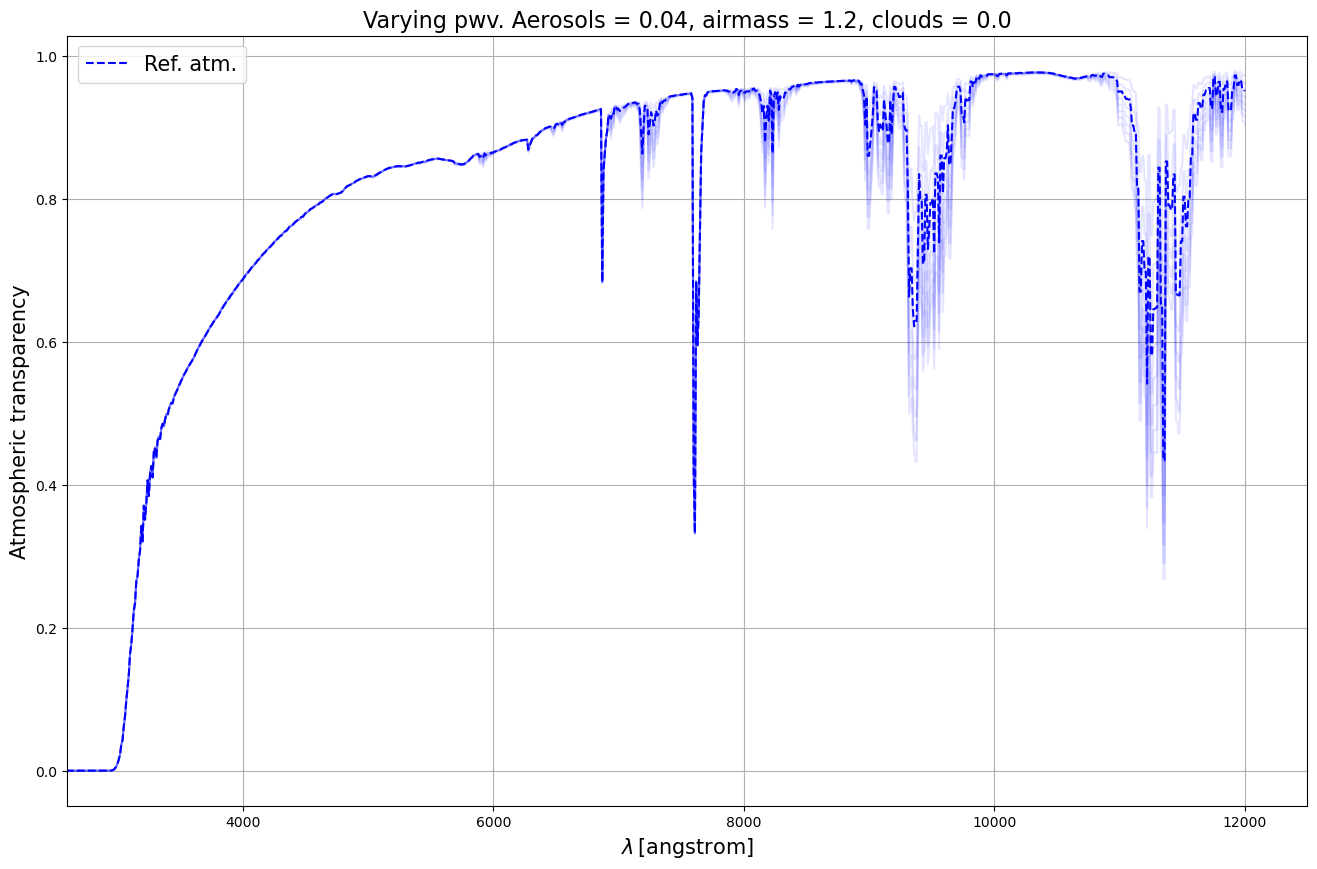

In [58]:
fig=plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)
for atm_i in range(1,n_sim):
    ax.plot(wl_t,data[atm_i][n_atmp:],color='b',alpha=0.1)
ax.plot(wl_t,data_ref[1][n_atmp:],ls='--',color='b',label='Ref. atm.')
plt.xlim(2600.,12500.)
plt.grid()
plt.xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)
plt.ylabel('Atmospheric transparency',fontsize=15)
plt.title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
plt.legend(fontsize=15)
plt.savefig(os.path.join(outdir_plots,'atm_transparencies_varying_{0}_airmass_{1}_clouds_{2}.png'.format(variable_param,am0,cloud0)))

# Check range of values of variable parameter 

In [59]:
print(head)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  956                                                  NAXIS2  =                   10                                                  NTRANSP =                    9                                                  ID_AM   =                    4                                                  ID_VAOD =                    1                                                  ID_PWV  =                    0                                                  ID_O3   =                    2                                                  ID_CLD  =                    3                                                  ID_RES  =                    5                                                  END                                     

In [60]:
params_index = {'pwv':0,'aerosol':1,'ozone':2,'cloud':3,'airmass':4}

In [61]:
var_index = params_index[variable_param]

In [62]:
#data[1:,1]
data[1:,var_index]

array([1., 2., 3., 4., 5., 6., 7., 8., 9.], dtype='>f8')

# Select data for variable parameter of these simulations 

In [63]:
atm_vals = data[1:,var_index]

In [64]:
np.save('output_files/atm_vals_{0}_airmass_{1}_cloud_{2}.npy'.format(variable_param,am0,cloud0),atm_vals)

# Convert simulated transparencies into pysynphot format 

In [65]:
atm_transp = []
for i in range(1,n_sim+1):
    finterp_i = interp1d(wl_t,data[i][n_atmp:],bounds_error=False,fill_value=0.)
    atm_interp_i = finterp_i(wl_baseline)
    #atm_i = S.ArrayBandpass(wl_t,data[i][n_atmp:], name='Atm. transp. {0}'.format(i))
    atm_i = S.ArrayBandpass(wl_baseline,atm_interp_i, name='Atm. transp. {0}'.format(i))
    assert str(atm_i.waveunits)==waveunits
    atm_transp.append(atm_i)

In [66]:
finterp_ref = interp1d(wl_t,data_ref[1][n_atmp:],bounds_error=False,fill_value=0.)
atm_interp_ref = finterp_ref(wl_baseline)
#atm_i = S.ArrayBandpass(wl_t,data[i][n_atmp:], name='Atm. transp. {0}'.format(i))
atm_transp_ref = S.ArrayBandpass(wl_baseline,atm_interp_ref, name='Atm. transp. {0}'.format(i))
assert str(atm_transp_ref.waveunits)==waveunits

<>:8: SyntaxWarning: invalid escape sequence '\,'
<>:8: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_39740/3941418067.py:8: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)


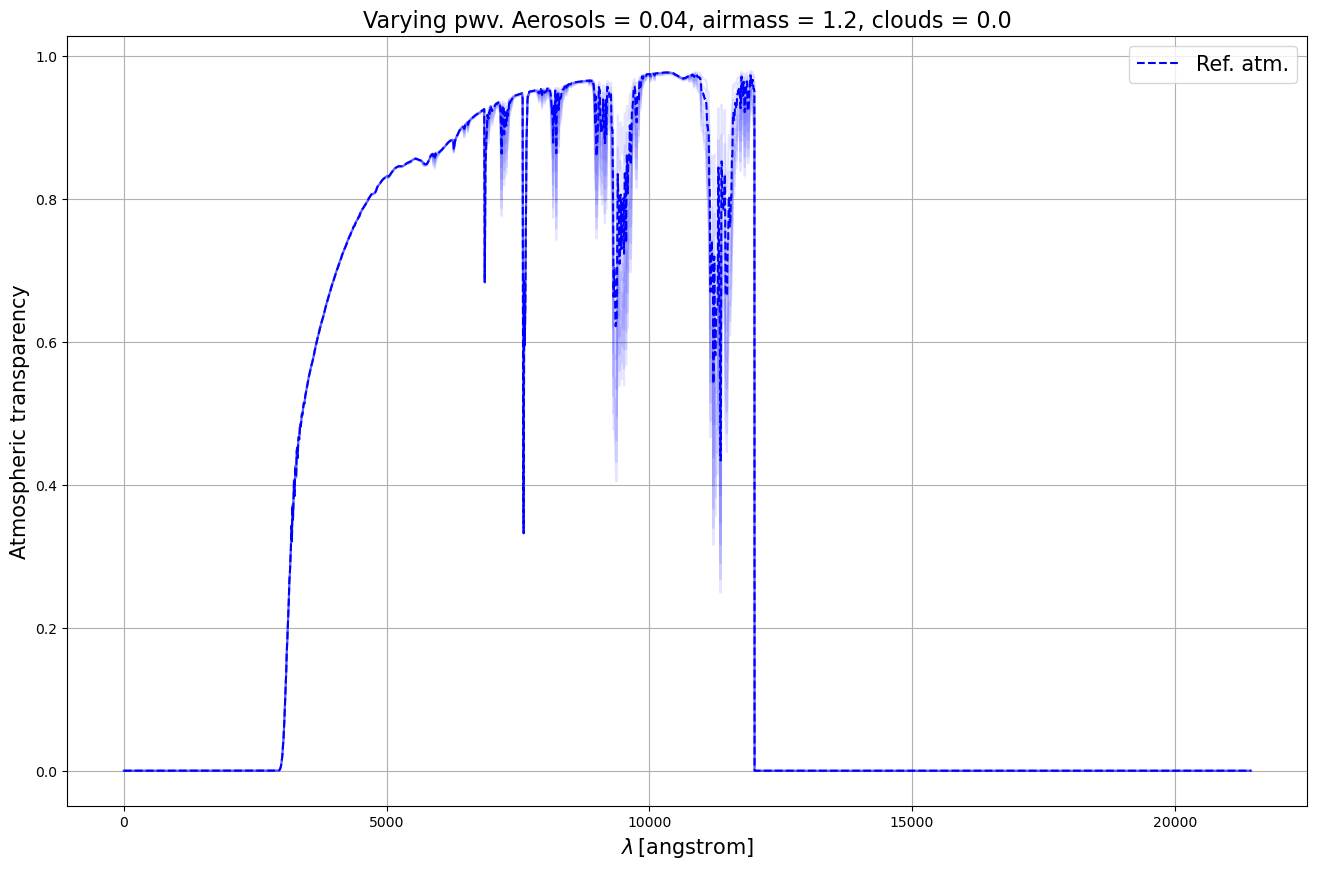

In [67]:
fig=plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)
for i in range(n_sim):
    ax.plot(atm_transp[i].wave,atm_transp[i].throughput,color='b',alpha=0.1)
ax.plot(atm_transp_ref.wave,atm_transp_ref.throughput,ls='--',color='b',label='Ref. atm.')
#plt.xlim(2600.,12500.)
ax.grid()
ax.set_xlabel('$\\lambda \,$'+'[angstrom]',fontsize=15)
ax.set_ylabel('Atmospheric transparency',fontsize=15)
ax.set_title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
ax.legend(fontsize=15)

# Compute total bandpass (atmosphere(s) x LSST throughput) 

In [68]:
total_passband = {}
#for bpname in filters:
#    total_passband[bpname] = []

for index,bp in enumerate(lsst_bp):
    total_passband[filters[index]] = []
    for i in range(n_sim):
        total_pass = bp*atm_transp[i]
        total_passband[filters[index]].append(total_pass)

In [69]:
total_passband_ref = {}
for index,bp in enumerate(lsst_bp):
    total_pass = bp*atm_transp_ref
    total_passband_ref[filters[index]] = total_pass

In [70]:
print(len(total_passband['u']))
print(total_passband['u'][0])

9
(LSST u * Atm. transp. 1)


<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_39740/3034339531.py:13: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


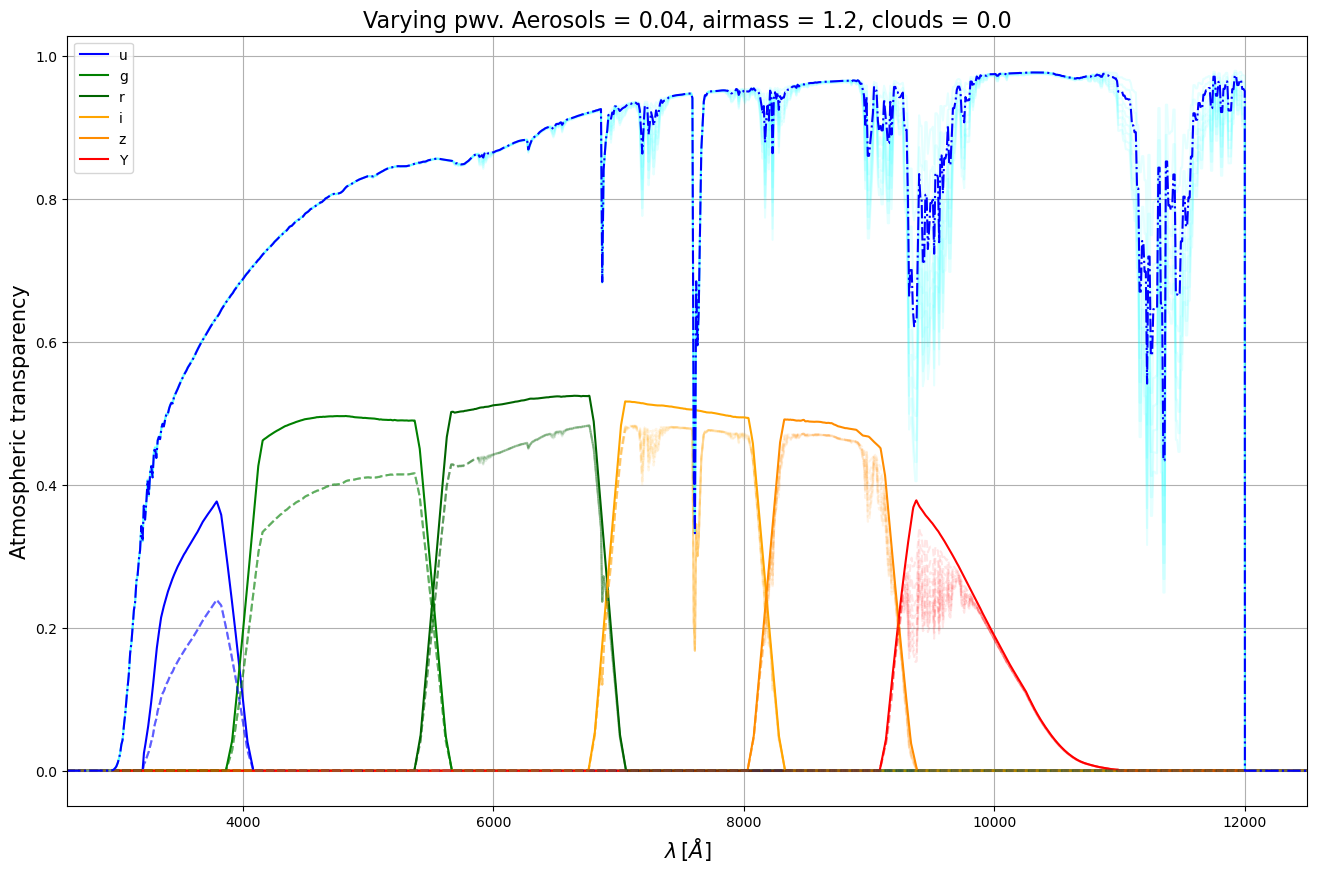

In [71]:
fig=plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)
for index,bp in enumerate(lsst_bp):
    ax.plot(bp.wave,bp.throughput,label=filter_names[index],color=filter_colors[index])

for isim in range(n_sim):
    ax.plot(atm_transp[isim].wave,atm_transp[isim].throughput,alpha=0.1,color='cyan')
    for index,bpname in enumerate(filters):
        ax.plot(total_passband[bpname][isim].wave,total_passband[bpname][isim].throughput,ls='--',color=filter_colors[index],alpha=0.1)
ax.plot(atm_transp_ref.wave,atm_transp_ref.throughput,ls='-.',color='b')        
plt.xlim(2600.,12500.)
plt.grid()
plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
plt.ylabel('Atmospheric transparency',fontsize=15)
plt.legend()
plt.title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
plt.savefig(os.path.join(outdir_plots,'total_passbands_varying_{0}_airmass_{1}_clouds_{2}.png'.format(variable_param,am0,cloud0)))

Plot the atmospheric transparencies corresponding to the minimum and maximum atmospheric parameter that we are varying: 

In [72]:
min_val_ = np.min(atm_vals)
max_val_ = np.max(atm_vals)
ref_val_ = eval('{0}0'.format(variable_param))
print(min_val_,max_val_,ref_val_)

1.0 9.0 3.0


In [73]:
min_ind_ = np.where(atm_vals==min_val_)[0][0]
max_ind_ = np.where(atm_vals==max_val_)[0][0]
ref_ind_ = np.where(atm_vals==ref_val_)[0][0]

In [74]:
atm_transp[min_ind_].throughput

array([0., 0., 0., ..., 0., 0., 0.])

In [75]:
min_transp = atm_transp[min_ind_]
max_transp = atm_transp[max_ind_]
ref_transp = atm_transp[ref_ind_]

<>:5: SyntaxWarning: invalid escape sequence '\,'
<>:5: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_39740/667698375.py:5: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)


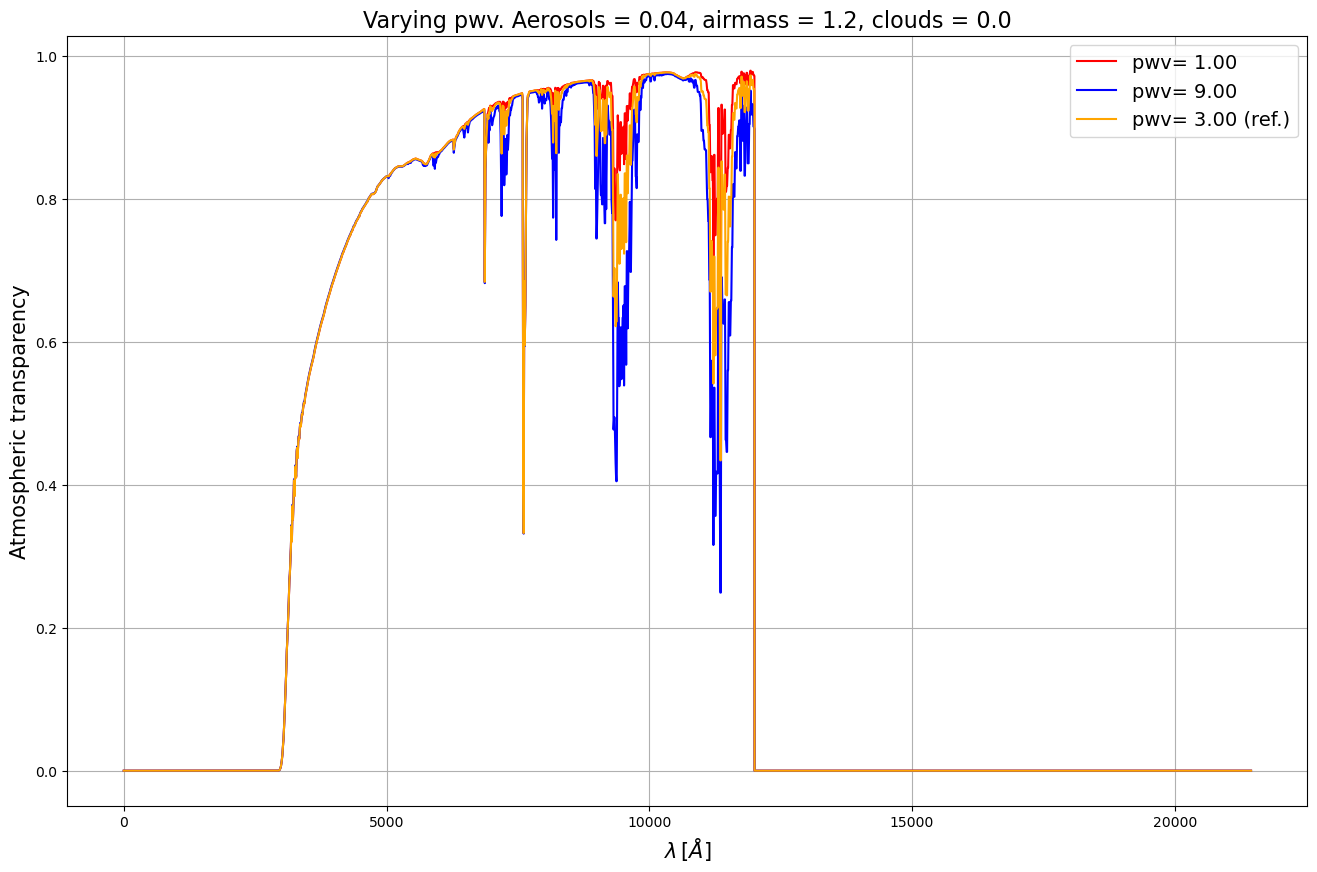

In [76]:
fig=plt.figure(figsize=(16,10))
plt.plot(min_transp.wave,min_transp.throughput,color='r',label=variable_param+'= {0:.2f}'.format(min_val_))
plt.plot(max_transp.wave,max_transp.throughput,color='b',label=variable_param+'= {0:.2f}'.format(max_val_))
plt.plot(ref_transp.wave,ref_transp.throughput,color='orange',label=variable_param+'= {0:.2f} (ref.)'.format(ref_val_))
plt.xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
plt.ylabel('Atmospheric transparency',fontsize=15)
plt.grid()
plt.legend(fontsize=14)
plt.title('Varying {0}. Aerosols = {1}, airmass = {2}, clouds = {3}'.format(variable_param,aero0,am0,cloud0),fontsize=16)
plt.savefig(os.path.join(outdir_plots,'atm_transparencies_varying_{0}_airmass_{1}_clouds_{2}_min_max_values.png'.format(variable_param,am0,cloud0)))

# Define paths to spectral atlases 

In [77]:
pysynphot_root_path=os.environ['PYSYN_CDBS']
path_dict = {
    'calspec':os.path.join(pysynphot_root_path,'calspec'),
    'bpgs':os.path.join(pysynphot_root_path,'grid/bpgs'),
    'jacoby':os.path.join(pysynphot_root_path,'grid/jacobi'),
    'pickles':os.path.join(pysynphot_root_path,'grid/pickles/dat_uvk')
}

atlas_dir = 'spectral_atlases/'
file_dict = {
    'calspec':'',
    'bpgs':os.path.join(atlas_dir,'atlas_bpgs.txt'),
    'jacoby':os.path.join(atlas_dir,'atlas_jacoby.txt'),
    'pickles':os.path.join(atlas_dir,'atlas_pickles.txt')
}


# Select a spectral atlas 

Options: 
* calspec (HST calibration spectra): work in progress, need to separate stars from AGNs and other sources 
* bpgs (Bruzual-Persson-Gunn-Stryker): 175 spectra 
* jacobi (Jacoby-Hunter-Christian): 161 spectra 
* pickles (Pickles): 131 spectra 

In [78]:
atlas_name = 'pickles'

atlas_path = path_dict[atlas_name]
atlas_file = file_dict[atlas_name]

# Find the spectra files and information 

In [79]:
#path_sed_calspec=os.path.join(pysynphot_root_path,'calspec')
atlas_seds = pd.read_csv(atlas_file)
atlas_seds

,File,Type,Teff,Name
0,pickles_uk_1.fits,O5V,39810.70,unknown
1,pickles_uk_2.fits,O9V,35481.40,unknown
2,pickles_uk_3.fits,B0V,28183.80,unknown
3,pickles_uk_4.fits,B1V,22387.20,unknown
4,pickles_uk_5.fits,B3V,19054.60,unknown
...,...,...,...,...
126,pickles_uk_127.fits,G8I,4591.98,unknown
127,pickles_uk_128.fits,K2I,4255.98,unknown
128,pickles_uk_129.fits,K3I,NaN,unknown
129,pickles_uk_130.fits,K4I,3990.25,unknown


# Load with pysynphot the spectra from the selected atlas and interpolate to evaluate at $\lambda_{baseline}$ 

In [80]:
sed_list = np.array(atlas_seds['File'])
print(len(sed_list))

131


In [94]:
full_sed_dict = {}
type_dict = {}
wl_spec_0 = S.FileSpectrum(os.path.join(atlas_path,sed_list[0])).wave
wl_same = []
for i,sed in enumerate(sed_list):
    #print('-------')
    #print(sed)
    spec0_ = S.FileSpectrum(os.path.join(atlas_path,sed))
    spec0_.convert('photlam')
    #print(spec0_.fluxunits)
    assert str(spec0_.waveunits)==waveunits
    wl_same.append((spec0_.wave==wl_spec_0).all())
    finterp_ = interp1d(spec0_.wave,spec0_.flux,bounds_error=False,fill_value=0.)
    interp_spec_ = finterp_(wl_baseline)
    spec_ = S.ArraySpectrum(wl_baseline,interp_spec_)
    #spec_.convert('photlam')
    full_sed_dict[sed[:-5]] = spec_
    type_dict[sed[:-5]] = atlas_seds['Type'][i]
    
wl_same = np.array(wl_same)
print((wl_same==True).all())
#wl_spec = wl_spec_0

True


In [95]:
select_type = 'all'

In [96]:
sed_dict = {}

for key in type_dict:
    if select_type=='all':
        sed_dict = full_sed_dict
    else:
        if select_type in type_dict[key]:
            sed_dict[key] = full_sed_dict[key]

In [97]:
#sed_dict

In [98]:
example_id = 'pickles_uk_2'

In [99]:
#sed_dict = {example_id:sed_dict[example_id]}
#sed_dict

In [100]:
#type_dict = {example_id:type_dict[example_id]}
#type_dict

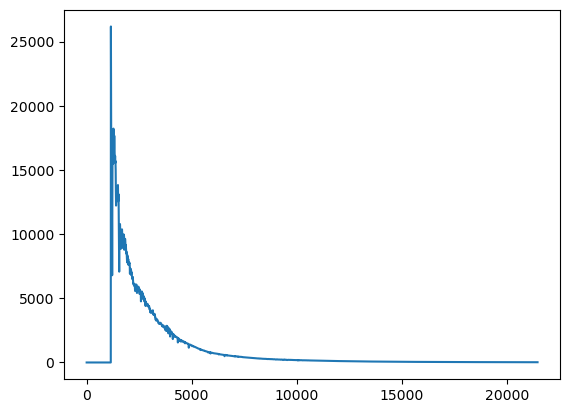

In [101]:
plt.plot(sed_dict[example_id].wave,sed_dict[example_id].flux)
sed_dict[example_id].fluxunits

In [102]:
sed_dict[example_id].wave

array([1.0000e+00, 2.0000e+00, 3.0000e+00, ..., 2.1447e+04, 2.1448e+04,
       2.1449e+04])

# Define also the spectral types 

In [103]:
spectral_types = ['O','B','A','F','G','K','M']
if select_type=='all':
    pass
else:
    spectral_types = list(select_type)
spectral_types

['O', 'B', 'A', 'F', 'G', 'K', 'M']

<img align="center" src = Stellar_Classification_Chart.png width=750 style="padding: 10px"> 

https://upload.wikimedia.org/wikipedia/commons/3/37/Stellar_Classification_Chart.png

# Organise spectra by spectral type 

In [104]:
spec_by_type = {}
for i in range(len(spectral_types)):
    spec_type = spectral_types[i]
    
    type_list_ = []
    spec_by_type[spec_type] = []
    for sed_ in type_dict.keys():
        if spec_type in type_dict[sed_]:
            type_list_.append(type_dict[sed_])
            spec_by_type[spec_type].append(sed_dict[sed_])
    print(spec_type, type_list_)
    print(len(type_list_))
    print('-----------')

O ['O5V', 'O9V', 'O8III']
3
-----------
B ['B0V', 'B1V', 'B3V', 'B57V', 'B8V', 'B9V', 'B2IV', 'B6IV', 'B12III', 'B3III', 'B5III', 'B9III', 'B2II', 'B5II', 'B0I', 'B1I', 'B3I', 'B5I', 'B8I']
19
-----------
A ['A0V', 'A2V', 'A3V', 'A5V', 'A7V', 'A0IV', 'A47IV', 'A0III', 'A3III', 'A5III', 'A7III', 'A0I', 'A2I']
13
-----------
F ['F0V', 'F2V', 'F5V', 'wF5V', 'F6V', 'rF6V', 'F8V', 'wF8V', 'rF8V', 'F02IV', 'F5IV', 'F8IV', 'F0III', 'F2III', 'F5III', 'F0II', 'F2II', 'F0I', 'F5I', 'F8I']
20
-----------
G ['G0V', 'wG0V', 'rG0V', 'G2V', 'G5V', 'wG5V', 'rG5V', 'G8V', 'G0IV', 'G2IV', 'G5IV', 'G8IV', 'G0III', 'G5III', 'wG5III', 'rG5III', 'G8III', 'wG8III', 'G5II', 'G0I', 'G2I', 'G5I', 'G8I']
23
-----------
K ['K0V', 'rK0V', 'K2V', 'K3V', 'K4V', 'K5V', 'K7V', 'K0IV', 'K1IV', 'K3IV', 'K0III', 'wK0III', 'rK0III', 'K1III', 'wK1III', 'rK1III', 'K2III', 'wK2III', 'rK2III', 'K3III', 'wK3III', 'rK3III', 'K4III', 'wK4III', 'rK4III', 'K5III', 'rK5III', 'K01II', 'K34II', 'K2I', 'K3I', 'K4I']
32
-----------
M [

Now we can plot them by spectral type separately 

In [105]:
type_colors = {'O':'b','B':'dodgerblue','A':'cyan','F':'g','G':'gold','K':'r','M':'brown'}

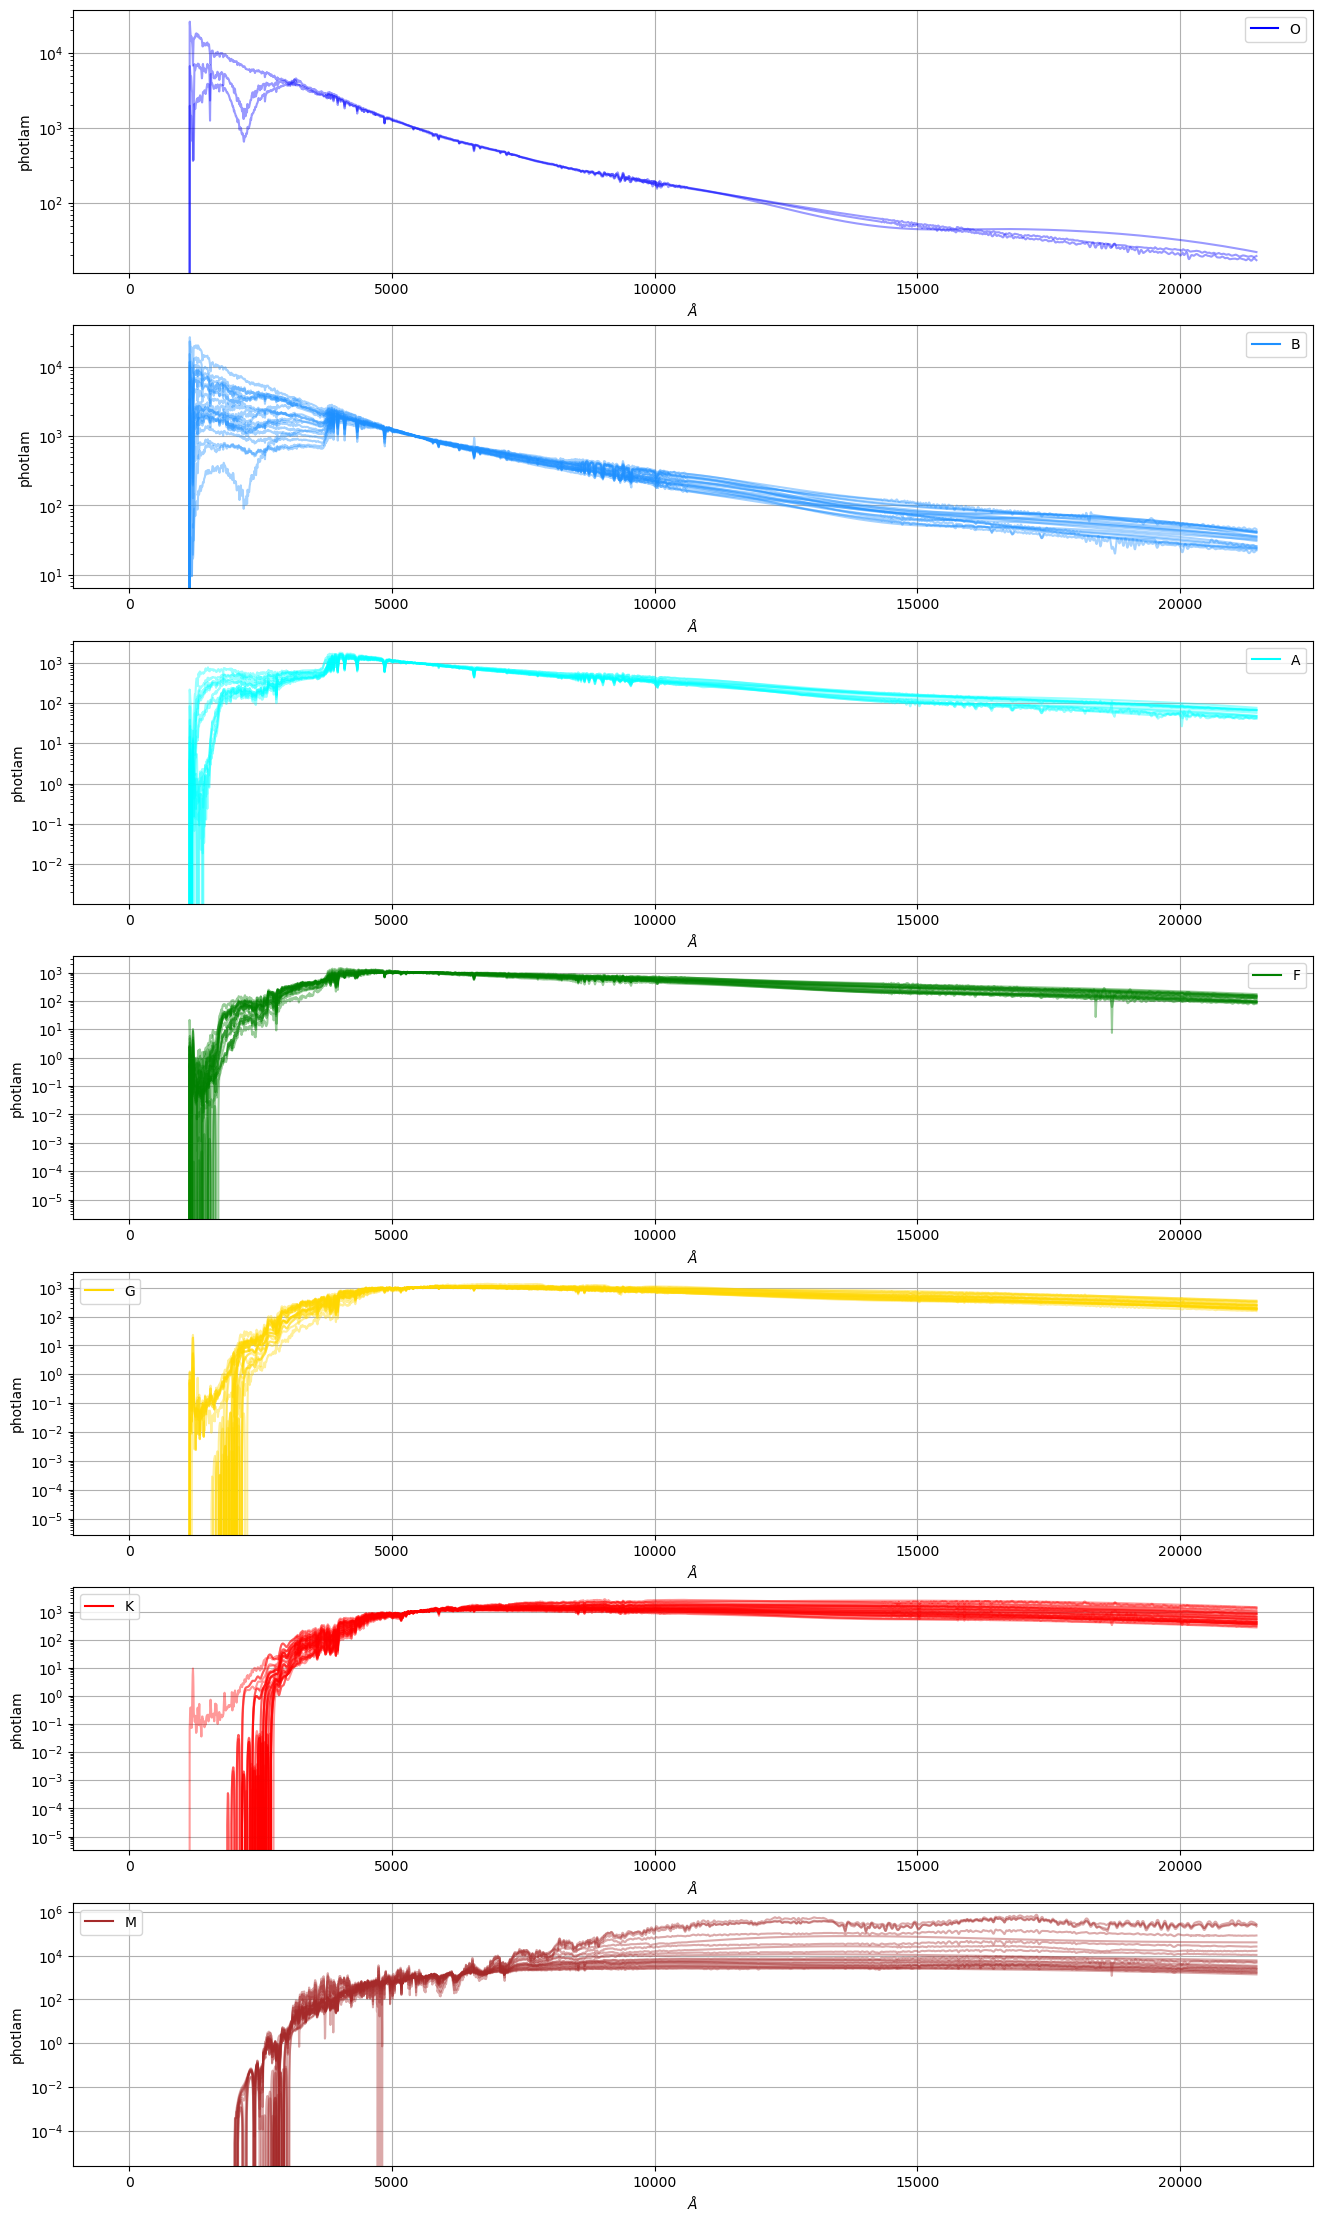

In [107]:
num_rows = len(spectral_types)
fig, axs = plt.subplots(num_rows, 1, figsize=(16,28))

for row,st in enumerate(spectral_types):
    for spec in spec_by_type[st]:
        spec.convert('photlam')
        axs[row].plot(spec.wave,spec.flux,color=type_colors[st],alpha=0.4)
    axs[row].plot([],[],label=st,color=type_colors[st])
    axs[row].grid()
    #axs[row].set_yscale("log")
    axs[row].set_xlabel(wavelabel)
    axs[row].set_ylabel(spec.fluxunits)
    axs[row].legend()
    #axs[row].set_xlim(3000,11000)
    #axs[row].set_ylim(10,10000)
    axs[row].set_yscale("log")
            

# Now we assign an ID to each object and we also classify these IDs by spectral type 

In [108]:
id_dict = {}
for i,sed in enumerate(sed_dict.keys()):
    #id_dict[sed[:-5]] = '{0}'.format(i+1).zfill(len(str(len(sed_list))))
    id_dict[sed] = '{0}'.format(i+1).zfill(len(str(len(sed_list))))

In [109]:
id_by_type = {}
for i in range(len(spectral_types)):
    spec_type = spectral_types[i]
    
    id_list_ = []
    id_by_type[spec_type] = []
    for sed_ in id_dict.keys():
        if spec_type in type_dict[sed_]:
            id_list_.append(id_dict[sed_])
            id_by_type[spec_type].append(sed_)
    print(spec_type, id_list_)
    print(len(id_list_))
    print('-----------')

O ['001', '002', '060']
3
-----------
B ['003', '004', '005', '006', '007', '008', '046', '047', '061', '062', '063', '064', '106', '107', '114', '115', '116', '117', '118']
19
-----------
A ['009', '010', '011', '012', '013', '048', '049', '065', '066', '067', '068', '119', '120']
13
-----------
F ['014', '015', '016', '017', '018', '019', '020', '021', '022', '050', '051', '052', '069', '070', '071', '108', '109', '121', '122', '123']
20
-----------
G ['023', '024', '025', '026', '027', '028', '029', '030', '053', '054', '055', '056', '072', '073', '074', '075', '076', '077', '110', '124', '125', '126', '127']
23
-----------
K ['031', '032', '033', '034', '035', '036', '037', '057', '058', '059', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '111', '112', '128', '129', '130']
32
-----------
M ['038', '039', '040', '041', '042', '043', '044', '045', '095', '096', '097', '098', '099', '100', '101', '102', '103', '

# Calculate fluxes through total passbands 

Let's start with one spectrum of a type A star as example 

In [110]:
# Example with one spectrum 
test_type = 'O'
test_spec = 0
example_spec = spec_by_type[test_type][test_spec]
example_id = id_by_type[test_type][test_spec]
print(example_spec,example_id)

UnnamedArraySpectrum pickles_uk_1


In [111]:
obs_flux_t_dict = {}
obs_flux_std_dict = {}

for ised in sed_dict.keys():
    #print(ised)
    sed_ = sed_dict[ised]
    
    obstotal_dict_ = {}
    for filter_ in filters:
        obstotal_dict_[filter_] = []

    for filter_ in filters:
        #print(filter.name.upper())
        for i in range(n_sim):
            #total_pass = filter*atm_transp[i]
            #obs = S.Observation(spec,total_pass,force='taper')
            obstotal_ = S.Observation(sed_,total_passband[filter_][i],force='taper')
            obstotal_dict_[filter_].append(obstotal_)
    
    obs_flux_t_dict[ised] = obstotal_dict_

    obstotal_dict_ref_ = {}
    for filter_ in filters:
        obstotal_ = S.Observation(sed_,total_passband_ref[filter_],force='taper')
        obstotal_dict_ref_[filter_] = obstotal_
        if ised=='pickles_uk_131':
            print(filter_,np.trapz(obstotal_.flux,x=obstotal_.wave))
        
    obs_flux_std_dict[ised] = obstotal_dict_ref_
    

u 4028.648580757757
g 309569.50636870385
r 980311.3494591
i 1944043.3907263537
z 2105783.4930687835
Y 1264389.0884283464


In [113]:
obs_flux_std_dict[example_id]['u'].wave

array([5.0000e-01, 1.0000e+00, 2.0000e+00, ..., 2.1448e+04, 2.1449e+04,
       2.1450e+04])

# Calculate magnitudes with our own function 

Physical constants 

In [114]:
c_light = S.units.C #speed of light [Angstrom /s] 
print(c_light)
h_planck = S.units.H #Planck's constant [erg*s] 
print(h_planck)

2.99792458e+18
6.6262e-27


In [122]:
# Reference flux value for an AB source in erg / s / cm2 / Hz 
f_ref = 3.631*10**(-20)

In [131]:
# Pivot wavelength [cm] 
wl_piv = 5.4929*10**(-5)
#wl_piv = 5.556*10**(-5)

In [133]:
C = f_ref/(h_planck*wl_piv*10**8.)
print(C)

997.6082135645418


Definition of functions 

In [134]:
# The SED of an AB source (that is, constant flux in frequency units) expressed in photons / s / cm^2 / Angstrom 
def ABnphot(wl):
    #return 997.2*5500./wl
    return C*wl_piv*10**8./wl

We check that this function actually creates a spectrum with the properties of an AB source, that is, a flat spectrum in fnu units (erg/s/cm2/Hz) 

Text(0, 0.5, 'Flux [Jy]')

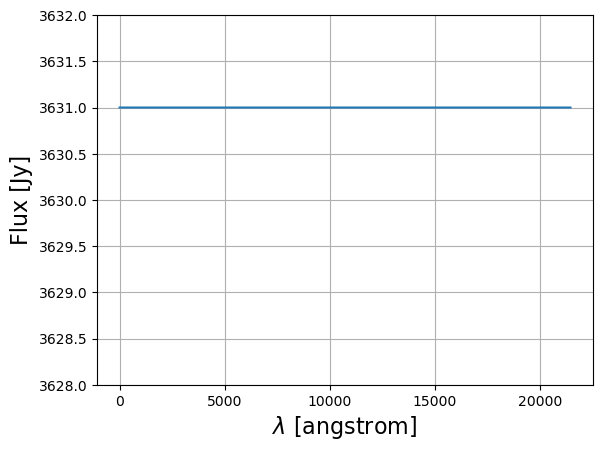

In [135]:
checkab = ABnphot(example_spec.wave)
checkab_ = S.ArraySpectrum(example_spec.wave, checkab, name='Flat AB spectrum')
#plt.plot(checkab_.wave,checkab_.flux)
checkab_.convert('fnu')
plt.plot(checkab_.wave,checkab_.flux*10**23.)
plt.ylim(3.628*10.**3,3.632*10**3.)
plt.grid()
plt.xlabel(r'$\lambda$ [angstrom]',fontsize=16)
plt.ylabel('Flux [Jy]',fontsize=16)

Now, we define our function to compute the AB magnitudes: 

$$m_{AB} = -2.5 \log_{10} \frac{\int F_{\nu}^E(\lambda) \cdot S_{eff} \cdot t_{exp} \cdot S_{passband}(\lambda) \frac{d\lambda}{h \lambda}}{\int F_{\nu, AB}^E \cdot S_{eff} \cdot t_{exp} \cdot S_{throughput}(\lambda) \frac{d\lambda}{h \lambda}} = -2.5 \log_{10} \frac{\varphi}{\Phi_{AB}} \, . $$ 

Now, we want to compute the error for the AB magnitudes. The denominator is constant for a given $S_{throughput}(\lambda)$, so we assume it does not contribute to the error. Then, we can approximate $\varphi$ as 

$$\varphi \approx \sum_i F_{\nu}^E(\lambda_i) \cdot S_{eff} \cdot t_{exp} \cdot S_{passband}(\lambda_i) \frac{\Delta \lambda_i}{h \lambda_i} = \sum_i n_i \cdot S_{passband}(\lambda_i) \cdot \Delta \lambda_i \, , $$ 

where $n_i$ is 

$$n_i = \frac{F_{\nu}^E(\lambda_i) \cdot S_{eff} \cdot t_{exp}}{h \lambda_i} \, ,$$

the number of photo-electrons received within a given bin of wavelength, $\Delta \lambda_i$. Then, we can assume that $n_i$ is a Poisson random variable, so 

$$\sigma^2_{n_i} = n_i . $$ 

Taking this into account, we can write the error of $\varphi$ as 

$$\sigma^2_{\varphi} = \sum_i \left( \frac{\partial \varphi}{\partial n_i} \right)^2 \sigma^2_{n_i} = \sum_i n_i \cdot \left( S_{passband}(\lambda_i) \cdot \Delta \lambda_i \right)^2 \, , $$ 

Finally, the error on $m_{AB}$ is given by 
$$\sigma^2_{m_{AB}} = \left( \frac{\partial m_{AB}}{\partial \varphi} \right)^2 \sigma^2_{\varphi} = \left( \frac{-2.5}{\varphi \log 10} \right)^2 \cdot \sum_i n_i \cdot \left( S_{passband}(\lambda_i) \cdot \Delta \lambda_i \right)^2 \, . $$ 


In [105]:
def int_flux(spec,passband,filter=None,input_funits='photlam',return_mag=False,return_error=False,
             PhiAB=None,renormalize=None,verbose=False):
    f_units = str(spec.fluxunits)
    assert f_units==input_funits
    if f_units!='fnu' and f_units!='photlam':
        if verbose:
            print('ATTENTION: converting flux units to fnu')
        spec.convert('fnu')
    f_units = str(spec.fluxunits)
    
    observation = S.Observation(spec,passband,force='taper')
    if verbose:
        print('Observation units = ', observation.fluxunits)
    nan_mask = np.isnan(observation.flux)
    
    obs_wave_ = observation.wave[~nan_mask]
    obs_flux_ = observation.flux[~nan_mask]
    
    
    if renormalize!=None:
        renorm = np.power(10.,-1.*renormalize/2.5)
    else:
        renorm = 1.0
    
    if f_units=='fnu':
        num = np.trapz(obs_flux_*renorm/obs_wave_,x=obs_wave_)*Seff*exptime/h_planck
    elif f_units=='photlam':
        num = np.trapz(obs_flux_*renorm,x=obs_wave_)*Seff*exptime
    
    if return_error:
        
        delta_lambda = list(np.diff(spec.wave))
        delta_lambda.append(spec.wave[-1]-spec.wave[-2])
        delta_lambda = np.array(delta_lambda)
        assert len(delta_lambda)==len(spec.wave)
        
        if f_units=='fnu':
            n_i = spec.flux*renorm*Seff*exptime/(spec.wave*h_planck)
        elif f_units=='photlam':
            n_i = spec.flux*renorm*Seff*exptime
        #print('n_i = ', n_i)
        err2_num = np.sum(n_i*(passband.throughput*delta_lambda)**2.)
    
    spec.convert(f_units)
    
    if verbose:
        print('Numerator = {0:.2e}'.format(num))
    if return_error and verbose:
        print('Variance of the numerator = {0:.2e}'.format(err2_num))
    
    if return_mag:
        
        if PhiAB is None:
            assert filter_ is not None
            flatsp_nphot = ABnphot(spec.wave)
            flatsp_ = S.ArraySpectrum(spec.wave, flatsp_nphot, name='Flat AB spectrum')

            flatsp_.convert('fnu')
            ab_obs = S.Observation(flatsp_,filter_,force='taper')
            if verbose:
                print('AB observation units = ', ab_obs.fluxunits)

            ab_wave_ = ab_obs.wave[~nan_mask]
            ab_flux_ = ab_obs.flux[~nan_mask]

            den = np.trapz(ab_flux_/ab_wave_,x=ab_wave_)*Seff*exptime/h_planck
        else:
            den = PhiAB
            if verbose:
                print('ATTENTION: using external Phi_AB. Not computing it')

        if verbose:
            print('Denominator = {0:.2e}'.format(den))
        mab = -2.5*np.log10(num/den)
        if verbose:
            print('AB magnitude = ', mab)
            print('---------')
    
    if return_mag==False:
        if return_error:
            return num,np.sqrt(err2_num)
        else:
            return num
    else:
        if return_error:
            err2_mab = ((2.5/(np.log(10.)*num))**2.)*err2_num
            err_mab = np.sqrt(err2_mab)
            return num,mab,np.sqrt(err2_num),err_mab
        else:
            return num,mab
    

To avoid computing $\Phi_{AB}$ each time, we define that integral once and we give it to our function each time it is needed 

In [106]:
flatsp_nphot = ABnphot(example_spec.wave)

In [107]:
flat_spec = S.ArraySpectrum(example_spec.wave, flatsp_nphot, name='Flat AB spectrum')

In [108]:
flat_spec.fluxunits

In [109]:
Phi_AB = []
for filter_ in lsst_bp:
    Phi_AB_b = int_flux(flat_spec,filter_)
    Phi_AB.append(Phi_AB_b)
    print(Phi_AB_b)
Phi_AB = np.array(Phi_AB)

3088380552010.815
8219700730652.069
6160604227593.574
4552576767524.609
3081702665648.3027
1647811503986.3528


In [110]:
for filter_ in lsst_bp:
    nn,mm = int_flux(flat_spec,filter_,filter=filter_,input_funits='photlam',return_mag=True,verbose=True)
    print(nn,mm)

Observation units =  photlam
Numerator = 3.09e+12
AB observation units =  fnu
Denominator = 3.09e+12
AB magnitude =  -0.0
---------
3088380552010.815 -0.0
Observation units =  photlam
Numerator = 8.22e+12
AB observation units =  fnu
Denominator = 8.22e+12
AB magnitude =  -0.0
---------
8219700730652.069 -0.0
Observation units =  photlam
Numerator = 6.16e+12
AB observation units =  fnu
Denominator = 6.16e+12
AB magnitude =  -0.0
---------
6160604227593.574 -0.0
Observation units =  photlam
Numerator = 4.55e+12
AB observation units =  fnu
Denominator = 4.55e+12
AB magnitude =  -2.4108186663832173e-16
---------
4552576767524.609 -2.4108186663832173e-16
Observation units =  photlam
Numerator = 3.08e+12
AB observation units =  fnu
Denominator = 3.08e+12
AB magnitude =  -0.0
---------
3081702665648.3027 -0.0
Observation units =  photlam
Numerator = 1.65e+12
AB observation units =  fnu
Denominator = 1.65e+12
AB magnitude =  -0.0
---------
1647811503986.3528 -0.0


In [111]:
for i,filter_ in enumerate(lsst_bp):
    nn,mm = int_flux(flat_spec,filter_,input_funits='photlam',return_mag=True,verbose=True,PhiAB=Phi_AB[i])
    print(nn,mm)

Observation units =  photlam
Numerator = 3.09e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 3.09e+12
AB magnitude =  -0.0
---------
3088380552010.815 -0.0
Observation units =  photlam
Numerator = 8.22e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 8.22e+12
AB magnitude =  -0.0
---------
8219700730652.069 -0.0
Observation units =  photlam
Numerator = 6.16e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 6.16e+12
AB magnitude =  -0.0
---------
6160604227593.574 -0.0
Observation units =  photlam
Numerator = 4.55e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 4.55e+12
AB magnitude =  -0.0
---------
4552576767524.609 -0.0
Observation units =  photlam
Numerator = 3.08e+12
ATTENTION: using external Phi_AB. Not computing it
Denominator = 3.08e+12
AB magnitude =  -0.0
---------
3081702665648.3027 -0.0
Observation units =  photlam
Numerator = 1.65e+12
ATTENTION: using external Phi_AB. Not computing it
Denomina

In [112]:
Phi_AB_eu = []
for filter_ in euclid_bp:
    Phi_AB_b = int_flux(flat_spec,filter_)
    Phi_AB_eu.append(Phi_AB_b)
    print(Phi_AB_b)
Phi_AB_eu = np.array(Phi_AB_eu)

10083303999618.02
12389800780365.688
11815150115148.951


In [113]:
Phi_AB_swift = []
for filter_ in swift_bp:
    Phi_AB_b = int_flux(flat_spec,filter_)
    Phi_AB_swift.append(Phi_AB_b)
    print(Phi_AB_b)
Phi_AB_swift = np.array(Phi_AB_swift)

7893580408532.152
4570686457124.662
6785147347385.248


In [114]:
Phi_AB_gauss = []
for filter_ in gauss_bp:
    Phi_AB_b = int_flux(flat_spec,filter_)
    Phi_AB_gauss.append(Phi_AB_b)
    print(Phi_AB_b)
Phi_AB_gauss = np.array(Phi_AB_gauss)

2086315479591.8906
1924814976210.4243
1786527876121.128
1666783717192.07
1562086452760.6355


NOTE: we store the integrated fluxes, $\vec{\varphi}_i(t)$ and magnitudes, $\vec{m}_i(t)$, through the standard atmosphere separately for checking purposes. In general, we will only have the integrated fluxes through the current atmosphere 

In [115]:
Phi_AB

array([3.08838055e+12, 8.21970073e+12, 6.16060423e+12, 4.55257677e+12,
       3.08170267e+12, 1.64781150e+12])

In [116]:
phi_t_dict = {}
phi_std_dict = {}
phi_err_t_dict = {}
phi_err_std_dict = {}
mag_t_dict = {}
mag_std_dict = {}

for ised in sed_dict.keys():
    sed_ = sed_dict[ised]
    
    phi_dict_std_ = {}
    phi_err_dict_std_ = {}
    mag_dict_std_ = {}
    for index,filter_ in enumerate(filters):
        num_,mag_,num_err_,mag_err_ = int_flux(sed_,total_passband_ref[filter_],
                        return_mag=True,return_error=True,PhiAB=Phi_AB[index])
        phi_dict_std_[filter_] = num_
        phi_err_dict_std_[filter_] = num_err_
        mag_dict_std_[filter_] = mag_
    phi_std_dict[ised] = phi_dict_std_
    phi_err_std_dict[ised] = phi_err_dict_std_
    mag_std_dict[ised] = mag_dict_std_
        
    phi_dict_t_ = {}
    phi_err_dict_t_ = {}
    mag_dict_t_ = {}
    
    for index,filter_ in enumerate(filters):
        phi_dict_t_[filter_] = []
        phi_err_dict_t_[filter_] = []
        mag_dict_t_[filter_] = []
        for i in range(n_sim):
            num_,mag_,num_err_,mag_err_ = int_flux(sed_,total_passband[filter_][i],
                           return_mag=True,return_error=True,PhiAB=Phi_AB[index])
            phi_dict_t_[filter_].append(num_)
            phi_err_dict_t_[filter_].append(num_err_)
            mag_dict_t_[filter_].append(mag_)
        
        phi_t_dict[ised] = phi_dict_t_
        phi_err_t_dict[ised] = phi_err_dict_t_
        mag_t_dict[ised] = mag_dict_t_
    #print('###########################################################')
    

In [117]:
#phi_t_dict[example_id]

In [118]:
#mag_t_dict[example_id]

<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:24: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:24: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/842704028.py:23: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/842704028.py:24: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
photlam


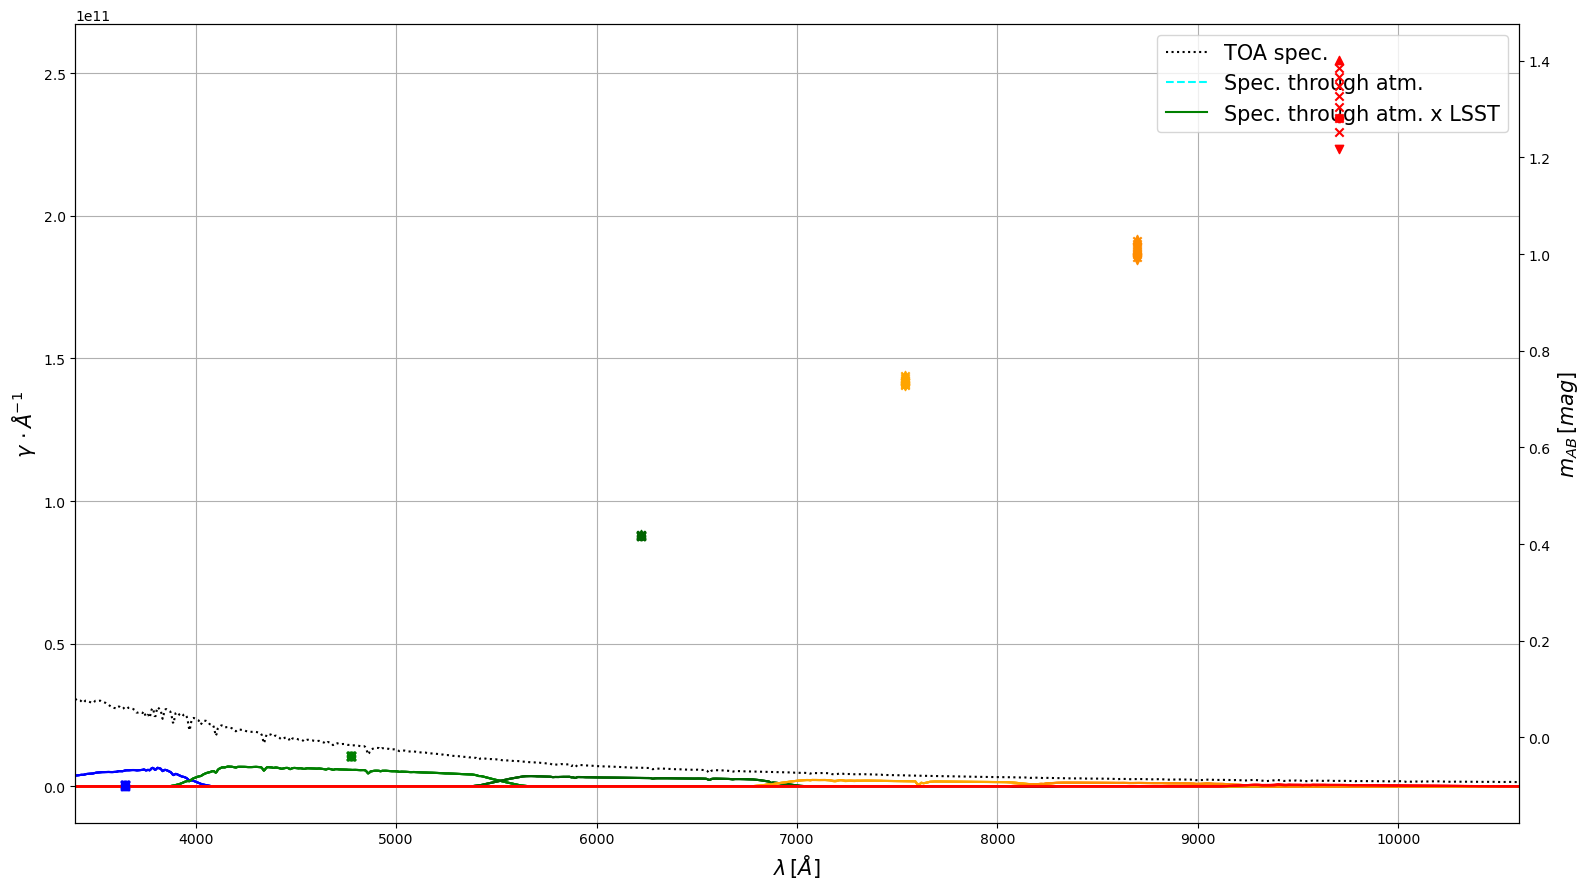

In [119]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls=':',color='k',alpha=1.0)

ax2 = ax1.twinx()

for index,filter in enumerate(filters):
    print(filter)
    obs = obs_flux_std_dict[example_id][filter]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[example_id][filter][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=alpha)
        

ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,2e10)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls='--',color='cyan',label='Spec. through atm.')
ax1.plot([],[],ls='-',color='g',label='Spec. through atm. x LSST')

for index,filter in enumerate(filters):
    ax2.scatter(eff_lambda[filter],mag_std_dict[example_id][filter],marker='o',color=filter_colors[index])
    for i in range(n_sim):
        if i==min_ind_:
            marker = 'v'
        elif i==max_ind_:
            marker = '^'
        else:
            marker = 'x'
        ax2.scatter(eff_lambda[filter],mag_t_dict[example_id][filter][i],marker=marker,color=filter_colors[index])

ax2.set_ylabel(r'$m_{AB} \, [mag]$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
print(spec.fluxunits)

<>:24: SyntaxWarning: invalid escape sequence '\,'
<>:25: SyntaxWarning: invalid escape sequence '\g'
<>:24: SyntaxWarning: invalid escape sequence '\,'
<>:25: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3780345378.py:24: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3780345378.py:25: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
photlam


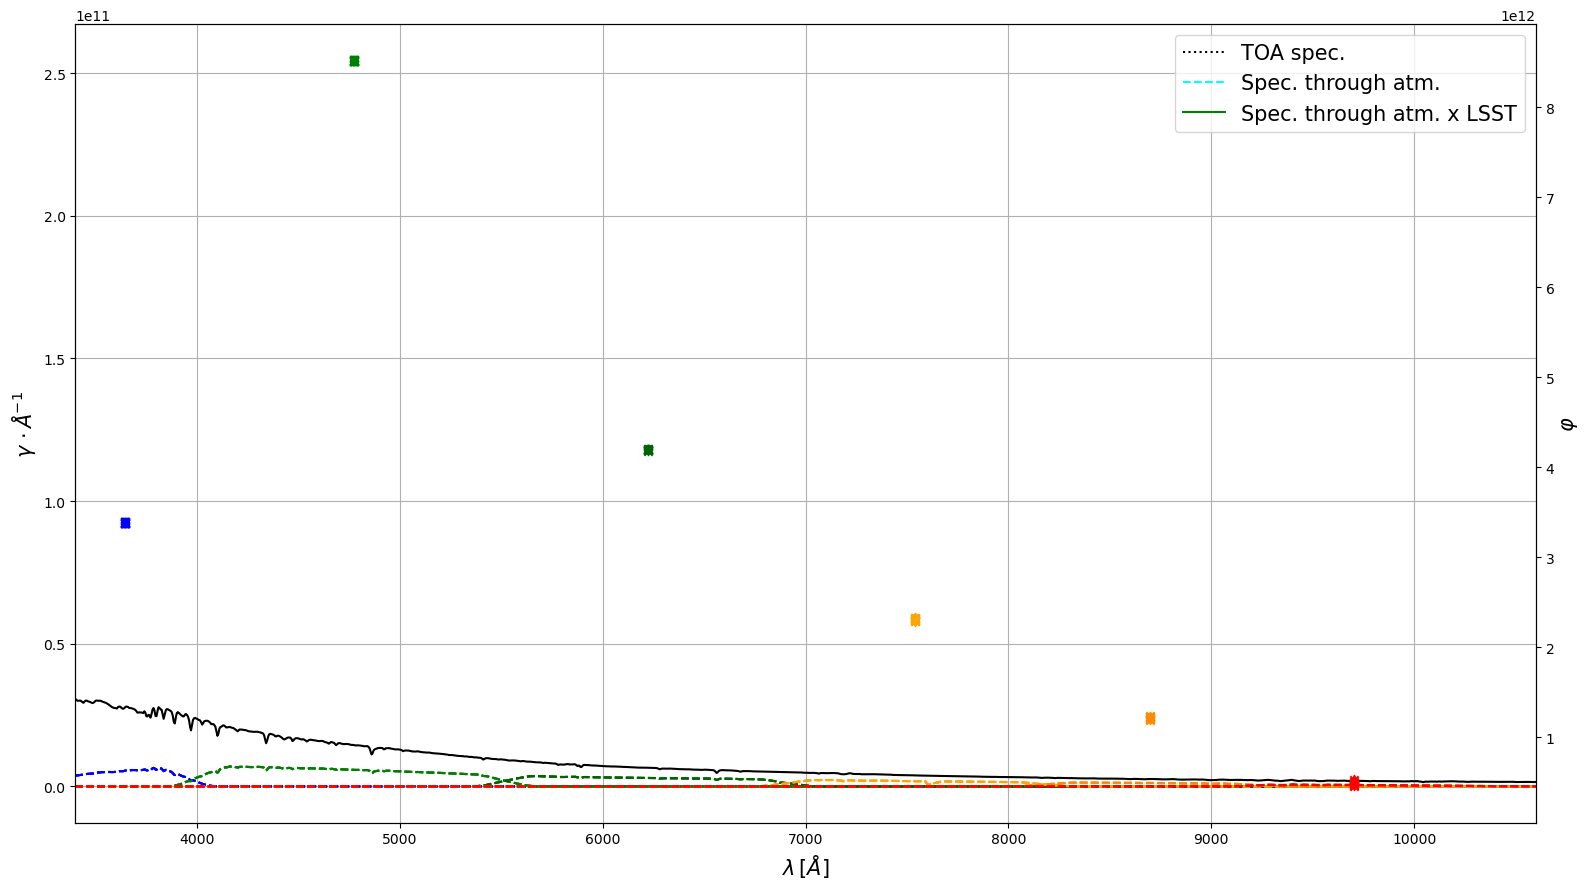

In [120]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls='-',color='k',alpha=1.0)

ax2 = ax1.twinx()

for index,filter in enumerate(filters):
    print(filter)
    obs = obs_flux_std_dict[example_id][filter]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[example_id][filter][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=filter_colors[index],alpha=alpha)
        

ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,1.75e10)
#ax2.set_ylim(0,7.5e12)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls='--',color='cyan',label='Spec. through atm.')
ax1.plot([],[],ls='-',color='g',label='Spec. through atm. x LSST')

for index,filter in enumerate(filters):
    ax2.scatter(eff_lambda[filter],phi_std_dict[example_id][filter],marker='o',color=filter_colors[index])
    for i in range(n_sim):
        if i==min_ind_:
            marker = '^'
        elif i==max_ind_:
            marker = 'v'
        else:
            marker = 'x'
        ax2.scatter(eff_lambda[filter],phi_t_dict[example_id][filter][i],marker=marker,color=filter_colors[index])

ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
print(spec.fluxunits)

### We store the observed integrated flux, $\vec{\varphi}_i(t)$ 

We store it for 2 cases: 
- Variable / current total passband 
- Standard total passband 

In [121]:
wl_eff = []
for filter in filters:
    print(filter)
    wl_eff.append(eff_lambda[filter])
wl_eff = np.array(wl_eff)

u
g
r
i
z
Y


# Polynomial fit of the integrated fluxes 

We have 6 bands, *ugrizY*, so we have 6 integrated fluxes, $\varphi_b$. Then, we consider the observed vector $\vec{\varphi}$. We can think of these integrated fluxes as the signal of very low resolution spectra, i.e. with very wide wavelength bins. Considering this, we associate each $\varphi_b$ with the effective wavelength, $\lambda_b^{eff}$, defined as before. 

Now, let us suppose that for a given source at a given moment we have integrated flux measurements in $N_{obs}$ bands, with $N_{obs} \leq 6$. Then, let us consider that TOA SED of the source can be described by a function $\hat{F}(\lambda)$. We consider this function to be a polynomial of order $n = N_{obs}-1$, i.e., 

$$\hat{F}(\lambda) = \sum_{i=0}^n a_i \lambda^i \, . $$ 

For a given band, $b$, the function $\hat{F}(\lambda)$ should meet 

$$\int \hat{F}(\lambda) \cdot T_b(\lambda) \cdot S_{eff} \cdot t_{exp} \frac{d\lambda}{h \lambda} = \varphi_b \, , $$ 

where $\hat{F}(\lambda)$ is *fnu* units, i.e., $erg \, s^{-1} cm^{-2} Hz^{-1}$ (note the counter-intuitive notation). For convenience, we are going to work with $\hat{F}(\lambda)$ is *photlam* units, i.e., $1 \, s^{-1} cm^{-2} \AA^{-1}$, so **note that the term $1/h\lambda$ is going to be absorved within $\hat{F}(\lambda)$.** If we expand $\hat{F}(\lambda)$ in its polynomial form, we can rewrite this expression as 

$$ \sum_{i=0}^n a_i \phi_b^i = \varphi_b \, , $$ 

where 

$$ \phi_b^i(t) = \int \lambda^{i} \cdot T_b(\lambda,t) \cdot S_{eff} \cdot t_{exp} \, d\lambda \, . $$ 

For $N \geq 2$ we will have a system of linear equations on the coefficients $a_i$: 

$$\begin{cases} 
\sum_{i=0}^n a_i \phi_{b_1}^i = \varphi_{b_1} \, \\ \qquad \vdots \\ \sum_{i=0}^n a_i \phi_{b_N}^i = \varphi_{b_N} \, . 
\end{cases}$$ 

If we express this in matrix notation, we have 

$$\begin{bmatrix} \phi_{b_1}^0 & \cdots & \phi_{b_1}^n \\ \vdots & \ddots & \vdots \\ \phi_{b_N}^0 & \cdots & \phi_{b_N}^n \end{bmatrix} \, \begin{bmatrix} a_0 \\ \vdots \\ a_n \end{bmatrix} = \begin{bmatrix} \varphi_{b_1} \\ \vdots \\ \varphi_{b_N} \end{bmatrix} \, , $$ 

or in vector notation, 

$$ M_{\phi} \vec{a} = \vec{\varphi} \, , $$ 

We note that for this matrix product $N \times (n+1) \cdot (n+1) \times 1 = N $, where $N = N_{obs}$. Then, we can find the coefficients by solving 

$$ \vec{a} = M_{\phi}^{-1} \vec{\varphi} \, . $$ 

Note that the matrix $M_{\phi}$ depends only on the atmospheric conditions, parameterized by $t$, so it only needs to be calculated for a given set of conditions, not for each source. Therefore, $M_{\phi} = M_{\phi}(t)$. 


## Contour conditions: 

### Approach only valid for blue objects (we are not going to use it for now, but we leave it here just to have it localized): 
To ensure that the fitted spectrum follows the same trend as the original spectrum at least within a reasonable range of wavelengths, we are going to do the following: we need to impose that $\hat{F}(\lambda)$ tends to 0 at least when for the wavelengths close to the bluest and reddest filters. To do this, let us consider two delta filters centered at two given wavelength, $\lambda_b$ and $\lambda_r$, which are smaller than the smallest wavelength of the bluer filter and bigger than the biggest wavelength of the redder one, respetively. We can write this as 

$$T_{\delta_b}(\lambda) = \delta(\lambda - \lambda_b) \, ,$$ 

and 

$$T_{\delta_r}(\lambda) = \delta(\lambda - \lambda_r) \, .$$ 

Following the same logic as before, the function $\hat{F}(\lambda)$ will have to meet the condition 

$$\sum_{i=0}^n a_i \phi^i_{\delta} = 0 \, $$

where $\phi^i_{\delta}$ are given by 

$$\phi_{\delta}^i = \int \lambda^{i} \cdot \delta(\lambda-\lambda_{\delta}) \cdot S_{eff} \cdot t_{exp} \, d\lambda \, = \lambda_{\delta}^{i} \cdot S_{eff} \cdot t_{exp} \, , $$ 

where the subscript $\delta$ corresponds to both $b$ and $r$, respectively. 

If we account for the two artificial delta passbands, we will have for a given object at a given moment $N_{obs} + 2$ integrated fluxes and therefore the order of the polynomial $\hat{F}(\lambda)$ will be $n = N_{obs}+1$. We can then add these two conditions to the previous matrix, so we have 

$$\begin{bmatrix} \phi_{\delta_b}^0 & \cdots & \phi_{\delta_b}^n \\ \phi_{b_1}^0 & \cdots & \phi_{b_1}^n \\ \vdots & \ddots & \vdots \\ \phi_{b_N}^0 & \cdots & \phi_{b_N}^n \\ \phi_{\delta_r}^0 & \cdots & \phi_{\delta_r}^n \end{bmatrix} \, \begin{bmatrix} a_0 \\ \vdots \\ a_n \end{bmatrix} = \begin{bmatrix} \varphi_{\delta_b} \\ \varphi_{b_1} \\ \vdots \\ \varphi_{b_N} \\ \varphi_{\delta_r} \end{bmatrix} \, . $$ 

Then, we use this matrix the same way as described above. 

### Using Euclid's filters 

Suppose we take the integrated fluxes for the $z$ and $Y$ bands only and we follow the same procedure to find $\hat{F}(\lambda)$. To distinguish 1st order spectrum from the polynomial one, we will refer to it as $\tilde{F}^r(\lambda)$ and it will have the form 

$$\tilde{F}^r(\lambda) = \tilde{a}^r_0 + \tilde{a}^r_1 \lambda \, . $$

Then, using this fitted spectrum we can estimate the integrated fluxes for the Euclid's filters, $\tilde{\Phi}_E$: 

$$\tilde{\Phi}_E = \int \tilde{F}^r(\lambda) \cdot T_E(\lambda) \cdot S_{eff} \cdot t_{exp} \, d\lambda \, . $$

This should add to some degree information about the shape / trend of the spectrum we are working with at the redder wavelengths. 

Once we have these estimated values, we incorporate them as additional filters to the matrix $M_{\phi}$. To do this, we are going to consider only one out of the three Euclid's filters: $J_E$.  

### Using SWIFT's filters 

We can do the same thing as with the Euclid's filters but for the bluer wavelengths by using the filters from SWIFT. In this case, we take the integrated fluxes for the $u$ and $g$ bands only and we define a linear function for the blue end as 

$$\tilde{F}^b(\lambda) = \tilde{a}^b_0 + \tilde{a}^b_1 \lambda \, . $$

From this function, we estimate the integrated fluxes from the SWIFT's filters, $\tilde{\Phi}_S$. In particular, we focus on the filter $UVM2$. 

### Total system of equations 

By following the two previous steps, we are increasing the order of the polynomial $\hat{F}(\lambda)$ that we use to estimate the TOA SED. Doing this, we have $n = N_{obs} - 1 + 2 = N_{obs} + 1$ and the matrix equation will be the following: 

$$\begin{bmatrix} \tilde{\phi}_{UWM2}^0 & \cdots & \tilde{\phi}_{UVM2}^n & \tilde{\phi}_{UVM2}^{n+1} \\ \phi_{b_1}^0 & \cdots & \phi_{b_1}^n & \phi_{b_1}^{n+1} \\ \vdots & \ddots & \vdots & \vdots \\ \phi_{b_N}^0 & \cdots & \phi_{b_N}^n & \phi_{b_N}^{n+1} \\ \tilde{\phi}_{J_E}^0 & \cdots & \tilde{\phi}_{J_E}^n & \tilde{\phi}_{J_E}^{n+1} \end{bmatrix} \, \begin{bmatrix} a_0 \\ \vdots \\ a_n \\ a_{n+1}\end{bmatrix} = \begin{bmatrix} \tilde{\Phi}_{UVM2} \\ \varphi_{b_1} \\ \vdots \\ \varphi_{b_N} \\ \tilde{\Phi}_{J_E} \end{bmatrix} \, . $$ 

Note that the matrix elements $\tilde{\phi}_E$, i.e. those corresponding to the Euclid's filters, should not depend on $t$, since we consider the Euclid's total passbands to correspond only to TOA observations. 


### We define the polynomial expression for $\hat{F}(\lambda)$ 

In [122]:
def poly_f(l,a,output_funits='photlam',all_positive=False):
    val_ = 0.
    for i in range(len(a)):
        val_ = val_+a[i]*l**i
    
    if output_funits=='fnu':
        A = h_planck*l
    elif output_funits=='flam':
        A = l**2./c_light
    elif output_funits=='photlam':
        A = 1.
    else:
        A = 1.
    val_ = A*val_
    if all_positive:
        val_[val_<0.] = 0.
    
    return val_

### We define $M_{\phi}$ by calculating the matrix elements, $\phi^i_b$ 

In [123]:
def phi_ij(wavelength,passband,i):
    
    T_b = passband.throughput
    assert len(wavelength)==len(T_b)
    
    phi_ij = np.trapz((wavelength**i)*T_b,x=wavelength)*Seff*exptime
    
    return phi_ij

In [124]:
def phi_ij_delta(wavelength,i):
    
    phi_ij = (wavelength**i)*Seff*exptime
    
    return phi_ij

### Compute TRUE fluxes passing through Euclid and SWIFT filters 

In [125]:
obs_flux_eu_dict = {}
obs_flux_swift_dict = {}
obs_flux_gauss_dict = {}

for ised in sed_dict.keys():
    #print(ised)
    sed_ = sed_dict[ised]
    
    obstotal_dict_ = {}
    for i,filter_ in enumerate(eu_filters):
        obstotal_ = S.Observation(sed_,euclid_bp[i],force='taper')
        obstotal_dict_[filter_] = obstotal_
        if ised=='pickles_uk_131':
            print(filter_,np.trapz(obstotal_.flux,x=obstotal_.wave))
        
    obs_flux_eu_dict[ised] = obstotal_dict_
    
    obstotal_dict_ = {}
    for i,filter_ in enumerate(swift_filters):
        obstotal_ = S.Observation(sed_,swift_bp[i],force='taper')
        obstotal_dict_[filter_] = obstotal_
        if ised=='pickles_uk_131':
            print(filter_,np.trapz(obstotal_.flux,x=obstotal_.wave))
        
    obs_flux_swift_dict[ised] = obstotal_dict_
    
    obstotal_dict_ = {}
    for i,filter_ in enumerate(gauss_filters):
        obstotal_ = S.Observation(sed_,gauss_bp[i],force='taper')
        obstotal_dict_[filter_] = obstotal_
        if ised=='pickles_uk_131':
            print('Gauss {0}'.format(i),np.trapz(obstotal_.flux,x=obstotal_.wave))
        
    obs_flux_gauss_dict[ised] = obstotal_dict_
    

u
g
r
i
z
Y
Ye


<>:35: SyntaxWarning: invalid escape sequence '\,'
<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\,'
<>:36: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3866994863.py:35: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3866994863.py:36: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


Je
He
UVW2
UVM2
UVW1
photlam


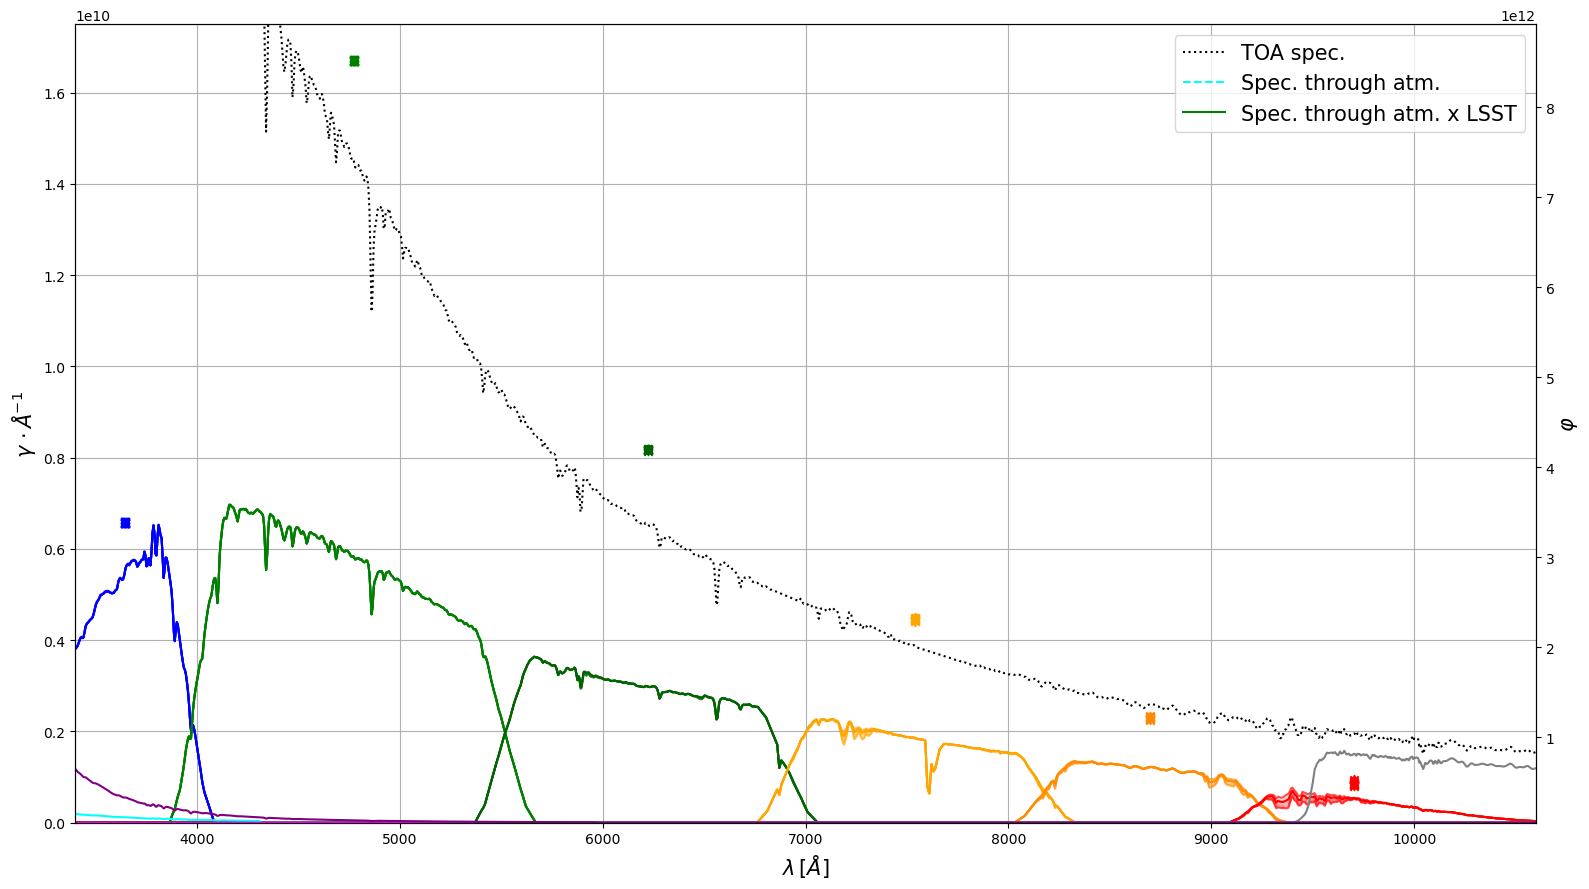

In [126]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls=':',color='k',alpha=1.0)

ax2 = ax1.twinx()

for index,filter_ in enumerate(filters):
    print(filter_)
    obs = obs_flux_std_dict[example_id][filter_]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[example_id][filter_][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=alpha)
        
for index,filter_ in enumerate(eu_filters):
    print(filter_)
    obs = obs_flux_eu_dict[example_id][filter_]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=eu_colors[filter_],alpha=1.0)
    
for index,filter_ in enumerate(swift_filters):
    print(filter_)
    obs = obs_flux_swift_dict[example_id][filter_]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=swift_colors[filter_],alpha=1.0)

ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_xlim(2000.,7000.)
ax1.set_ylim(0.,1.75e10)
#ax1.set_yscale("log")
#ax2.set_ylim(0,7.5e12)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls='--',color='cyan',label='Spec. through atm.')
ax1.plot([],[],ls='-',color='g',label='Spec. through atm. x LSST')

for index,filter in enumerate(filters):
    ax2.scatter(eff_lambda[filter],phi_std_dict[example_id][filter],marker='o',color=filter_colors[index])
    for i in range(n_sim):
        if i==min_ind_:
            marker = '^'
        elif i==max_ind_:
            marker = 'v'
        else:
            marker = 'x'
        ax2.scatter(eff_lambda[filter],phi_t_dict[example_id][filter][i],marker=marker,color=filter_colors[index])

ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
print(spec.fluxunits)

<>:35: SyntaxWarning: invalid escape sequence '\,'
<>:36: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\,'
<>:36: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3575929984.py:35: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3575929984.py:36: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
Ye
Je
He
UVW2
UVM2
UVW1
photlam


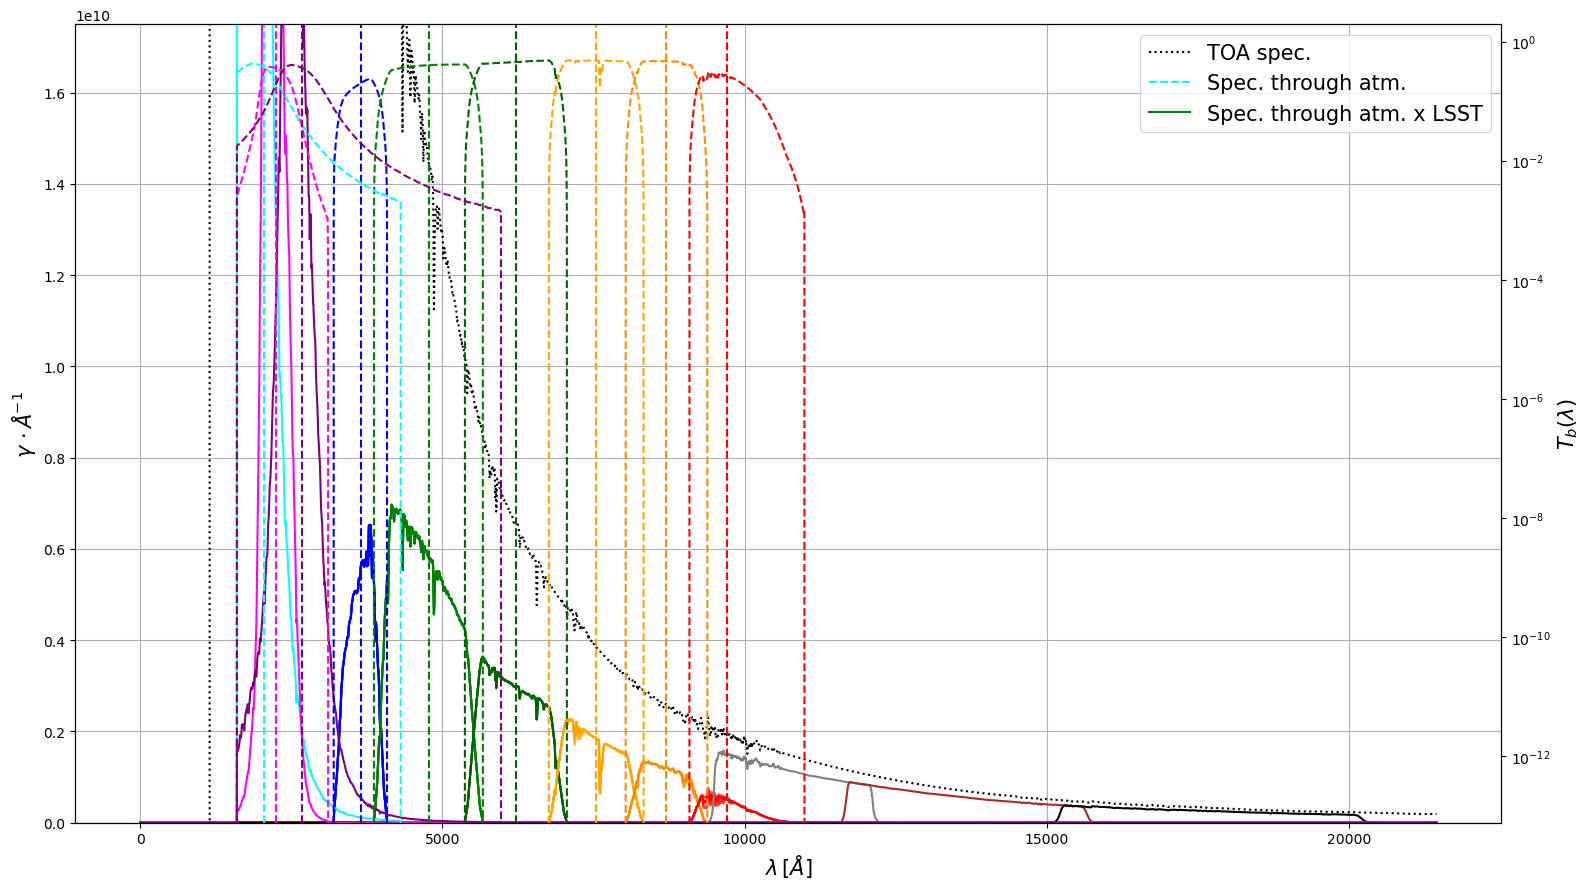

In [127]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls=':',color='k',alpha=1.0)

ax2 = ax1.twinx()

for index,filter_ in enumerate(filters):
    print(filter_)
    obs = obs_flux_std_dict[example_id][filter_]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    for i in range(n_sim):
        obs = obs_flux_t_dict[example_id][filter_][i]
        if i==min_ind_ or i==max_ind_:
            alpha = 0.7
        else:
            alpha = 0.2
        ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=alpha)
        
for index,filter_ in enumerate(eu_filters):
    print(filter_)
    obs = obs_flux_eu_dict[example_id][filter_]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=eu_colors[filter_],alpha=1.0)
    
for index,filter_ in enumerate(swift_filters):
    print(filter_)
    obs = obs_flux_swift_dict[example_id][filter_]
    ax1.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=swift_colors[filter_],alpha=1.0)

#ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_xlim(2000.,7000.)
ax1.set_ylim(0.,1.75e10)
#ax1.set_yscale("log")
#ax2.set_ylim(0,7.5e12)
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()
ax1.plot([],[],ls=':',color='k',label='TOA spec.')
ax1.plot([],[],ls='--',color='cyan',label='Spec. through atm.')
ax1.plot([],[],ls='-',color='g',label='Spec. through atm. x LSST')

for index,filter_ in enumerate(filters):
    ax2.plot(total_passband_ref[filter_].wave,total_passband_ref[filter_].throughput,ls='--',color=filter_colors[index])
    ax2.axvline(x=eff_lambda[filter_],ls='--',color=filter_colors[index])

for index,filter_ in enumerate(swift_filters):
    ax2.plot(swift_bp[index].wave,swift_bp[index].throughput,ls='--',color=swift_colors[filter_])
    ax2.axvline(x=swift_eff_lambda[filter_],ls='--',color=swift_colors[filter_])

ax2.set_yscale("log")
ax2.set_ylabel(r'$T_b(\lambda)$',fontsize=15)
ax1.legend(fontsize=15)
plt.tight_layout()
print(spec.fluxunits)

### Compute TRUE integrated fluxes and magnitudes through Euclid's filters 

In [128]:
phi_eu_dict = {}
mag_eu_dict = {}

for ised in sed_dict.keys():
    sed_ = sed_dict[ised]
    
    phi_dict_std_ = {}
    mag_dict_std_ = {}
    for index,filter_ in enumerate(eu_filters):
        num_,mag_ = int_flux(sed_,euclid_bp[index],
                        return_mag=True,PhiAB=Phi_AB_eu[index])
        phi_dict_std_[filter_] = num_
        mag_dict_std_[filter_] = mag_
    phi_eu_dict[ised] = phi_dict_std_
    mag_eu_dict[ised] = mag_dict_std_
    
    #print('###########################################################')
    

### Compute TRUE integrated fluxes and magnitudes through SWIFT's filters 

In [129]:
phi_swift_dict = {}
mag_swift_dict = {}

for ised in sed_dict.keys():
    sed_ = sed_dict[ised]
    
    phi_dict_std_ = {}
    mag_dict_std_ = {}
    for index,filter_ in enumerate(swift_filters):
        num_,mag_ = int_flux(sed_,swift_bp[index],
                        return_mag=True,PhiAB=Phi_AB_swift[index])
        phi_dict_std_[filter_] = num_
        mag_dict_std_[filter_] = mag_
    phi_swift_dict[ised] = phi_dict_std_
    mag_swift_dict[ised] = mag_dict_std_
    
    #print('###########################################################')
    

### Compute TRUE integrated fluxes and magnitudes through Gaussian filters 

In [130]:
phi_gauss_dict = {}
mag_gauss_dict = {}

for ised in sed_dict.keys():
    sed_ = sed_dict[ised]
    
    phi_dict_std_ = {}
    mag_dict_std_ = {}
    for index,filter_ in enumerate(gauss_filters):
        num_,mag_ = int_flux(sed_,gauss_bp[index],
                        return_mag=True,PhiAB=Phi_AB_gauss[index])
        phi_dict_std_[filter_] = num_
        mag_dict_std_[filter_] = mag_
    phi_gauss_dict[ised] = phi_dict_std_
    mag_gauss_dict[ised] = mag_dict_std_
    
    #print('###########################################################')
    

In [131]:
#phi_gauss_dict

## Compute 0 order spectra 

In [132]:
K = Seff*exptime

In [133]:
cte_M_phi = {}
for ised in sed_dict.keys():
    
    cte_M_phi[ised] = {}
    for filter_ in filters:
        cte_M_phi[ised][filter_] = {}
        phi_ij_ = phi_ij(wl_baseline,total_passband_ref[filter_],0)
        cte_M_phi[ised][filter_]['std'] = phi_ij_
        
        for isim in range(n_sim):
            phi_ij_ = phi_ij(wl_baseline,total_passband[filter_][isim],0)
            cte_M_phi[ised][filter_][isim] = phi_ij_
    

In [134]:
#cte_M_phi

In [135]:
cte_M_phi_inv = {}
for ised in sed_dict.keys():
    
    cte_M_phi_inv[ised] = {}
    for filter_ in filters:
        cte_M_phi_inv[ised][filter_] = {}
        cte_M_phi_inv[ised][filter_]['std'] = 1./cte_M_phi[ised][filter_]['std']
        
        for isim in range(n_sim):
            cte_M_phi_inv[ised][filter_][isim] = 1./cte_M_phi[ised][filter_][isim]
    

In [136]:
#cte_M_phi_inv

In [137]:
cte_A = {}
for ised in sed_dict.keys():
    
    cte_A[ised] = {}
    for filter_ in filters:
        cte_A[ised][filter_] = {}
        cte_A[ised][filter_]['std'] = cte_M_phi_inv[ised][filter_]['std']*phi_std_dict[ised][filter_]
        
        for isim in range(n_sim):
            cte_A[ised][filter_][isim] = cte_M_phi_inv[ised][filter_][isim]*phi_t_dict[ised][filter_][isim]
    

In [138]:
#cte_A

(0.0, 1.0)

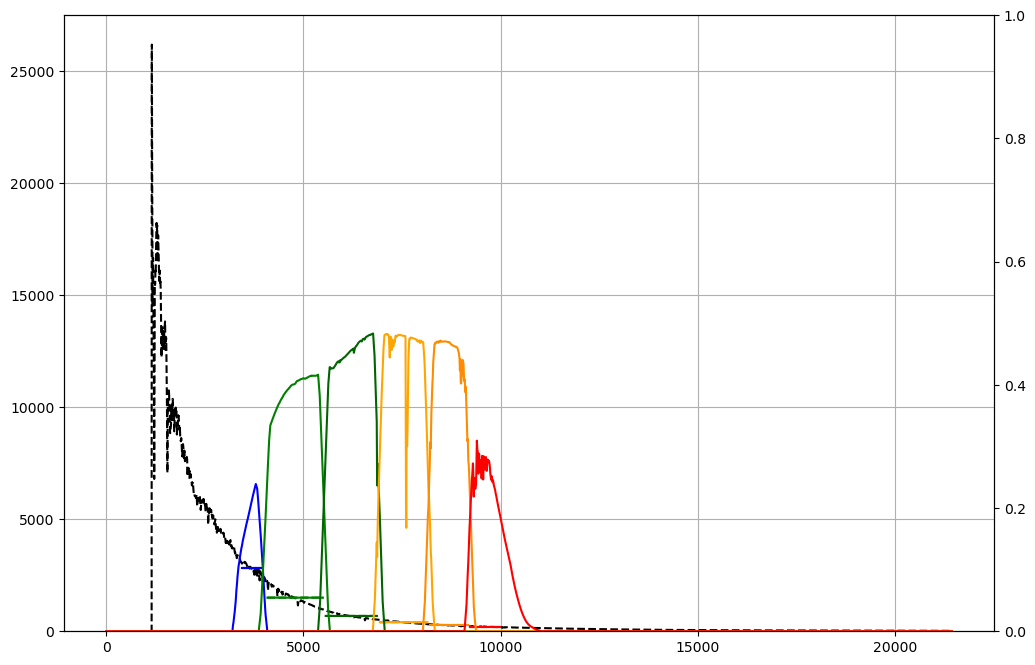

In [139]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
    
ax.plot(example_spec.wave,example_spec.flux,ls='--',color='k')
for i,filter_ in enumerate(filters):
    x_range_ = wl_baseline[total_passband_ref[filter_].throughput>=0.6*np.max(total_passband_ref[filter_].throughput)]
    ax.plot(x_range_,cte_A[example_id][filter_]['std']*np.ones(len(x_range_)),color=filter_colors[i])
    for isim in range(n_sim):
        ax.plot(x_range_,cte_A[example_id][filter_][isim]*np.ones(len(x_range_)),ls='--',color=filter_colors[i],alpha=0.2)

ax.set_ylim(0.,)
ax.grid()

ax2 = ax.twinx()
for i,filter_ in enumerate(filters):
    ax2.plot(total_passband_ref[filter_].wave,total_passband_ref[filter_].throughput,color=filter_colors[i])
ax2.set_ylim(0.,1.)

<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/324321763.py:17: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/324321763.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


Text(0, 0.5, '$\\gamma \\, \\cdot $$\\AA$$^{-1}$')

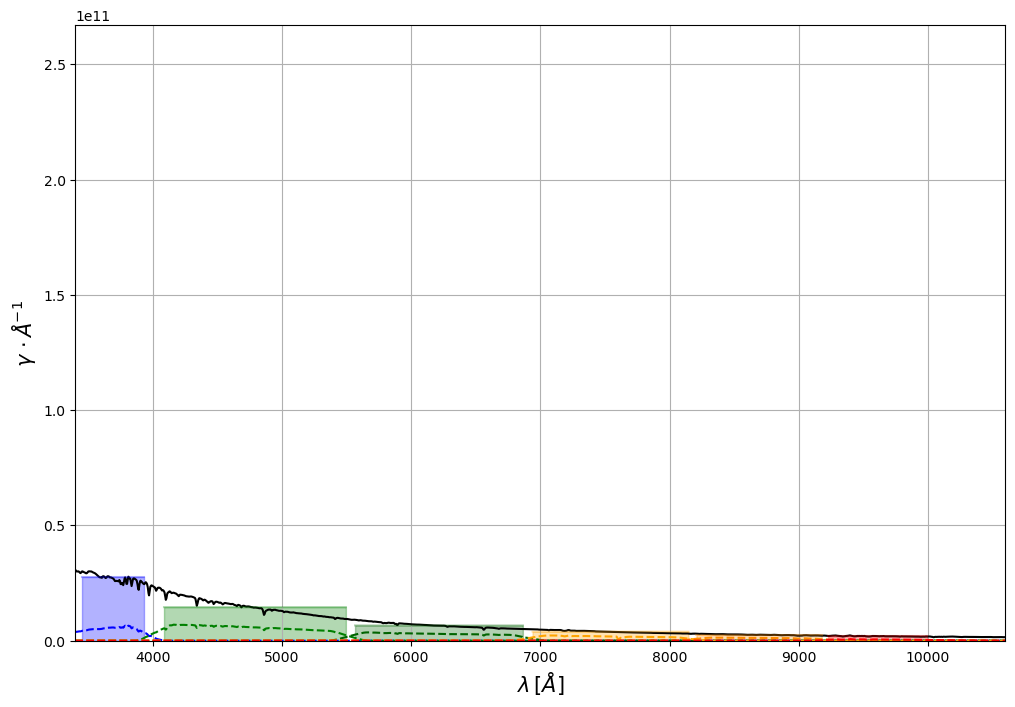

In [140]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
    
ax.plot(example_spec.wave,example_spec.flux*Seff*exptime,ls='-',color='k')
for index,filter_ in enumerate(filters):
    obs = obs_flux_std_dict[example_id][filter_]
    ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=filter_colors[index],alpha=1.0)
    
    x_range_ = wl_baseline[total_passband_ref[filter_].throughput>=0.6*np.max(total_passband_ref[filter_].throughput)]
    ax.plot(x_range_,cte_A[example_id][filter_]['std']*np.ones(len(x_range_))*Seff*exptime,color=filter_colors[index],alpha=0.3)
    ax.fill_between(x_range_,0.,cte_A[example_id][filter_]['std']*np.ones(len(x_range_))*Seff*exptime,color=filter_colors[index],alpha=0.3)
    
    
ax.set_xlim(WLMIN,WLMAX)
ax.set_ylim(0.,)
ax.grid()
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)



In [141]:
lin_filters = ['u','g']

lin_m = {example_id:{}}
lin_m[example_id]['std'] = (cte_A[example_id][lin_filters[1]]['std']-cte_A[example_id][lin_filters[0]]['std'])/(eff_lambda[lin_filters[1]]-eff_lambda[lin_filters[0]])
for isim in range(n_sim):
    lin_m[example_id][isim] = (cte_A[example_id][lin_filters[1]][isim]-cte_A[example_id][lin_filters[0]][isim])/(eff_lambda[lin_filters[1]]-eff_lambda[lin_filters[0]])

In [142]:
lin_m

{'pickles_uk_2': {'std': -1.173617550449745,
  0: -1.1736312642955062,
  1: -1.1736244775518994,
  2: -1.173617550449745,
  3: -1.1736104210736402,
  4: -1.1736029863953763,
  5: -1.1735845544421784,
  6: -1.1735349698461701,
  7: -1.1734035307329298,
  8: -1.1733900311106198}}

In [143]:
def g(l,lref,m,c):
    return m*(l-lref)+c

<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/1901725590.py:21: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/1901725590.py:22: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


Text(0, 0.5, '$\\gamma \\, \\cdot $$\\AA$$^{-1}$')

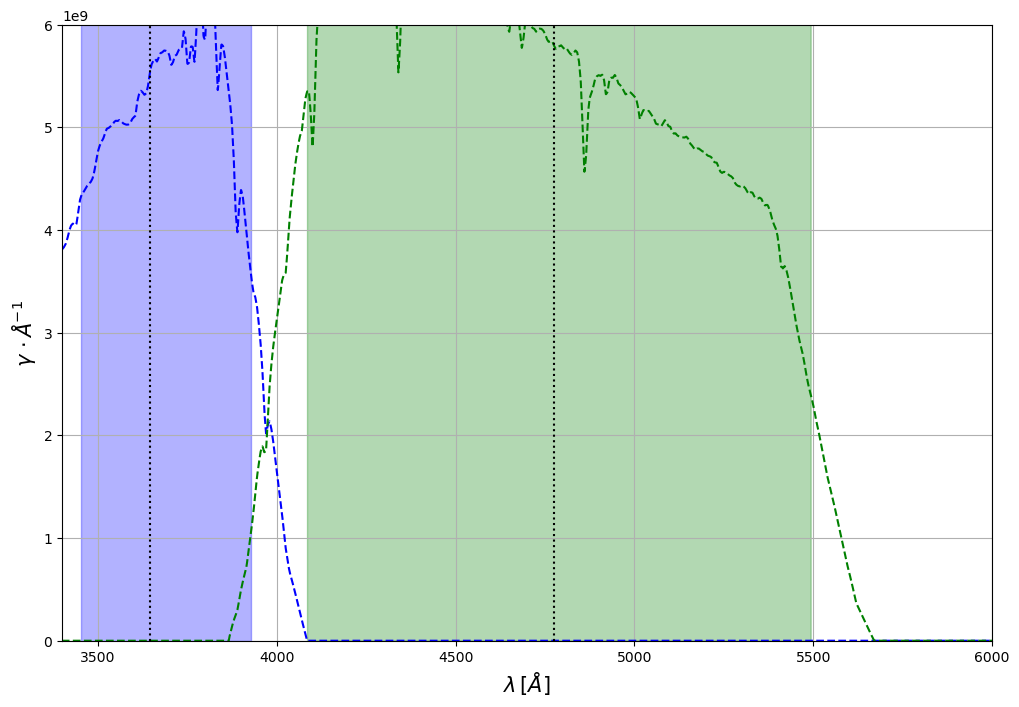

In [144]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

ax.plot(example_spec.wave,example_spec.flux*Seff*exptime,ls='-',color='k')
for index,filter_ in enumerate(lin_filters):
    obs = obs_flux_std_dict[example_id][filter_]
    ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=filter_colors[index],alpha=1.0)
    
    x_range_ = wl_baseline[total_passband_ref[filter_].throughput>=0.6*np.max(total_passband_ref[filter_].throughput)]
    ax.plot(x_range_,cte_A[example_id][filter_]['std']*np.ones(len(x_range_))*Seff*exptime,color=filter_colors[index],alpha=0.3)
    ax.fill_between(x_range_,0.,cte_A[example_id][filter_]['std']*np.ones(len(x_range_))*Seff*exptime,color=filter_colors[index],alpha=0.3)

wltest = wl_baseline[(wl_baseline>=eff_lambda[lin_filters[0]])*(wl_baseline<eff_lambda[lin_filters[1]])]
gtest_ = g(wltest,eff_lambda[lin_filters[0]],lin_m[example_id]['std'],cte_A[example_id][lin_filters[0]]['std'])
ax.plot(wltest,gtest_*Seff*exptime,color='purple')
ax.axvline(x=eff_lambda[lin_filters[0]],ls=':',color='k')
ax.axvline(x=eff_lambda[lin_filters[1]],ls=':',color='k')
ax.set_xlim(WLMIN,6000.)
ax.set_ylim(0.,0.6e10)
ax.grid()
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)

In [145]:
def h0(l,l0,l1,f0):
    return (l-l0)*f0/(l1-l0)

In [146]:
def Phi_minus(l0,l1,pb_1,f0):
    
    wl_mask = (wl_baseline>=l0)*(wl_baseline<l1)
    wls_ = wl_baseline[wl_mask]
    T_x = pb_1.throughput[wl_mask]
    assert len(wls_)==len(T_x)
    
    Phi_1_minus = np.trapz(h0(wls_,l0,l1,f0)*T_x*K,x=wls_)
    return Phi_1_minus

In [147]:
Phi_minus(0.,eff_lambda['u'],total_passband_ref['u'],cte_A[example_id]['u']['std'])

1399157656473.1409

### Set $\varphi^-_u$ as $0.5 \varphi_u$ 

In [148]:
phi_frac = 0.4
phi_u_minus = phi_std_dict[example_id]['u']*phi_frac
phi_u_minus_err = phi_err_std_dict[example_id]['u']*phi_frac**2.
phi_u_minus,phi_u_minus_err

(1352579960787.6514, 122466.43288955002)

In [149]:
def chi2_calc_l0(val,err,l1,pb_1,f0,steps=1000):
    
    l0 = []
    chi2_vals = []
    for l0_ in np.linspace(0.,l1,steps):
        model_ = Phi_minus(l0_,l1,pb_1,f0)
        chi2_ = 0.5*((val-model_)**2.)/err**2.
        chi2_vals.append(chi2_)
        l0.append(l0_)
    return np.array(l0),np.array(chi2_vals)

In [150]:
l0test,chi2test = chi2_calc_l0(phi_u_minus,phi_u_minus_err,eff_lambda['u'],total_passband_ref['u'],cte_A[example_id]['u']['std'])

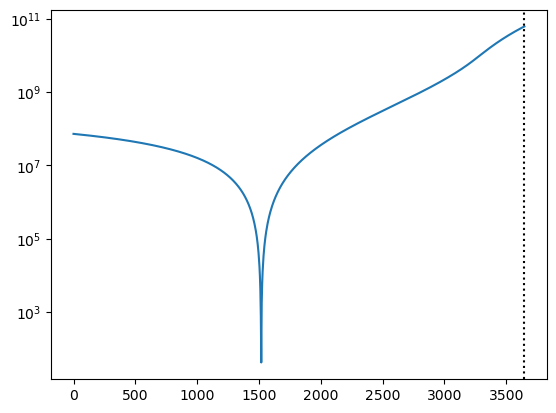

In [151]:
plt.plot(l0test,chi2test/len(l0test))
plt.axvline(x=eff_lambda['u'],ls=':',color='k')
plt.yscale("log")

0.2 [3358.28795349]
0.30000000000000004 [3117.36729595]
0.4 [1518.53020505]
0.5 [0.]
0.6000000000000001 [0.]
0.7000000000000002 [0.]
0.8 [0.]


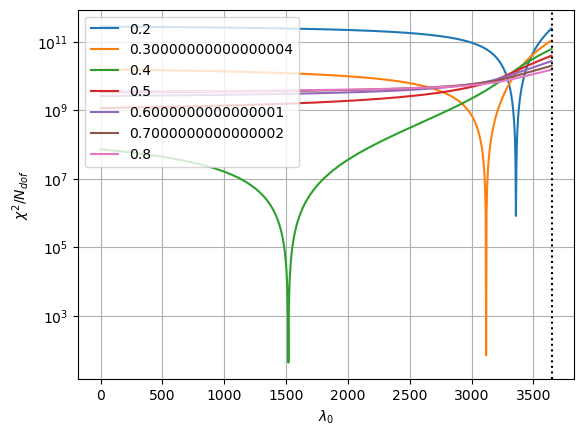

In [152]:
for phi_frac_ in np.linspace(0.2,0.8,7):
    phi_u_minus_ = phi_std_dict[example_id]['u']*phi_frac_
    phi_u_minus_err_ = phi_err_std_dict[example_id]['u']*phi_frac_**2.

    l0test,chi2test = chi2_calc_l0(phi_u_minus_,phi_u_minus_err_,eff_lambda['u'],total_passband_ref['u'],cte_A[example_id]['u']['std'])
    plt.plot(l0test,chi2test/len(l0test),label=phi_frac_)
    print(phi_frac_,l0test[chi2test==np.min(chi2test)])
plt.axvline(x=eff_lambda['u'],ls=':',color='k')
plt.yscale("log")
plt.grid()
plt.xlabel(r'$\lambda_0$')
plt.ylabel(r'$\chi^2 / N_{dof}$')
plt.legend(loc="upper left")

## Do estimates for the integrated fluxes on the red and blue ends of the spectra 

### Fit power law spectrum for the red end 
### Fit exponential spectrum for the blue end 

In [153]:
filters_r = ['z','Y']
filters_b = ['u','g']

In [154]:
lambdas_b = []
lambdas_r = []

for i,filter_ in enumerate(filters):
    if filter_ in filters_b:
        lambdas_b.append(eff_lambda[filter_])
            
    elif filter_ in filters_r:
        lambdas_r.append(eff_lambda[filter_])
        
lambdas_b = np.array(lambdas_b)
lambdas_r = np.array(lambdas_r)

In [155]:
def power_fun_r(l,A,k):
    return A*(l**k)

In [156]:
eu_eff_lambda

{'Ye': 10812.418203760846, 'Je': 13669.513885076847, 'He': 17707.85747696563}

In [157]:
#def gauss_fun_r(l,A,mu,sigma):
#    return A*np.exp(-((l-mu)**2.)/(2.*sigma**2.))

eu_for_sigma = 'Je'

def gauss_fun(l,A,mu):
    return A*np.exp(-((l-mu)**2.)/(2.*(lambdas_r[1]-eu_eff_lambda[eu_for_sigma])**2.))
    

In [158]:
def exp_fun_up(l,A,k):
    return A*(np.exp(k*l)-1.)

In [159]:
def exp_fun_down(l,A,k):
    return A*np.exp(k*l)

In [160]:
F0_b = {}
F0_r = {}

for ised in sed_dict.keys():
    F0_b[ised] = {}
    F0_r[ised] = {}
    
    F0_b[ised]['std'] = []
    F0_r[ised]['std'] = []
    for isim in range(n_sim):
        F0_b[ised][isim] = []
        F0_r[ised][isim] = []
    for i,filter_ in enumerate(filters):
        if filter_ in filters_b:
            F0_b[ised]['std'].append(cte_A[ised][filter_]['std'])
            
            for isim in range(n_sim):
                F0_b[ised][isim].append(cte_A[ised][filter_][isim])

        elif filter_ in filters_r:
            F0_r[ised]['std'].append(cte_A[ised][filter_]['std'])
            
            for isim in range(n_sim):
                F0_r[ised][isim].append(cte_A[ised][filter_][isim])
    

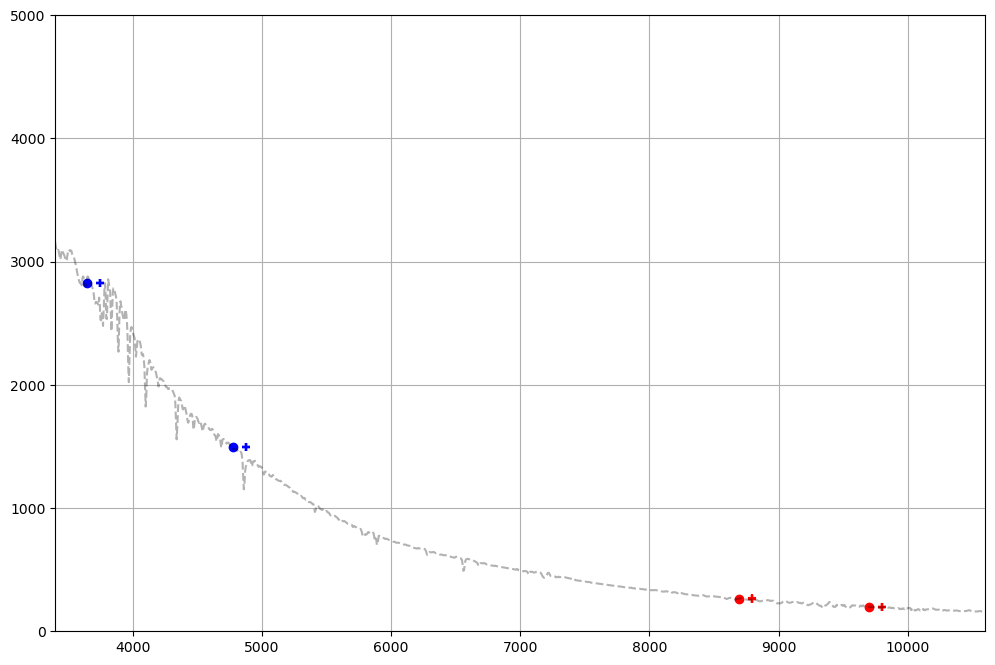

In [161]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
    
ax.plot(example_spec.wave,example_spec.flux,ls='--',color='k',alpha=0.3)
for i,filter_ in enumerate(filters_b):
    ax.scatter(lambdas_b[i],F0_b[example_id]['std'][i],color='b')
    for isim in range(n_sim):
        ax.scatter(lambdas_b[i]+100,F0_b[example_id][isim][i],marker='+',color='b')
for i,filter_ in enumerate(filters_r):
    ax.scatter(lambdas_r[i],F0_r[example_id]['std'][i],color='r')
    for isim in range(n_sim):
        ax.scatter(lambdas_r[i]+100,F0_r[example_id][isim][i],marker='+',color='r')

ax.set_xlim(WLMIN,WLMAX)
ax.set_ylim(0.,5000.)
ax.grid()

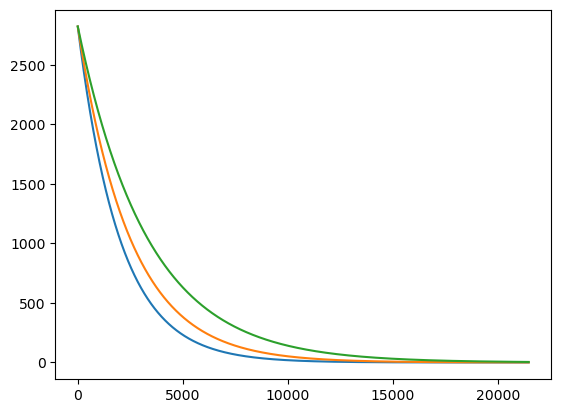

In [162]:
plt.plot(wl_baseline,exp_fun_down(wl_baseline,cte_A[example_id][filters_b[0]]['std'],-5e-04))
plt.plot(wl_baseline,exp_fun_down(wl_baseline,cte_A[example_id][filters_b[0]]['std'],-4e-04))
plt.plot(wl_baseline,exp_fun_down(wl_baseline,cte_A[example_id][filters_b[0]]['std'],-3e-04))

In [163]:
params_b = {}
params_r = {}
function_b = {}
function_r = {}

for ised in sed_dict.keys():
    #print(ised)
    params_b[ised] = {}
    params_r[ised] = {}
    function_b[ised] = {}
    function_r[ised] = {}
    
    k0_b_ = np.log(cte_A[ised][filters_b[-1]]['std']/cte_A[ised][filters_b[0]]['std'])/(lambdas_b[-1]-lambdas_b[0])
    k0_r_ = np.log(cte_A[ised][filters_r[-1]]['std']/cte_A[ised][filters_r[0]]['std'])/(lambdas_r[-1]-lambdas_r[0])
    
    p0_b_ = np.array([cte_A[ised][filters_b[0]]['std'],k0_b_])
    #p0_r_ = np.array([cte_A[ised][filters_r[-1]]['std'],lambdas_r[-1]])    
    
    if cte_A[ised][filters_b[0]]['std']>=cte_A[ised][filters_b[1]]['std']:
        fun_b_ = exp_fun_down
    else:
        fun_b_ = exp_fun_up
    
    if cte_A[ised][filters_b[0]]['std']>=cte_A[ised][filters_b[1]]['std']:
        fun_r_ = exp_fun_down
        p0_r_ = np.array([cte_A[ised][filters_r[0]]['std'],k0_r_])
    else:
        fun_r_ = gauss_fun
        p0_r_ = np.array([cte_A[ised][filters_r[-1]]['std'],lambdas_r[-1]])
    
    params_b[ised]['std'],_ = curve_fit(fun_b_,lambdas_b,F0_b[ised]['std'],p0=p0_b_)
    params_r[ised]['std'],_ = curve_fit(fun_r_,lambdas_r,F0_r[ised]['std'],p0=p0_r_)
    function_b[ised]['std'] = fun_b_
    function_r[ised]['std'] = fun_r_
    
    for isim in range(n_sim):
        #print(isim)
        
        p0_b_ = np.array([cte_A[ised][filters_b[0]][isim],k0_b_])
        #p0_r_ = np.array([cte_A[ised][filters_r[-1]][isim],lambdas_r[-1]])
        
        if cte_A[ised][filters_b[0]][isim]>=cte_A[ised][filters_b[1]][isim]:
            fun_b_ = exp_fun_down
        else:
            fun_b_ = exp_fun_up
        
        if cte_A[ised][filters_b[0]][isim]>=cte_A[ised][filters_b[1]][isim]:
            fun_r_ = exp_fun_down
            p0_r_ = np.array([cte_A[ised][filters_r[0]][isim],k0_r_])
        else:
            fun_r_ = gauss_fun
            p0_r_ = np.array([cte_A[ised][filters_r[-1]][isim],lambdas_r[-1]])
        
        params_b[ised][isim],_ = curve_fit(fun_b_,lambdas_b,F0_b[ised][isim],p0=p0_b_)
        params_r[ised][isim],_ = curve_fit(fun_r_,lambdas_r,F0_r[ised][isim],p0=p0_r_)
        function_b[ised][isim] = fun_b_
        function_r[ised][isim] = fun_r_
    
    

/tmp/ipykernel_34263/1337342289.py:31: OptimizeWarning: Covariance of the parameters could not be estimated
  params_b[ised]['std'],_ = curve_fit(fun_b_,lambdas_b,F0_b[ised]['std'],p0=p0_b_)
/tmp/ipykernel_34263/1337342289.py:32: OptimizeWarning: Covariance of the parameters could not be estimated
  params_r[ised]['std'],_ = curve_fit(fun_r_,lambdas_r,F0_r[ised]['std'],p0=p0_r_)
/tmp/ipykernel_34263/1337342289.py:54: OptimizeWarning: Covariance of the parameters could not be estimated
  params_b[ised][isim],_ = curve_fit(fun_b_,lambdas_b,F0_b[ised][isim],p0=p0_b_)
/tmp/ipykernel_34263/1337342289.py:55: OptimizeWarning: Covariance of the parameters could not be estimated
  params_r[ised][isim],_ = curve_fit(fun_r_,lambdas_r,F0_r[ised][isim],p0=p0_r_)


In [164]:
params_b

{'pickles_uk_2': {'std': array([ 2.18379375e+04, -5.60878974e-04]),
  0: array([ 2.18386768e+04, -5.60888331e-04]),
  1: array([ 2.18383113e+04, -5.60883708e-04]),
  2: array([ 2.18379375e+04, -5.60878974e-04]),
  3: array([ 2.18375518e+04, -5.60874084e-04]),
  4: array([ 2.18371481e+04, -5.60868953e-04]),
  5: array([ 2.1836075e+04, -5.6085484e-04]),
  6: array([ 2.18331055e+04, -5.60815266e-04]),
  7: array([ 2.18251669e+04, -5.60709022e-04]),
  8: array([ 2.18243934e+04, -5.60698917e-04])}}

In [165]:
params_r

{'pickles_uk_2': {'std': array([ 3.51634766e+03, -2.97002270e-04]),
  0: array([ 3.40018541e+03, -2.93236659e-04]),
  1: array([ 3.46267496e+03, -2.95278312e-04]),
  2: array([ 3.51634766e+03, -2.97002270e-04]),
  3: array([ 3.56470513e+03, -2.98533519e-04]),
  4: array([ 3.60918661e+03, -2.99924448e-04]),
  5: array([ 3.65057793e+03, -3.01204128e-04]),
  6: array([ 3.68941052e+03, -3.02392240e-04]),
  7: array([ 3.72608817e+03, -3.03503501e-04]),
  8: array([ 3.76092873e+03, -3.04549785e-04])}}

In [166]:
function_b,function_r

({'pickles_uk_2': {'std': <function __main__.exp_fun_down(l, A, k)>,
   0: <function __main__.exp_fun_down(l, A, k)>,
   1: <function __main__.exp_fun_down(l, A, k)>,
   2: <function __main__.exp_fun_down(l, A, k)>,
   3: <function __main__.exp_fun_down(l, A, k)>,
   4: <function __main__.exp_fun_down(l, A, k)>,
   5: <function __main__.exp_fun_down(l, A, k)>,
   6: <function __main__.exp_fun_down(l, A, k)>,
   7: <function __main__.exp_fun_down(l, A, k)>,
   8: <function __main__.exp_fun_down(l, A, k)>}},
 {'pickles_uk_2': {'std': <function __main__.exp_fun_down(l, A, k)>,
   0: <function __main__.exp_fun_down(l, A, k)>,
   1: <function __main__.exp_fun_down(l, A, k)>,
   2: <function __main__.exp_fun_down(l, A, k)>,
   3: <function __main__.exp_fun_down(l, A, k)>,
   4: <function __main__.exp_fun_down(l, A, k)>,
   5: <function __main__.exp_fun_down(l, A, k)>,
   6: <function __main__.exp_fun_down(l, A, k)>,
   7: <function __main__.exp_fun_down(l, A, k)>,
   8: <function __main__.ex

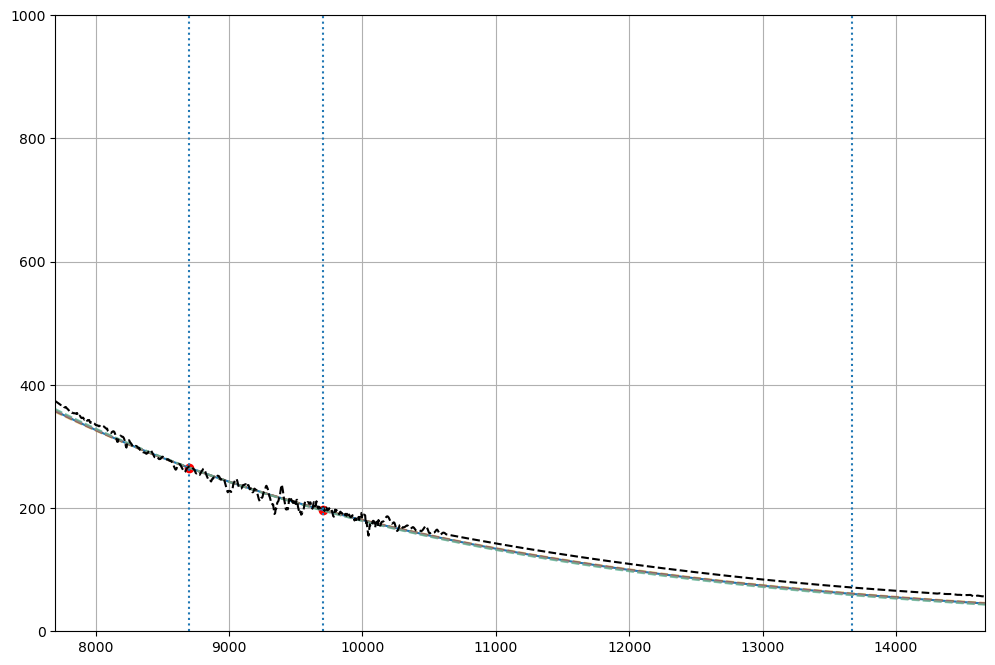

In [167]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

ax.plot(wl_baseline,function_r[example_id]['std'](wl_baseline,params_r[example_id]['std'][0],params_r[example_id]['std'][1]))
for isim in range(n_sim):
    ax.plot(wl_baseline,function_r[example_id][isim](wl_baseline,params_r[example_id][isim][0],params_r[example_id][isim][1]),ls='--',alpha=0.4)
ax.plot(example_spec.wave,example_spec.flux,ls='--',color='k')
for i,filter_ in enumerate(filters_r):
    ax.scatter(lambdas_r[i],F0_r[example_id]['std'][i],color='r')
ax.axvline(x=lambdas_r[0],ls=':')
ax.axvline(x=lambdas_r[1],ls=':')
ax.axvline(x=eu_eff_lambda[eu_for_sigma],ls=':')
ax.set_xlim(lambdas_r[0]-1000.,eu_eff_lambda[eu_for_sigma]+1000.)
ax.set_ylim(0.,1000.)
ax.grid()


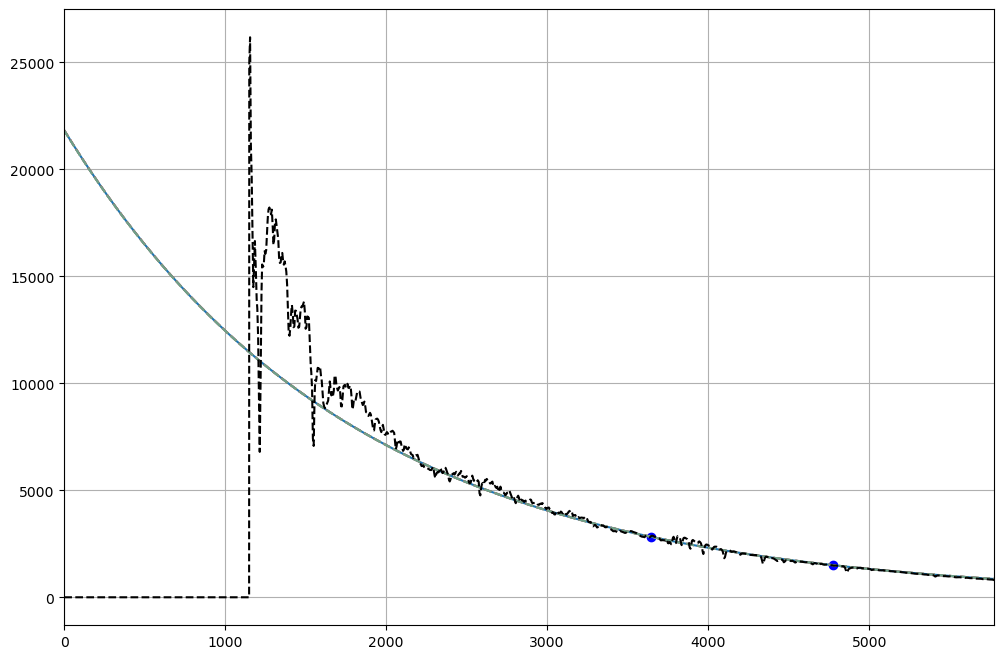

In [168]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

ax.plot(wl_baseline,function_b[example_id]['std'](wl_baseline,params_b[example_id]['std'][0],params_b[example_id]['std'][1]))
for isim in range(n_sim):
    ax.plot(wl_baseline,function_b[example_id][isim](wl_baseline,params_b[example_id][isim][0],params_b[example_id][isim][1]),ls='--',alpha=0.4)
for i,filter_ in enumerate(filters_b):
    ax.scatter(lambdas_b[i],F0_b[example_id]['std'][i],color='b')
ax.plot(example_spec.wave,example_spec.flux,ls='--',color='k')
ax.set_xlim(0.,lambdas_b[-1]+1000.)
#ax.set_ylim(0.,F0_b[example_id]['std'][-1])
#ax.set_yscale("log")
ax.grid()


In [169]:
guess_spec_dict_b = {}
guess_spec_dict_r = {}

for ised in sed_dict.keys():
    #print(len(lin_a_vec_std_dict[ised]))
    guess_spec_dict_b[ised] = {}
    guess_spec_dict_r[ised] = {}
    guess_spec_dict_b[ised]['std'] = function_b[ised]['std'](wl_baseline,params_b[example_id]['std'][0],params_b[example_id]['std'][1])
    guess_spec_dict_r[ised]['std'] = function_r[ised]['std'](wl_baseline,params_r[example_id]['std'][0],params_r[example_id]['std'][1])
    
    for isim in range(n_sim):
        guess_spec_dict_b[ised][isim] = function_b[ised][isim](wl_baseline,params_b[example_id][isim][0],params_b[example_id][isim][1])
        guess_spec_dict_r[ised][isim] = function_r[ised][isim](wl_baseline,params_r[example_id][isim][0],params_r[example_id][isim][1])
        

### Set the estimated spectra in pysynphot format 

In [170]:
guess_dict_b = {}
guess_dict_r = {}

for ised in sed_dict.keys():
    guess_dict_b[ised] = {}
    guess0_ = S.ArraySpectrum(wl_baseline,guess_spec_dict_b[ised]['std'])
    guess_dict_b[ised]['std'] = guess0_
    
    guess_dict_r[ised] = {}
    guess0_ = S.ArraySpectrum(wl_baseline,guess_spec_dict_r[ised]['std'])
    guess_dict_r[ised]['std'] = guess0_
    
    for isim in range(n_sim):
        guess0_ = S.ArraySpectrum(wl_baseline,guess_spec_dict_b[ised][isim])
        guess_dict_b[ised][isim] = guess0_
        
        guess0_ = S.ArraySpectrum(wl_baseline,guess_spec_dict_r[ised][isim])
        guess_dict_r[ised][isim] = guess0_
        
    

### Make the estimated spectra pass through the current atmosphere they were fitted from 

Here, we are making each $\tilde{F}_t(\lambda)$ pass through the corresponding current atmosphere, $T_b(\lambda;t)$ they are fitted from. 

In [171]:

obs_guess_std_dict_b = {}
obs_guess_t_dict_b = {}

obs_guess_std_dict_r = {}
obs_guess_t_dict_r = {}

for ised in sed_dict.keys():
    obs_guess_std_dict_b[ised] = {}
    obs_guess_t_dict_b[ised] = {}
    
    obs_guess_std_dict_r[ised] = {}
    obs_guess_t_dict_r[ised] = {}
    for filter_ in filters:
        guess_total_ = S.Observation(guess_dict_b[ised]['std'],total_passband_ref[filter_],force='taper')
        obs_guess_std_dict_b[ised][filter_] = guess_total_
        
        guess_total_ = S.Observation(guess_dict_r[ised]['std'],total_passband_ref[filter_],force='taper')
        obs_guess_std_dict_r[ised][filter_] = guess_total_
        
        obs_guess_t_dict_b[ised][filter_] = []
        obs_guess_t_dict_r[ised][filter_] = []
        for isim in range(n_sim):
            guess_total_ = S.Observation(guess_dict_b[ised][isim],total_passband[filter_][isim],force='taper')
            obs_guess_t_dict_b[ised][filter_].append(guess_total_)
            
            guess_total_ = S.Observation(guess_dict_r[ised][isim],total_passband[filter_][isim],force='taper')
            obs_guess_t_dict_r[ised][filter_].append(guess_total_)
            
    

### Make the estimated spectra pass through the standard atmosphere 

Here, we are making each $\tilde{F}^r_t(\lambda)$ pass through the standard atmosphere, $T_b^{std}(\lambda)$.   

In [172]:

std_guess_t_dict_b = {}
std_guess_t_dict_r = {}

for ised in sed_dict.keys():
    
    std_guess_t_dict_b[ised] = {}
    std_guess_t_dict_r[ised] = {}
    
    for filter_ in filters:
        std_guess_t_dict_b[ised][filter_] = []
        std_guess_t_dict_r[ised][filter_] = []
        for isim in range(n_sim):
            guess_cross_ = S.Observation(guess_dict_b[ised][isim],total_passband_ref[filter_],force='taper')
            std_guess_t_dict_b[ised][filter_].append(guess_cross_)
            
            guess_cross_ = S.Observation(guess_dict_r[ised][isim],total_passband_ref[filter_],force='taper')
            std_guess_t_dict_r[ised][filter_].append(guess_cross_)
        
    

### Make the gaussian spectra pass through the Euclid's filters 

Here, we are making each $\tilde{F}^r_t(\lambda)$ pass through the Euclid's passband, $T_{J_E}(\lambda)$.  

In [173]:
eu_guess_t_dict = {}

for ised in sed_dict.keys():
    
    eu_guess_t_dict[ised] = {}
    
    for i,filter_ in enumerate(eu_filters):
        eu_guess_t_dict[ised][filter_] = []
        for isim in range(n_sim):
            gauss_cross_ = S.Observation(guess_dict_r[ised][isim],euclid_bp[i],force='taper')
            eu_guess_t_dict[ised][filter_].append(gauss_cross_)
        

In [174]:
eu_guess_t_dict[example_id]['Je'][ref_ind_].binflux

array([0., 0., 0., ..., 0., 0., 0.])

### Make the exponential spectra pass through the SWIFT's filters 

Here, we are making each $\tilde{F}^b_t(\lambda)$ pass through the SWIFT's passband, $T_{UVM2}(\lambda)$.  

In [175]:
swift_guess_t_dict = {}

for ised in sed_dict.keys():
    
    swift_guess_t_dict[ised] = {}
    
    for i,filter_ in enumerate(swift_filters):
        swift_guess_t_dict[ised][filter_] = []
        for isim in range(n_sim):
            exp_cross_ = S.Observation(guess_dict_b[ised][isim],swift_bp[i],force='taper')
            swift_guess_t_dict[ised][filter_].append(exp_cross_)
        

### Make the exponential spectra pass through the Gaussian filters 

Here, we are making each $\tilde{F}^b_t(\lambda)$ pass through the Gaussian passband.  

In [176]:
gauss_guess_t_dict = {}

for ised in sed_dict.keys():
    
    gauss_guess_t_dict[ised] = {}
    
    for i,filter_ in enumerate(gauss_filters):
        gauss_guess_t_dict[ised][filter_] = []
        for isim in range(n_sim):
            exp_cross_ = S.Observation(guess_dict_b[ised][isim],gauss_bp[i],force='taper')
            gauss_guess_t_dict[ised][filter_].append(exp_cross_)
        

In [177]:
eu_filters

['Ye', 'Je', 'He']

#### Plot gaussian spectra fitted from the red end 

<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\g'
<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/2494304161.py:20: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/2494304161.py:21: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


Ye
Je
He
photlam


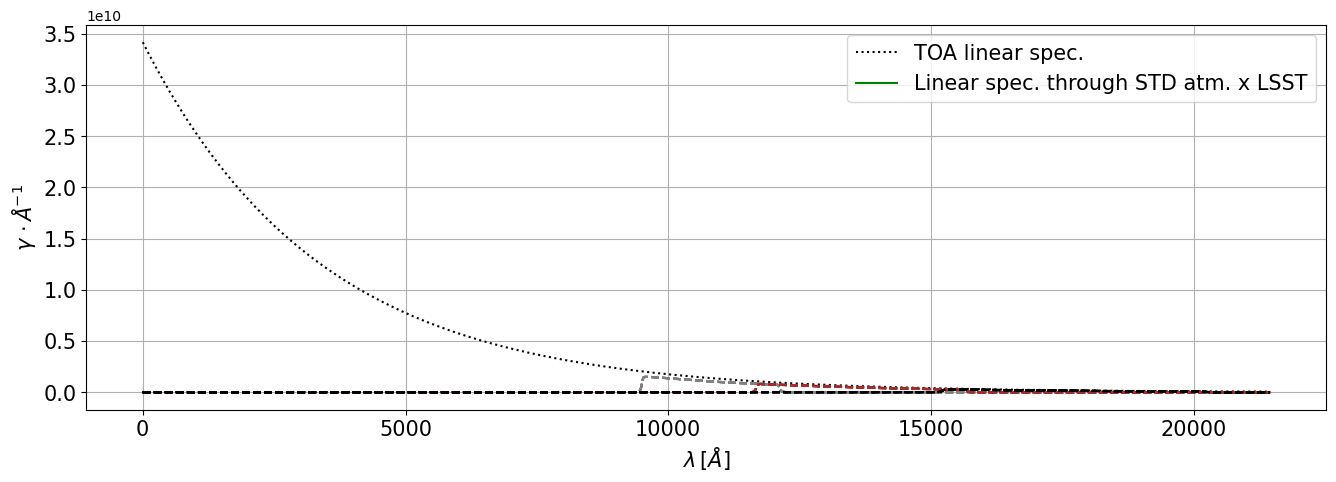

In [178]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)

ax.plot(guess_dict_r[example_id][ref_ind_].wave,guess_dict_r[example_id][ref_ind_].flux*Seff*exptime,ls=':',color='k',alpha=1.0)
'''
for index,filter_ in enumerate(filters):
    print(filter_)
    for isim in range(n_sim):
        obs = std_exp_t_dict_r[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
'''    
for index,filter_ in enumerate(eu_filters):
    print(filter_)
    for isim in range(n_sim):
        obs = eu_guess_t_dict[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=eu_colors[filter_],alpha=1.0)

#ax.set_xlim(WLMIN,WLMAX)
#ax.set_ylim(0.,0.5e13)
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.grid()
ax.plot([],[],ls=':',color='k',label='TOA linear spec.')
ax.plot([],[],ls='-',color='g',label='Linear spec. through STD atm. x LSST')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
print(spec.fluxunits)

#### Plot exponential spectra fitter from the blue end (SWIFT) 

<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3931229280.py:21: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3931229280.py:22: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
UVW2
UVM2
UVW1
photlam


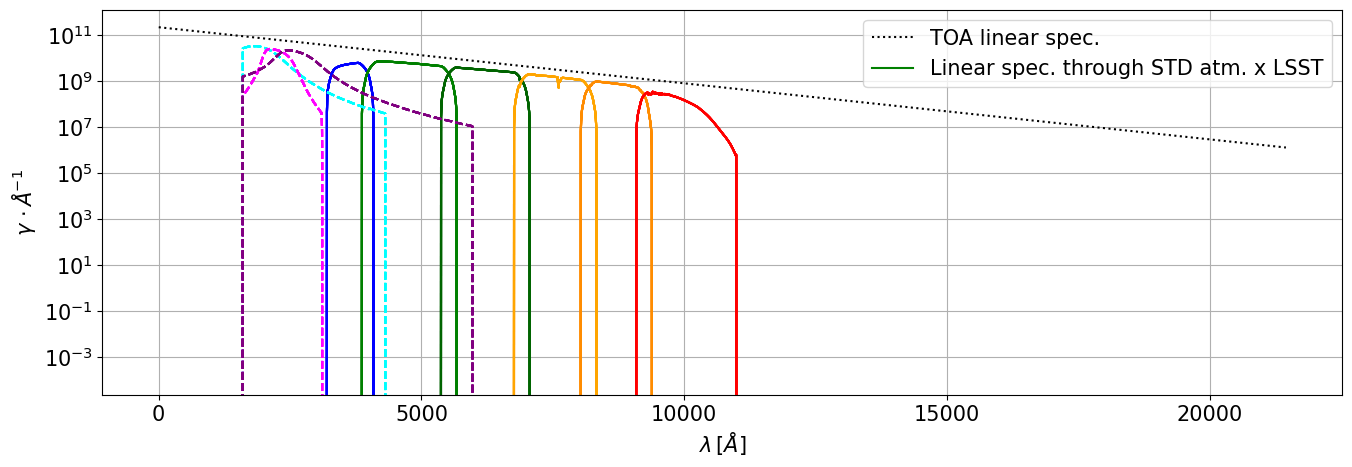

In [179]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)

ax.plot(guess_dict_b[example_id][ref_ind_].wave,guess_dict_b[example_id][ref_ind_].flux*Seff*exptime,ls=':',color='k',alpha=1.0)

for index,filter_ in enumerate(filters):
    print(filter_)
    for isim in range(n_sim):
        obs = std_guess_t_dict_b[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    
for index,filter_ in enumerate(swift_filters):
    print(filter_)
    for isim in range(n_sim):
        obs = swift_guess_t_dict[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=swift_colors[filter_],alpha=1.0)

#ax.set_xlim(2500.,6500.)
#ax.set_ylim(0.,0.25e10)
ax.set_yscale("log")
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.grid()
ax.plot([],[],ls=':',color='k',label='TOA linear spec.')
ax.plot([],[],ls='-',color='g',label='Linear spec. through STD atm. x LSST')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
print(spec.fluxunits)

<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\g'
<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/2118602735.py:20: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/2118602735.py:21: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
UVW2
UVM2
UVW1
photlam


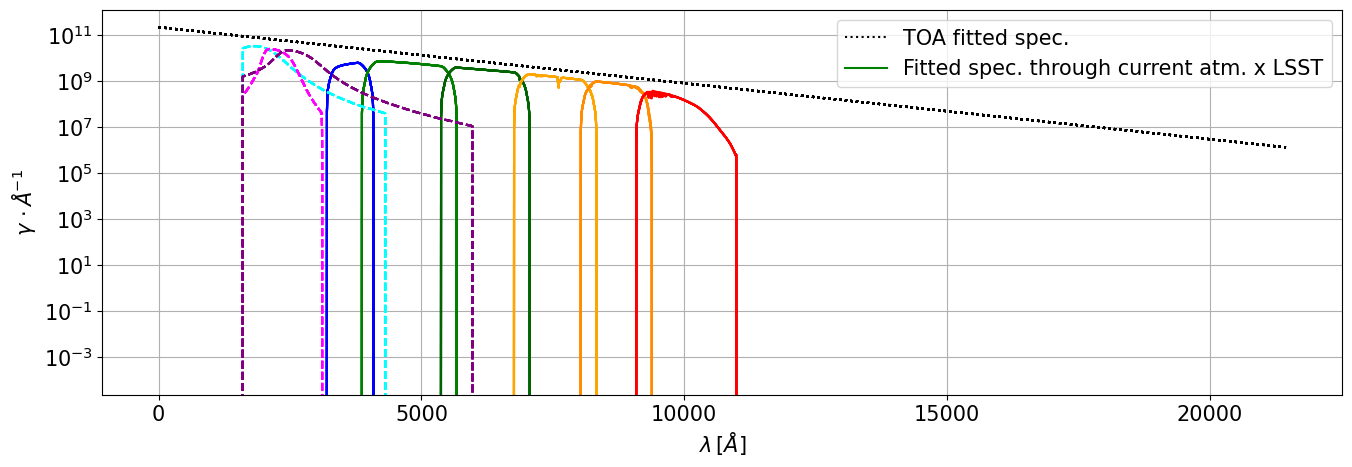

In [180]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)

for index,filter_ in enumerate(filters):
    print(filter_)
    for isim in range(n_sim):
        ax.plot(guess_dict_b[example_id][isim].wave,guess_dict_b[example_id][isim].flux*Seff*exptime,ls=':',color='k',alpha=1.0)
        obs = obs_guess_t_dict_b[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
        
for index,filter_ in enumerate(swift_filters):
    print(filter_)
    for isim in range(n_sim):
        obs = swift_guess_t_dict[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=swift_colors[filter_],alpha=1.0)

#ax.set_xlim(2500.,6500.)
#ax.set_ylim(0.,0.25e10)
ax.set_yscale("log")
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.grid()
ax.plot([],[],ls=':',color='k',label='TOA fitted spec.')
ax.plot([],[],ls='-',color='g',label='Fitted spec. through current atm. x LSST')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
print(spec.fluxunits)

#### Plot exponential spectra fitter from the blue end (Gaussian) 

<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3948063899.py:21: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3948063899.py:22: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
gauss_0
gauss_1
gauss_2
gauss_3
gauss_4
photlam


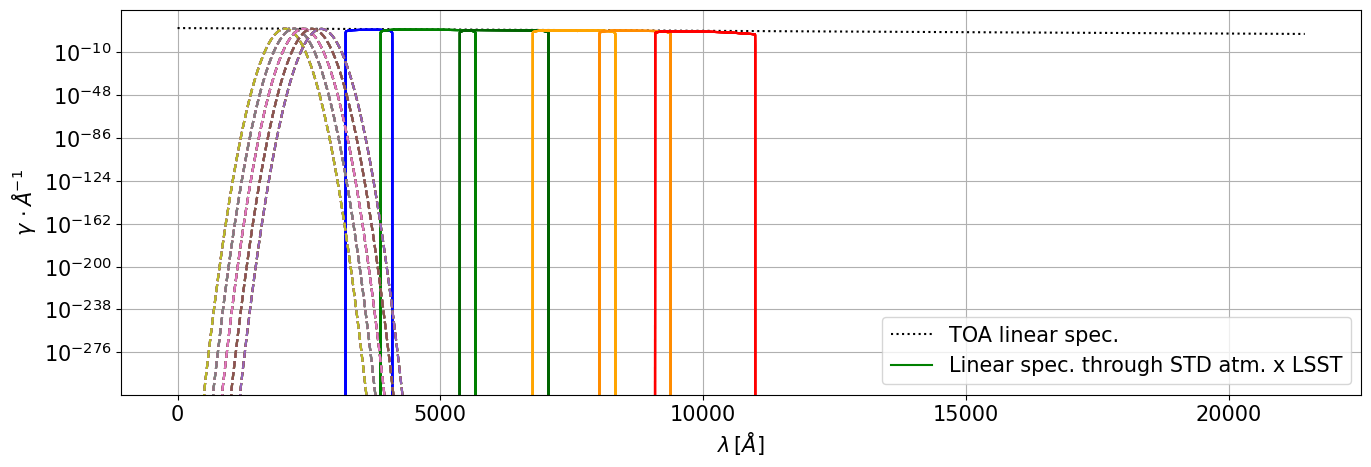

In [181]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)

ax.plot(guess_dict_b[example_id][ref_ind_].wave,guess_dict_b[example_id][ref_ind_].flux*Seff*exptime,ls=':',color='k',alpha=1.0)

for index,filter_ in enumerate(filters):
    print(filter_)
    for isim in range(n_sim):
        obs = std_guess_t_dict_b[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    
for index,filter_ in enumerate(gauss_filters):
    print(filter_)
    for isim in range(n_sim):
        obs = gauss_guess_t_dict[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',alpha=1.0)

#ax.set_xlim(2500.,6500.)
#ax.set_ylim(0.,0.25e10)
ax.set_yscale("log")
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.grid()
ax.plot([],[],ls=':',color='k',label='TOA linear spec.')
ax.plot([],[],ls='-',color='g',label='Linear spec. through STD atm. x LSST')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
print(spec.fluxunits)

<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\g'
<>:20: SyntaxWarning: invalid escape sequence '\,'
<>:21: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/2796747810.py:20: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/2796747810.py:21: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
gauss_0
gauss_1
gauss_2
gauss_3
gauss_4
photlam


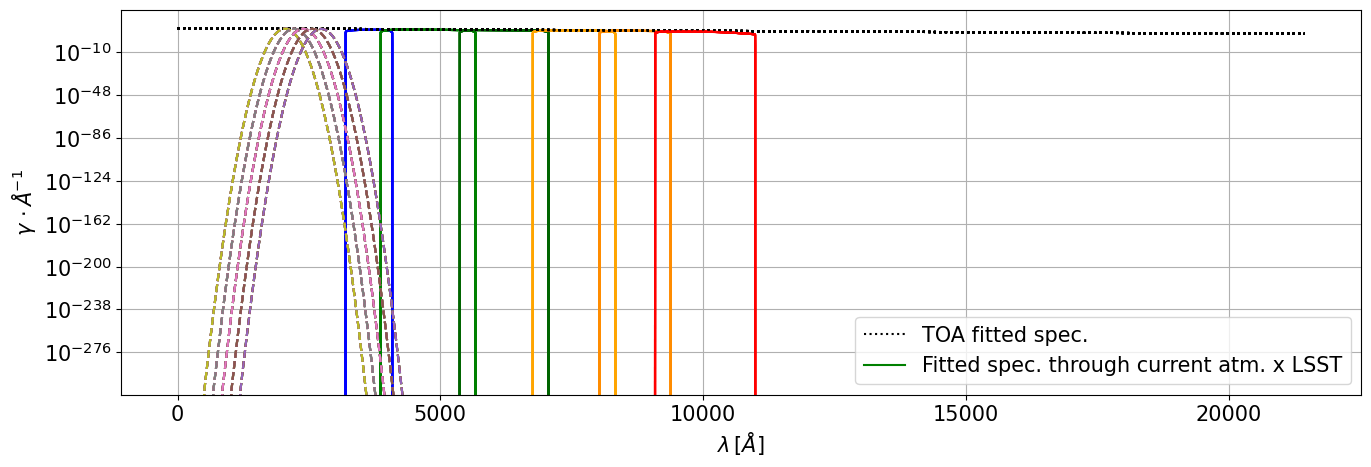

In [182]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)

for index,filter_ in enumerate(filters):
    print(filter_)
    for isim in range(n_sim):
        ax.plot(guess_dict_b[example_id][isim].wave,guess_dict_b[example_id][isim].flux*Seff*exptime,ls=':',color='k',alpha=1.0)
        obs = obs_guess_t_dict_b[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
        
for index,filter_ in enumerate(gauss_filters):
    print(filter_)
    for isim in range(n_sim):
        obs = gauss_guess_t_dict[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',alpha=1.0)

#ax.set_xlim(2500.,6500.)
#ax.set_ylim(0.,0.25e10)
ax.set_yscale("log")
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.grid()
ax.plot([],[],ls=':',color='k',label='TOA fitted spec.')
ax.plot([],[],ls='-',color='g',label='Fitted spec. through current atm. x LSST')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
print(spec.fluxunits)

### Calculate integrated fluxes and magnitudes from estimated spectra through corresponding current atmosphere 

In [183]:
guess_Phi_t_dict_r = {}
guess_Mag_t_dict_r = {}
guess_Phi_t_dict_b = {}
guess_Mag_t_dict_b = {}

for ised in sed_dict.keys():
    guess_Phi_t_dict_r[ised] = {}
    guess_Mag_t_dict_r[ised] = {}
    guess_Phi_t_dict_b[ised] = {}
    guess_Mag_t_dict_b[ised] = {}
    for index,filter_ in enumerate(filters):
        guess_Phi_t_dict_r[ised][filter_] = []
        guess_Mag_t_dict_r[ised][filter_] = []
        guess_Phi_t_dict_b[ised][filter_] = []
        guess_Mag_t_dict_b[ised][filter_] = []
        for isim in range(n_sim):
            num_,mag_ = int_flux(guess_dict_r[ised][isim],total_passband[filter_][isim],return_mag=True,PhiAB=Phi_AB[index])
            guess_Phi_t_dict_r[ised][filter_].append(num_)
            guess_Mag_t_dict_r[ised][filter_].append(mag_)
            
            num_,mag_ = int_flux(guess_dict_b[ised][isim],total_passband[filter_][isim],return_mag=True,PhiAB=Phi_AB[index])
            guess_Phi_t_dict_b[ised][filter_].append(num_)
            guess_Mag_t_dict_b[ised][filter_].append(mag_)
        
    
    

### Calculate integrated fluxes and magnitudes from estimated spectra through standard atmosphere 

In [184]:
guess_Phi_std_dict_r = {}
guess_Mag_std_dict_r = {}
guess_Phi_std_dict_b = {}
guess_Mag_std_dict_b = {}

for ised in sed_dict.keys():
    guess_Phi_std_dict_r[ised] = {}
    guess_Mag_std_dict_r[ised] = {}
    guess_Phi_std_dict_b[ised] = {}
    guess_Mag_std_dict_b[ised] = {}
    for index,filter_ in enumerate(filters):
        guess_Phi_std_dict_r[ised][filter_] = []
        guess_Mag_std_dict_r[ised][filter_] = []
        guess_Phi_std_dict_b[ised][filter_] = []
        guess_Mag_std_dict_b[ised][filter_] = []
        for isim in range(n_sim):
            num_,mag_ = int_flux(guess_dict_r[ised][isim],total_passband_ref[filter_],return_mag=True,PhiAB=Phi_AB[index])
            guess_Phi_std_dict_r[ised][filter_].append(num_)
            guess_Mag_std_dict_r[ised][filter_].append(mag_)
            num_,mag_ = int_flux(guess_dict_b[ised][isim],total_passband_ref[filter_],return_mag=True,PhiAB=Phi_AB[index])
            guess_Phi_std_dict_b[ised][filter_].append(num_)
            guess_Mag_std_dict_b[ised][filter_].append(mag_)
        
    

### Calculate integrated fluxes and magnitudes from gaussian spectra through Euclid's filters 

In [185]:
guess_Phi_eu_dict = {}
guess_Phi_err_eu_dict = {}
guess_Mag_eu_dict = {}

for ised in sed_dict.keys():
    guess_Phi_eu_dict[ised] = {}
    guess_Phi_err_eu_dict[ised] = {}
    guess_Mag_eu_dict[ised] = {}
    for index,filter_ in enumerate(eu_filters):
        guess_Phi_eu_dict[ised][filter_] = []
        guess_Phi_err_eu_dict[ised][filter_] = []
        guess_Mag_eu_dict[ised][filter_] = []
        for isim in range(n_sim):
            num_,mag_,num_err_,mag_err_ = int_flux(guess_dict_r[ised][isim],euclid_bp[index],return_mag=True,return_error=True,PhiAB=Phi_AB_eu[index])
            guess_Phi_eu_dict[ised][filter_].append(num_)
            guess_Phi_err_eu_dict[ised][filter_].append(num_err_)
            guess_Mag_eu_dict[ised][filter_].append(mag_)
        
    
    

### Calculate integrated fluxes and magnitudes from exponential spectra through SWIFT's filters 

In [186]:
guess_Phi_swift_dict = {}
guess_Phi_err_swift_dict = {}
guess_Mag_swift_dict = {}

for ised in sed_dict.keys():
    guess_Phi_swift_dict[ised] = {}
    guess_Phi_err_swift_dict[ised] = {}
    guess_Mag_swift_dict[ised] = {}
    for index,filter_ in enumerate(swift_filters):
        guess_Phi_swift_dict[ised][filter_] = []
        guess_Phi_err_swift_dict[ised][filter_] = []
        guess_Mag_swift_dict[ised][filter_] = []
        for isim in range(n_sim):
            num_,mag_,num_err_,mag_err_ = int_flux(guess_dict_b[ised][isim],swift_bp[index],return_mag=True,return_error=True,PhiAB=Phi_AB_swift[index])
            guess_Phi_swift_dict[ised][filter_].append(num_)
            guess_Phi_err_swift_dict[ised][filter_].append(num_err_)
            guess_Mag_swift_dict[ised][filter_].append(mag_)
        
    

### Calculate integrated fluxes and magnitudes from exponential spectra through Gaussian filters 

In [187]:
guess_Phi_gauss_dict = {}
guess_Mag_gauss_dict = {}

for ised in sed_dict.keys():
    guess_Phi_gauss_dict[ised] = {}
    guess_Mag_gauss_dict[ised] = {}
    for index,filter_ in enumerate(gauss_filters):
        guess_Phi_gauss_dict[ised][filter_] = []
        guess_Mag_gauss_dict[ised][filter_] = []
        for isim in range(n_sim):
            num_,mag_ = int_flux(guess_dict_b[ised][isim],gauss_bp[index],return_mag=True,PhiAB=Phi_AB_gauss[index])
            guess_Phi_gauss_dict[ised][filter_].append(num_)
            guess_Mag_gauss_dict[ised][filter_].append(mag_)
        
    

### And now we compare with the integrated fluxes from the real spectrum for each atmospheric situation 

In [188]:
phi_eu_dict[example_id],phi_swift_dict[example_id],phi_gauss_dict[example_id]

({'Ye': 3010106528915.8887, 'Je': 2304814664685.8706, 'He': 1302922500132.175},
 {'UVW2': 22279917684103.02,
  'UVM2': 11990014546398.562,
  'UVW1': 16784769869114.088},
 {'gauss_0': 5822579916576.662,
  'gauss_1': 4898041353874.076,
  'gauss_2': 4507778867060.325,
  'gauss_3': 4207570671991.6123,
  'gauss_4': 3833216228091.0176})

<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3202255181.py:17: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3202255181.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


photlam


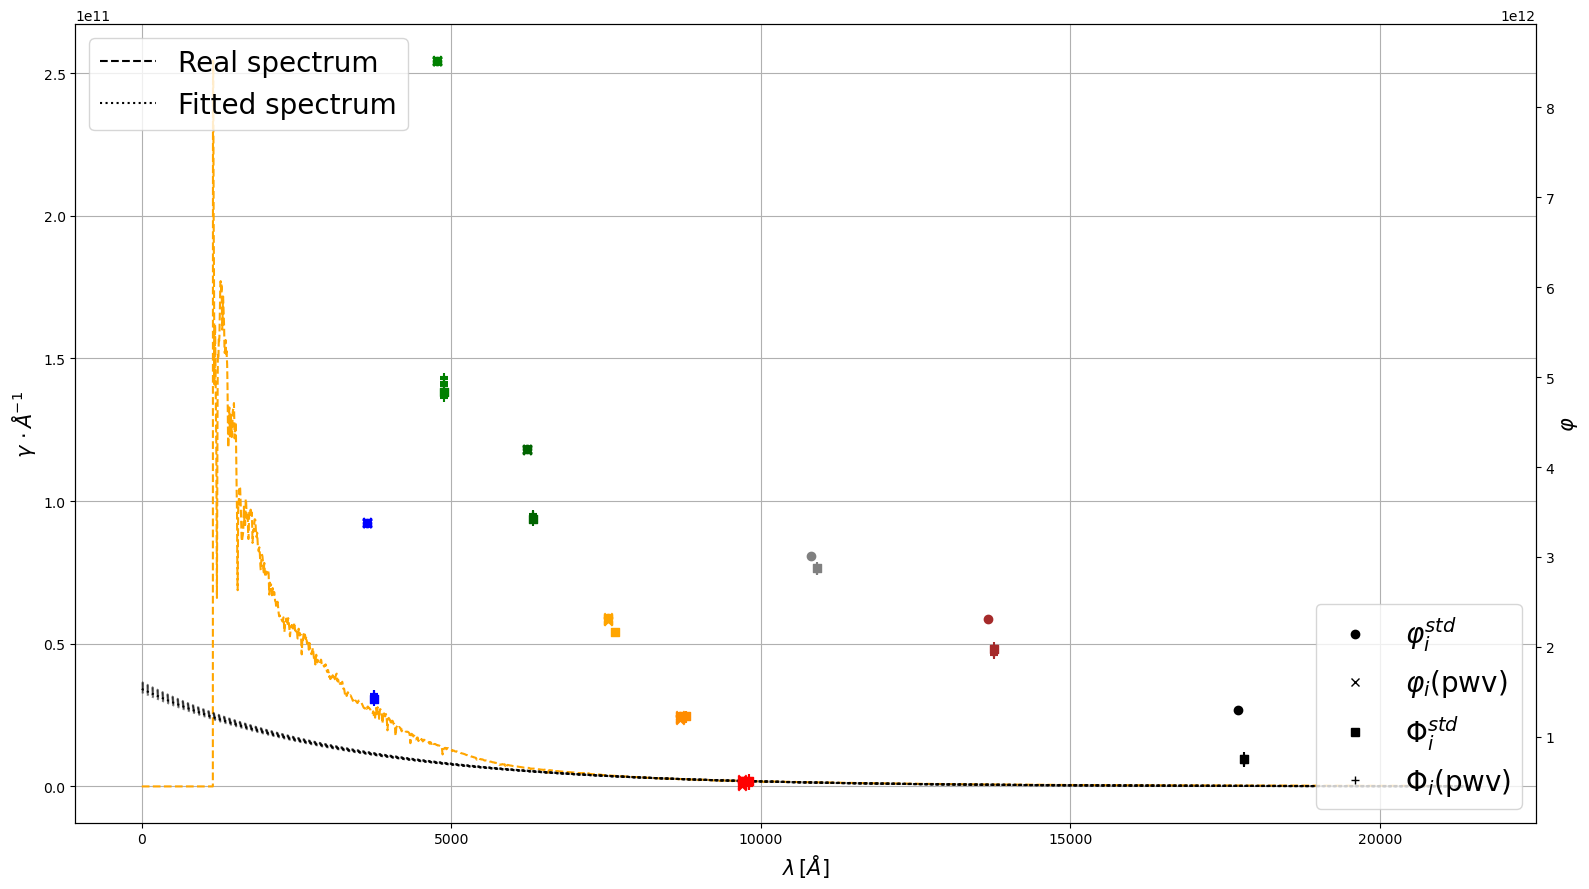

In [189]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,example_spec.flux*Seff*exptime,ls='--',color='orange',alpha=1.0)
ax1.plot(guess_dict_r[example_id]['std'].wave,guess_dict_r[example_id]['std'].flux*Seff*exptime,ls=':',color='k',alpha=1.0)
for isim in range(n_sim):
    ax1.plot(guess_dict_r[example_id]['std'].wave,guess_dict_r[example_id][isim].flux*Seff*exptime,ls=':',color='k',alpha=0.5)

ax2 = ax1.twinx()
    
#ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_xlim(10000,12000)
#ax1.set_ylim(1.387e10,1.389e10)
#ax2.set_ylim(0,7.5e12)
ax1.plot([],[],ls='--',color='k',label='Real spectrum')
ax1.plot([],[],ls=':',color='k',label='Fitted spectrum')
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()

for index,filter_ in enumerate(filters):
    ax2.scatter(eff_lambda[filter_],phi_std_dict[example_id][filter_],marker='o',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_std_dict_r[example_id][filter_][ref_ind_],marker='s',color=filter_colors[index])
    for isim in range(n_sim):
        ax2.scatter(eff_lambda[filter_],phi_t_dict[example_id][filter_][isim],marker='x',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_t_dict_r[example_id][filter_][isim],marker='+',color=filter_colors[index])
    
for index,filter_ in enumerate(eu_filters):
    ax2.scatter(eu_eff_lambda[filter_],phi_eu_dict[example_id][filter_],marker='o',color=eu_colors[filter_])
    ax2.scatter(eu_eff_lambda[filter_]+100.,guess_Phi_eu_dict[example_id][filter_][ref_ind_],marker='s',color=eu_colors[filter_])
    for isim in range(n_sim):
        ax2.scatter(eu_eff_lambda[filter_]+100.,guess_Phi_eu_dict[example_id][filter_][isim],marker='+',color=eu_colors[filter_])

ax2.plot([],[],ls='',marker='o',color='k',label=r'$\varphi^{std}_i$')
ax2.plot([],[],ls='',marker='x',color='k',label=r'$\varphi_i($'+'{0})'.format(variable_param))
ax2.plot([],[],ls='',marker='s',color='k',label=r'$\Phi^{std}_i$')
ax2.plot([],[],ls='',marker='+',color='k',label=r'$\Phi_i($'+'{0})'.format(variable_param))
#ax2.set_yscale("log")
ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=20,loc='upper left')
ax2.legend(fontsize=20,loc='lower right')
plt.tight_layout()
print(spec.fluxunits)

<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3011727071.py:17: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3011727071.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


photlam


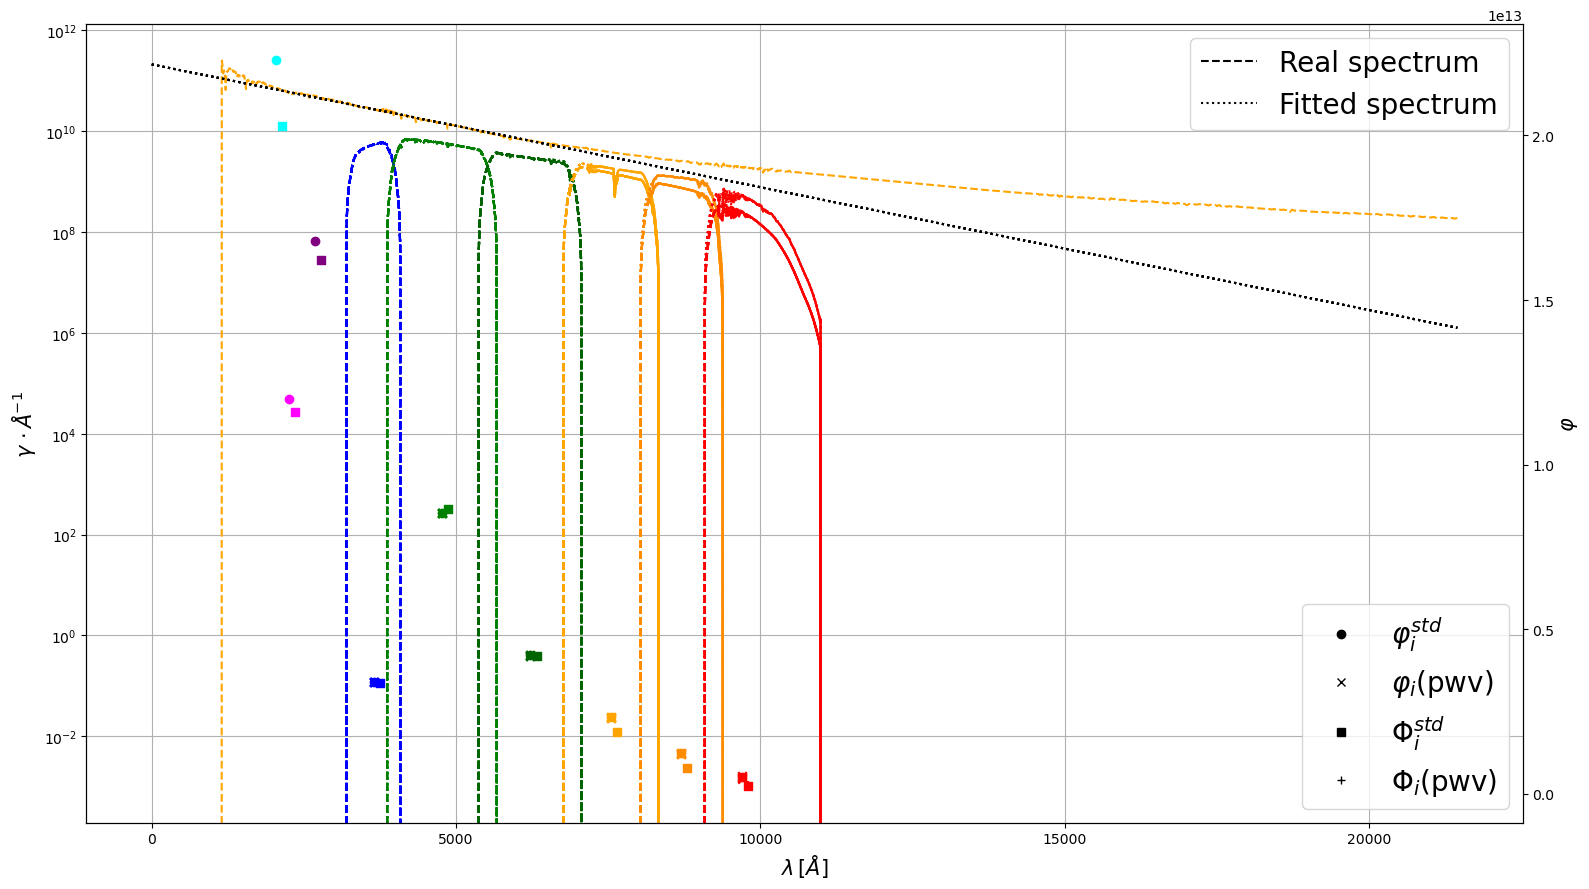

In [190]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,example_spec.flux*Seff*exptime,ls='--',color='orange',alpha=1.0)
ax1.plot(guess_dict_b[example_id]['std'].wave,guess_dict_b[example_id]['std'].flux*Seff*exptime,ls=':',color='k',alpha=1.0)
for isim in range(n_sim):
    ax1.plot(guess_dict_b[example_id]['std'].wave,guess_dict_b[example_id][isim].flux*Seff*exptime,ls=':',color='k',alpha=0.5)

ax2 = ax1.twinx()
    
#ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_xlim(10000,12000)
#ax1.set_ylim(1.387e10,1.389e10)
#ax2.set_ylim(0,7.5e12)
ax1.plot([],[],ls='--',color='k',label='Real spectrum')
ax1.plot([],[],ls=':',color='k',label='Fitted spectrum')
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()

for index,filter_ in enumerate(filters):
    ax2.scatter(eff_lambda[filter_],phi_std_dict[example_id][filter_],marker='o',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_std_dict_b[example_id][filter_][ref_ind_],marker='s',color=filter_colors[index])
    for isim in range(n_sim):
        ax1.plot(obs_flux_t_dict[example_id][filter_][isim].wave,obs_flux_t_dict[example_id][filter_][isim].flux*Seff*exptime,ls=':',color=filter_colors[index])
        ax1.plot(obs_guess_t_dict_b[example_id][filter_][isim].wave,obs_guess_t_dict_b[example_id][filter_][isim].flux*Seff*exptime,ls='--',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter_],phi_t_dict[example_id][filter_][isim],marker='x',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_t_dict_b[example_id][filter_][isim],marker='+',color=filter_colors[index])
    
for index,filter_ in enumerate(swift_filters):
    ax2.scatter(swift_eff_lambda[filter_],phi_swift_dict[example_id][filter_],marker='o',color=swift_colors[filter_])
    ax2.scatter(swift_eff_lambda[filter_]+100.,guess_Phi_swift_dict[example_id][filter_][ref_ind_],marker='s',color=swift_colors[filter_])
    for isim in range(n_sim):
        ax2.scatter(swift_eff_lambda[filter_]+100.,guess_Phi_swift_dict[example_id][filter_][isim],marker='+',color=swift_colors[filter_])

ax2.plot([],[],ls='',marker='o',color='k',label=r'$\varphi^{std}_i$')
ax2.plot([],[],ls='',marker='x',color='k',label=r'$\varphi_i($'+'{0})'.format(variable_param))
ax2.plot([],[],ls='',marker='s',color='k',label=r'$\Phi^{std}_i$')
ax2.plot([],[],ls='',marker='+',color='k',label=r'$\Phi_i($'+'{0})'.format(variable_param))
#ax1.set_xlim(0.,5000.)
#ax1.set_ylim(0.,0.6e11)
ax1.set_yscale("log")
#ax2.set_ylim(0.,1e13)
#ax2.set_yscale("log")
ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=20)
ax2.legend(fontsize=20,loc='lower right')
plt.tight_layout()
print(spec.fluxunits)

<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3195483677.py:17: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3195483677.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


photlam


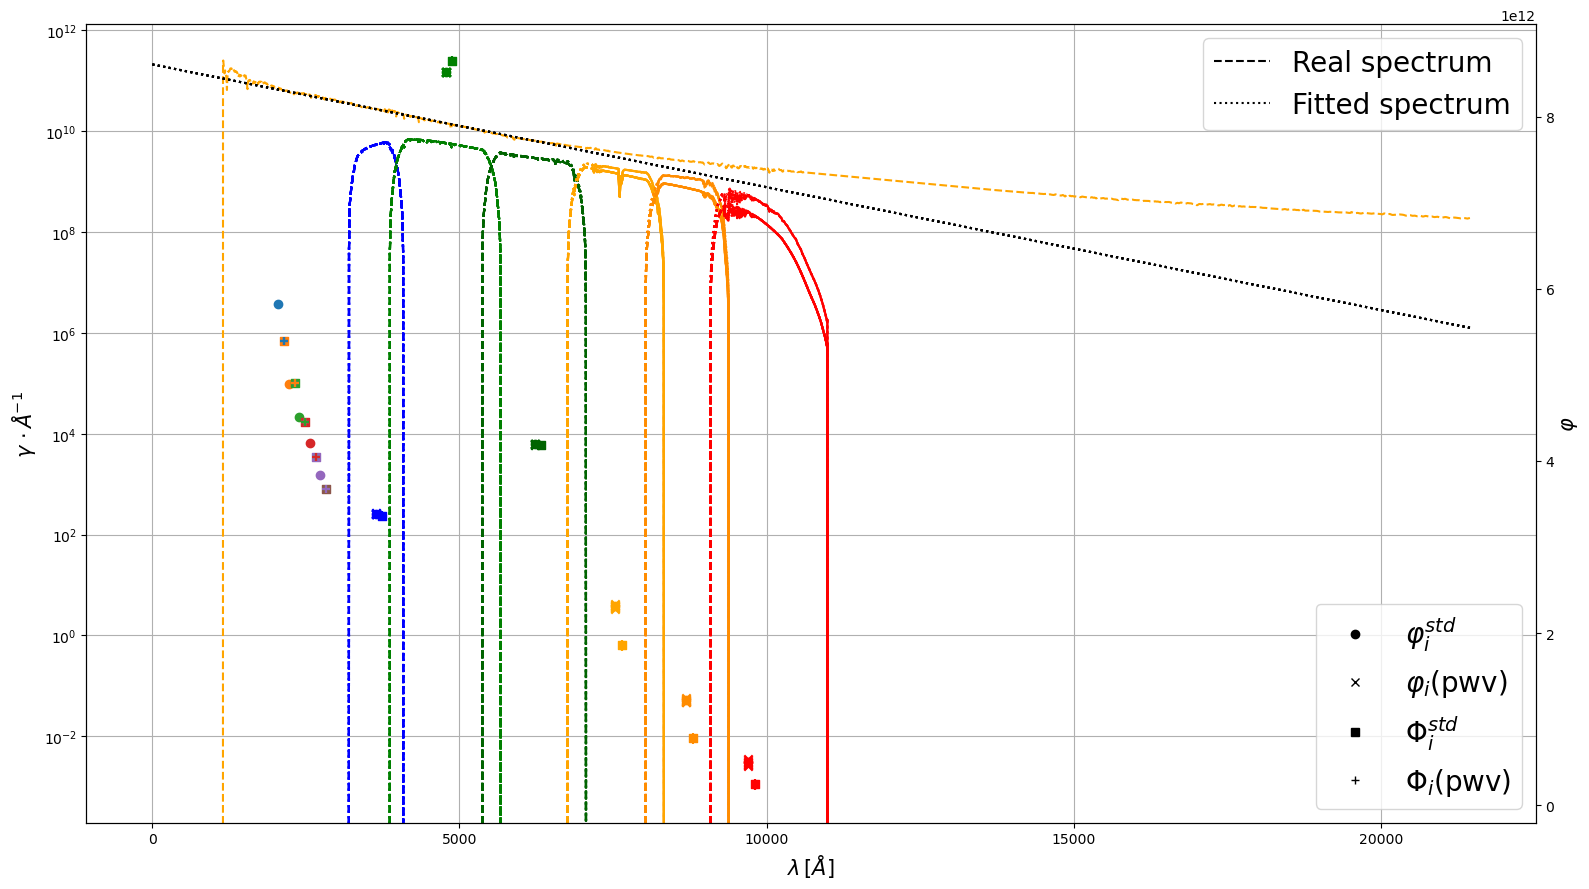

In [191]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,example_spec.flux*Seff*exptime,ls='--',color='orange',alpha=1.0)
ax1.plot(guess_dict_b[example_id]['std'].wave,guess_dict_b[example_id]['std'].flux*Seff*exptime,ls=':',color='k',alpha=1.0)
for isim in range(n_sim):
    ax1.plot(guess_dict_b[example_id]['std'].wave,guess_dict_b[example_id][isim].flux*Seff*exptime,ls=':',color='k',alpha=0.5)

ax2 = ax1.twinx()
    
#ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_xlim(10000,12000)
#ax1.set_ylim(1.387e10,1.389e10)
#ax2.set_ylim(0,7.5e12)
ax1.plot([],[],ls='--',color='k',label='Real spectrum')
ax1.plot([],[],ls=':',color='k',label='Fitted spectrum')
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()

for index,filter_ in enumerate(filters):
    ax2.scatter(eff_lambda[filter_],phi_std_dict[example_id][filter_],marker='o',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_std_dict_b[example_id][filter_][ref_ind_],marker='s',color=filter_colors[index])
    for isim in range(n_sim):
        ax1.plot(obs_flux_t_dict[example_id][filter_][isim].wave,obs_flux_t_dict[example_id][filter_][isim].flux*Seff*exptime,ls=':',color=filter_colors[index])
        ax1.plot(obs_guess_t_dict_b[example_id][filter_][isim].wave,obs_guess_t_dict_b[example_id][filter_][isim].flux*Seff*exptime,ls='--',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter_],phi_t_dict[example_id][filter_][isim],marker='x',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_t_dict_b[example_id][filter_][isim],marker='+',color=filter_colors[index])
    
for index,filter_ in enumerate(gauss_filters):
    ax2.scatter(gauss_eff_lambda[filter_],phi_gauss_dict[example_id][filter_],marker='o')
    ax2.scatter(gauss_eff_lambda[filter_]+100.,guess_Phi_gauss_dict[example_id][filter_][ref_ind_],marker='s')
    for isim in range(n_sim):
        ax2.scatter(gauss_eff_lambda[filter_]+100.,guess_Phi_gauss_dict[example_id][filter_][isim],marker='+')

ax2.plot([],[],ls='',marker='o',color='k',label=r'$\varphi^{std}_i$')
ax2.plot([],[],ls='',marker='x',color='k',label=r'$\varphi_i($'+'{0})'.format(variable_param))
ax2.plot([],[],ls='',marker='s',color='k',label=r'$\Phi^{std}_i$')
ax2.plot([],[],ls='',marker='+',color='k',label=r'$\Phi_i($'+'{0})'.format(variable_param))
#ax1.set_xlim(0.,5000.)
#ax1.set_ylim(0.,0.6e11)
ax1.set_yscale("log")
#ax2.set_ylim(0.,1e13)
#ax2.set_yscale("log")
ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=20)
ax2.legend(fontsize=20,loc='lower right')
plt.tight_layout()
print(spec.fluxunits)

### Now, we compute $\hat{F}_t(\lambda)$ by solving the full system which includes estimations from Euclid and SWIFT 

## Estimation of spectra by piecewise linear fitting 

In this case, we consider the estimated spectrum to be described by a piecewise linear function of the following form: 

$$\hat{F}(\lambda) = \begin{cases} 
      \hat{F}_0(\lambda) = a_0 \lambda & \lambda < \lambda_u \\
      \hat{F}_u(\lambda) = a_u (\lambda - \lambda_u) + a_0 \lambda_u & \lambda_u \leq \lambda < \lambda_g \\
      \hat{F}_g(\lambda) = a_g (\lambda - \lambda_g) + a_0 \lambda_u + a_u (\lambda_g - \lambda_u) & \lambda_g \leq \lambda < \lambda_r \\ 
      \qquad \qquad \qquad \vdots
   \end{cases} \, . $$ 

This can be summarized as 

$$\hat{F}_R(\lambda) = a_R (\lambda - \lambda_R) + \sum_{r=0}^{R-1} a_{r} (\lambda_{r+1} - \lambda_r) = a_R (\lambda - \lambda_R) + S_{R} \, , $$ 

where $R = \{0,u,g,r,i,z,Y\}$. Each $\lambda_R$ corresponds to the effective wavelength of each filter (computed only from the telescope's throughput, i.e., without considering the effect of the atmosphere) and we note that $\lambda_0 = 0$. For $\lambda_0$ we have imposed in the equations above the contour condition of $\hat{F}(\lambda_0) = 0$. 

Following a similar reasoning to the polynomial case, for a given band $b$ we will have the integrated flux $\varphi_b$. Then, the function defined above must meet the condition 

$$\varphi_b  = \int_0^{\infty} \hat{F}(\lambda) \, T_b(\lambda) K \frac{d\lambda}{\lambda} \, .$$ 

This integral between 0 and $\infty$ can be divided in the wavelength ranges given by $R$, resulting in  

$$\varphi_b = \sum_R \int_R \hat{F}_R(\lambda) \, T_b(\lambda) K \frac{d\lambda}{\lambda} \, . $$ 

Then, for a fixed $R$, we have that each integral yields the following expression: 

$$\int_R \hat{F}_R(\lambda) \, T_b(\lambda) \, K \frac{d\lambda}{\lambda} = 
a_R \int_R (\lambda - \lambda_R) \, T_b(\lambda) \, K \frac{d\lambda}{\lambda} + S_{R} \int_R T_b(\lambda) \, K \frac{d\lambda}{\lambda} = a_R \cdot I_b^R + S_{R} \cdot Q_b^R \, . $$ 

Then, we have that the integrated flux in the band $b$ is given by 

$$\varphi_b = \sum_R ( a_R \cdot I_b^R + S_{R} \cdot Q_b^R ) \, . $$ 

We wish to obtain a system of equations to solved in a similar manner to the polynomial case. For this, the first term on the previous expression can be written in matrix form as $I \cdot \vec{a}$, where $\vec{a}$ is the $(7 \times 1)$ vector of the coefficients we want to determine and the matrix $I$ is $(6 \times 7)$. This way, each $\varphi_b$ is $(1 \times 1)$, as expected. Now, we need to rewrite the second term to factor $a_R$ as well. Using matrix notation, the matrix $Q$ is also $(6 \times 7)$, so in order to have the correct dimensions, we need the object this matrix acts on to be $(7 \times 1)$. Looking at the expanded expression of $S_{R}$, we have 

$$S_{R} = \sum_{r=0}^{R-1} a_{r} (\lambda_{r+1} - \lambda_r) \, , $$ 

which we note that does not depend on the band $b$, only on $R$. This means that this quantity is the same for all bands. Also, given that it appears together with the matrix $Q$, multiplying each element $R$ of a fixed row $b$, then we can reinterpret it as $(7 \times 1)$ vector of the form 

$$\vec{k} = \begin{bmatrix} 0 \\ a_0 \cdot \lambda_u \\ a_0 \cdot \lambda_u + a_u \cdot (\lambda_g - \lambda_u) \\ \vdots \end{bmatrix} \, , $$

where the first component is 0 corresponding to $R=0$ (note that $S_{R}$ only runs from 0 to $R-1$ for each $R$). Finally, in order to isolate the $a_R$ coefficients, we can further decompose the vector $\vec{k}$ as the product of a $(7 \times 7)$ matrix by $\vec{a}$, that is, 

$$\vec{k} = \begin{bmatrix} 0 & 0 & 0 & \cdots & 0 \\ \lambda_u & 0 & 0 & \cdots & 0 \\ \lambda_u & \lambda_g-\lambda_u & 0 & \cdots & 0 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ \lambda_u & \lambda_g-\lambda_u & \lambda_r-\lambda_g & \cdots & 0
\end{bmatrix} \begin{bmatrix} a_0 \\ a_u \\ \vdots \\ a_Y \end{bmatrix} = \mathcal{R} \vec{a} \, . $$

The matrix $\mathcal{R}$ contains the information of the wavelength ranges we consider for our piecewise linear function $\hat{F}(\lambda)$. Its diagonal is formed by zeros and it can be expressed as the Hadamard product of a $(7 \times 7)$ lower triangular matrix of ones by the $(7 \times 7)$ matrix $\Lambda$ whose rows correspond to the wavelength difference for each range $R$, this is 

$$ \mathcal{R} = L_I \odot \Lambda = \begin{bmatrix} 0 & 0 & 0 & \cdots & 0 \\ 1 & 0 & 0 & \cdots & 0 \\ 1 & 1 & 0 & \cdots & 0 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & 1 & 1 & \cdots & 0 \end{bmatrix} \odot \begin{bmatrix} \lambda_u & \lambda_g-\lambda_u & \lambda_r-\lambda_g & \cdots & \lambda_Y-\lambda_z \\ \lambda_u & \lambda_g-\lambda_u & \lambda_r-\lambda_g & \cdots & \lambda_Y-\lambda_z \\ \lambda_u & \lambda_g-\lambda_u & \lambda_r-\lambda_g & \cdots & \lambda_Y-\lambda_z \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ \lambda_u & \lambda_g-\lambda_u & \lambda_r-\lambda_g & \cdots & \lambda_Y-\lambda_z \end{bmatrix} \, . $$ 

Writing all together, we have that 

$$\vec{\varphi} = ( I + Q \mathcal{R} ) \vec{a} = \tilde{M}_{\phi} \vec{a} \, . $$ 

However, we note that the matrix $\tilde{M}_{\phi}$ is $(6 \times 7)$, so it is not invertible. Nevertheless, we need to impose one last contour condition for $\lambda \to \infty$. We define $\lambda_{\infty}$ as a very high wavelength at which we impose the last piece of the piecewise $\hat{F}(\lambda)$ function to be 0, that is, $\hat{F}_Y(\lambda_{\infty}) = 0$, which means 

$$ a_Y \cdot (\lambda_{\infty}-\lambda_Y) + \sum_{R^{\prime}=0}^z a_{R^{\prime}} \cdot (\lambda_{R^{\prime}+1}-\lambda_{R^{\prime}}) = \sum_{R^{\prime}} a_{R^{\prime}} \cdot (\lambda_{R^{\prime}+1}-\lambda_{R^{\prime}}) = 0 \, $$

where $\lambda_{Y+1} = \lambda_{\infty}$. This is again the product of a $(1 \times 7)$ vector, $\vec{\Delta \lambda}$, with $\vec{a}$. This product provides the last equation needed, so we can expand $\tilde{M}_{\phi}$ to 

$$ M_{\phi} = \begin{bmatrix} \tilde{M}_{\phi} \\ --- \\ \vec{\Delta \lambda} \end{bmatrix} \, , $$

and $\vec{\varphi}$ to 

$$ \vec{v} = \begin{bmatrix} \vec{\varphi} \\ --- \\ 0 \end{bmatrix} \, . $$ 

This way, we have 

$$\vec{v} = M_{\phi} \vec{a} \, , $$

where $\vec{v}$ is $(7 \times 1)$ by the addition of the zero coming from the last condition and $M_{\phi}$ is $(7 \times 7)$, which means it is invertible. By inverting it, we can obtain the values of the coefficients $a_R$ for each linear sub-function of $\hat{F}(\lambda)$.

### We define all necessary elements to obtain the matrix $M_{\phi}$ 

We start with the standard atmosphere case and once it is tested, we run it for all atmospheres 

In [192]:
use_delta_wl = False
use_euclid = True
use_swift = True
use_gauss = False
eu_use = ['Ye','Je']
lsst_use = filters
swift_use = ['UVM2']
gauss_use = gauss_filters
#swift_use = swift_filters
if use_euclid==False:
    eu_use = []
if use_swift==False:
    swift_use = []
if use_gauss==False:
    gauss_use = []

Store the overlap wavelengths on a vector 

In [193]:
pivot_wls = [0.]
#pivot_wls = [1518.53020505]

for filter_ in swift_use:
    pivot_wls.append(over_lambda[filter_])

for filter_ in lsst_use:
    pivot_wls.append(over_lambda[filter_])

for filter_ in eu_use:
    pivot_wls.append(over_lambda[filter_])

pivot_wls = np.array(pivot_wls)
pivot_wls

array([    0.        ,  2360.69817697,  3977.0063598 ,  5520.33355025,
        6909.85225499,  8180.04948103,  9230.42869747,  9881.16857072,
       11902.63686293, 15441.64129508])

In [194]:
over_lambda

{'UVW2': 2161.465483268082,
 'UVM2': 2360.6981769690046,
 'UVW1': 3549.013668763476,
 'u': 3977.0063597990943,
 'g': 5520.333550251726,
 'r': 6909.852254990963,
 'i': 8180.049481029574,
 'z': 9230.428697471196,
 'Y': 9881.168570719628,
 'Ye': 11902.636862925166,
 'Je': 15441.641295084075}

Set the final filters that we are going to use 

In [195]:
#X = filters
X = swift_use+gauss_use+lsst_use+eu_use
X,len(X)

(['UVM2', 'u', 'g', 'r', 'i', 'z', 'Y', 'Ye', 'Je'], 9)

Define the wavelength ranges 

In [196]:
r = X

ranges = {}
for i in range(len(r)):
    ranges[X[i]] = [pivot_wls[i],pivot_wls[i+1]]
Nr = len(ranges.keys())
ranges,Nr,over_lambda

({'UVM2': [0.0, 2360.6981769690046],
  'u': [2360.6981769690046, 3977.0063597990943],
  'g': [3977.0063597990943, 5520.333550251726],
  'r': [5520.333550251726, 6909.852254990963],
  'i': [6909.852254990963, 8180.049481029574],
  'z': [8180.049481029574, 9230.428697471196],
  'Y': [9230.428697471196, 9881.168570719628],
  'Ye': [9881.168570719628, 11902.636862925166],
  'Je': [11902.636862925166, 15441.641295084075]},
 9,
 {'UVW2': 2161.465483268082,
  'UVM2': 2360.6981769690046,
  'UVW1': 3549.013668763476,
  'u': 3977.0063597990943,
  'g': 5520.333550251726,
  'r': 6909.852254990963,
  'i': 8180.049481029574,
  'z': 9230.428697471196,
  'Y': 9881.168570719628,
  'Ye': 11902.636862925166,
  'Je': 15441.641295084075})

In [197]:
r,Nr

(['UVM2', 'u', 'g', 'r', 'i', 'z', 'Y', 'Ye', 'Je'], 9)

Define the functions to compute $I$ and $Q$ 

In [198]:
def I_xr(wavelength,wl_range,pb_x):
    
    eff_wl_1 = wl_range[0]
    eff_wl_2 = wl_range[1]
    wl_mask = (wavelength>=eff_wl_1)*(wavelength<eff_wl_2)
    wls_ = wavelength[wl_mask]
    T_x = pb_x.throughput[wl_mask]
    assert len(wls_)==len(T_x)
    
    I_xr = np.trapz((wls_-eff_wl_1)*T_x*K,x=wls_)
    
    return I_xr

In [199]:
def Q_xr(wavelength,wl_range,pb_x):
    
    eff_wl_1 = wl_range[0]
    eff_wl_2 = wl_range[1]
    wl_mask = (wavelength>=eff_wl_1)*(wavelength<eff_wl_2)
    wls_ = wavelength[wl_mask]
    #print(len(wls_),eff_wl_1,eff_wl_2)
    T_x = pb_x.throughput[wl_mask]
    assert len(wls_)==len(T_x)
    
    Q_xr = np.trapz(T_x*K,x=wls_)
    
    return Q_xr

Define the auxiliary matrix $L_I$ 

In [200]:
L_i = np.zeros((Nr,Nr))
for i in range(Nr):
    for j in range(Nr):
        if j<i:
            L_i[i,j] = 1.
L_i,L_i.shape

(array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 0.]]),
 (9, 9))

Define auxiliary vector with $\Delta \lambda$'s up to last selected band  

In [201]:
Delta_r = np.diff(pivot_wls[:-1])
Delta_r,len(Delta_r)

(array([2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
        1270.19722604, 1050.37921644,  650.73987325, 2021.46829221]),
 8)

In [202]:
pivot_wls

array([    0.        ,  2360.69817697,  3977.0063598 ,  5520.33355025,
        6909.85225499,  8180.04948103,  9230.42869747,  9881.16857072,
       11902.63686293, 15441.64129508])

And define auxiliary matrix $\Lambda$ 

In [203]:
Lambda = np.zeros((Nr,Nr))
for i in range(Nr-1):
    Lambda[i+1,:-1] = Delta_r
Lambda,Lambda.shape

(array([[   0.        ,    0.        ,    0.        ,    0.        ,
            0.        ,    0.        ,    0.        ,    0.        ,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
         1270.19722604, 1050.37921644,  650.73987325, 2021.46829221,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
         1270.19722604, 1050.37921644,  650.73987325, 2021.46829221,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
         1270.19722604, 1050.37921644,  650.73987325, 2021.46829221,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
         1270.19722604, 1050.37921644,  650.73987325, 2021.46829221,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
         1270.19722604, 1050.37921644,  650.73987325, 2021.46829221,
            0.        ],
        [2360.69817697

Compute matrix $\mathcal{R}$ 

In [204]:
R = L_i*Lambda
R,R.shape

(array([[   0.        ,    0.        ,    0.        ,    0.        ,
            0.        ,    0.        ,    0.        ,    0.        ,
            0.        ],
        [2360.69817697,    0.        ,    0.        ,    0.        ,
            0.        ,    0.        ,    0.        ,    0.        ,
            0.        ],
        [2360.69817697, 1616.30818283,    0.        ,    0.        ,
            0.        ,    0.        ,    0.        ,    0.        ,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045,    0.        ,
            0.        ,    0.        ,    0.        ,    0.        ,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
            0.        ,    0.        ,    0.        ,    0.        ,
            0.        ],
        [2360.69817697, 1616.30818283, 1543.32719045, 1389.51870474,
         1270.19722604,    0.        ,    0.        ,    0.        ,
            0.        ],
        [2360.69817697

In [205]:
lsst_use

['u', 'g', 'r', 'i', 'z', 'Y']

Compute matrices $I$ and $Q$ 

In [206]:
I = np.zeros((len(X),Nr))

In [207]:
for i,filter_ in enumerate(X):
    if filter_ in swift_filters:
        bp_ = swift_bp[i]
    elif filter_ in gauss_filters:
        print('gauss')
        i_ = i-len(swift_use)
        bp_ = gauss_bp[i_]
    elif filter_ in filters:
        bp_ = total_passband_ref[filter_]
    elif filter_ in eu_filters:
        i_ = i-len(swift_use)-len(gauss_use)-len(lsst_use)
        bp_ = euclid_bp[i_]
    for j in range(Nr):
        I_ij = I_xr(wl_baseline,ranges[r[j]],bp_)
        I[i,j] = I_ij

In [208]:
I,I.shape

(array([[4.82826066e+12, 1.26809854e+11, 1.21719640e+09, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 1.49620907e+12, 1.39877922e+09, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 7.22799313e+10, 4.46943930e+12, 5.89986071e+09,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 2.01464178e+11, 4.15804807e+12,
         6.87054054e+09, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.89312296e+11,
         3.44046160e+12, 6.52156437e+09, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         1.76443464e+11, 2.23903844e+12, 5.18524943e+09, 0.00000000

In [209]:
Q = np.zeros((len(X),Nr))

In [210]:
for i,filter_ in enumerate(X):
    if filter_ in swift_filters:
        bp_ = swift_bp[i]
    elif filter_ in gauss_filters:
        print('gauss')
        i_ = i-len(swift_use)
        bp_ = gauss_bp[i_]
    elif filter_ in filters:
        bp_ = total_passband_ref[filter_]
    elif filter_ in eu_filters:
        i_ = i-len(swift_use)-len(gauss_use)-len(lsst_use)
        print(i_)
        bp_ = euclid_bp[i_]
    for j in range(Nr):
        Q_ij = Q_xr(wl_baseline,ranges[r[j]],bp_)
        Q[i,j] = Q_ij
    #print('---------')

0
1


In [211]:
Q,Q.shape

(array([[2.48611459e+09, 3.84577612e+08, 7.70795464e+06, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 1.15441002e+09, 4.18809529e+07, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 4.56471558e+07, 5.50046808e+09, 1.30190785e+08,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.34469845e+08, 5.85600317e+09,
         1.51942208e+08, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.40942482e+08,
         5.44867952e+09, 1.42661609e+08, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         1.44080340e+08, 4.34817070e+09, 1.21925263e+08, 0.00000000

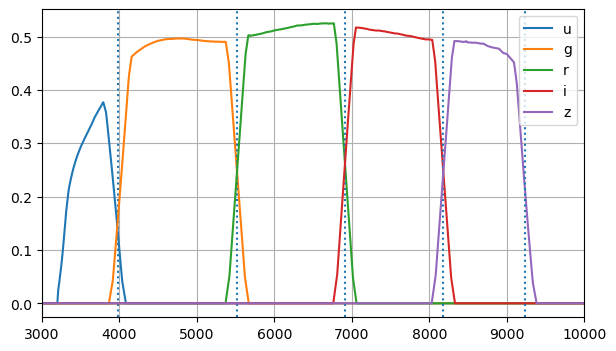

In [212]:
fig = plt.figure(figsize=(7,4))
ax = fig.add_subplot(111)

for i in range(len(filters)-1):
    ax.plot(lsst_bp[i].wave,lsst_bp[i].throughput,label=filters[i])
    ax.axvline(x=over_lambda[filters[i]],ls=':',alpha=1.0)

ax.set_xlim(3000.,10000.)
ax.grid()
ax.legend(loc="best")

Compute $M_{\phi}$ 

In [213]:
M = I + Q@R

In [214]:
M,M.shape

(array([[5.75432848e+12, 1.39268284e+11, 1.21719640e+09, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [2.82408191e+12, 1.56390160e+12, 1.39877922e+09, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [1.34000453e+13, 9.17315994e+12, 4.67036628e+12, 5.89986071e+09,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [1.45003884e+13, 9.92803599e+12, 9.47368964e+12, 4.36917461e+12,
         6.87054054e+09, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [1.35321915e+13, 9.26513690e+12, 8.84678916e+12, 7.95858538e+12,
         3.62166997e+12, 6.52156437e+09, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [1.08926776e+13, 7.45793092e+12, 7.12118376e+12, 6.41148429e+12,
         5.85434696e+12, 2.36710621e+12, 5.18524943e+09, 0.00000000

In [215]:
Nr

9

In [216]:
#M_inv = np.linalg.inv(M)
M_inv = np.linalg.inv(M)
M_inv.shape

(9, 9)

Define vector $\vec{\varphi}$ and the vector of errors 

In [217]:
phi_vec = []
phi_err = []
for filter_ in swift_use:
    #v_vec.append(phi_swift_dict[example_id][filter_])
    phi_vec.append(guess_Phi_swift_dict[example_id][filter_][ref_ind_])
    phi_err.append(guess_Phi_err_swift_dict[example_id][filter_][ref_ind_])
for filter_ in gauss_use:
    #v_vec.append(phi_gauss_dict[example_id][filter_])
    phi_vec.append(guess_Phi_gauss_dict[example_id][filter_][ref_ind_])
for filter_ in lsst_use:
    phi_vec.append(phi_std_dict[example_id][filter_])
    phi_err.append(phi_err_std_dict[example_id][filter_])
for filter_ in eu_use:
    #v_vec.append(phi_eu_dict[example_id][filter_])
    phi_vec.append(guess_Phi_eu_dict[example_id][filter_][ref_ind_])
    phi_err.append(guess_Phi_err_eu_dict[example_id][filter_][ref_ind_])
phi_vec = np.array(phi_vec)
phi_err = np.array(phi_err)

In [218]:
phi_std_dict

{'pickles_uk_2': {'u': 3381449901969.128,
  'g': 8515575229917.531,
  'r': 4197926347762.8994,
  'i': 2319596167160.398,
  'z': 1227206732720.127,
  'Y': 506609824276.50433}}

In [219]:
phi_vec,phi_err

(array([1.15820140e+13, 3.38144990e+12, 8.51557523e+12, 4.19792635e+12,
        2.31959617e+12, 1.22720673e+12, 5.06609824e+11, 2.87891625e+12,
        1.97282638e+12]),
 array([1821589.26551941,  765415.20555969, 1761953.29902659,
        1332794.13619237, 1006040.260234  ,  717770.3582649 ,
         333614.41966644, 1481529.35442676, 1241392.78151394]))

In [220]:
lambda_lims = np.array(list(pivot_wls[:-1])+[np.inf])
lambda_lims

array([    0.        ,  2360.69817697,  3977.0063598 ,  5520.33355025,
        6909.85225499,  8180.04948103,  9230.42869747,  9881.16857072,
       11902.63686293,            inf])

### Compute coefficients 

In [221]:
a_vec = np.matmul(M_inv,phi_vec)
a_vec,a_vec.shape

(array([ 2.05021842, -1.53915431, -1.03588221, -0.09940936, -0.33394457,
         0.14562214, -0.35902685,  0.02670127, -0.05791461]),
 (9,))

### Define piecewise linear function 

In [222]:
def piecewise_spec(wl, wl_lims, params, output_funits='photlam'):
    
    conditions = []
    for i in range(1,len(wl_lims)):
        condi_ = (wl>=wl_lims[i-1])&(wl<wl_lims[i])
            
        conditions.append(condi_)
    
    
    def func_(i,params,wl_lims):
        param_ = params[i]
        params_aux = np.array([0.]+list(params))
        #print(params)
        #print(params_aux)
        
        wl_ = wl_lims[i]
            
        Sr = 0.
        for j in range(i):
            #Sr = Sr+params[j]*(wl_lims[j+1]-wl_lims[j])
            Sr = Sr+params_aux[j+1]*(wl_lims[j+1]-wl_lims[j])
        
        return lambda x: param_*(x-wl_)+Sr
    
    functions = []
    for i in range(len(params)):
        functions.append(func_(i,params,wl_lims))
    
    spec_ = np.piecewise(wl, conditions, functions)
    
    if output_funits=='fnu':
        A = h_planck*l
    elif output_funits=='flam':
        A = l**2./c_light
    elif output_funits=='photlam':
        A = 1.
    else:
        A = 1.
    spec_ = A*spec_
    
    return spec_


In [223]:
piecewise_spec(wl_baseline,lambda_lims,a_vec)

array([   2.05021842,    4.10043685,    6.15065527, ..., -388.26956973,
       -388.32748435, -388.38539896])

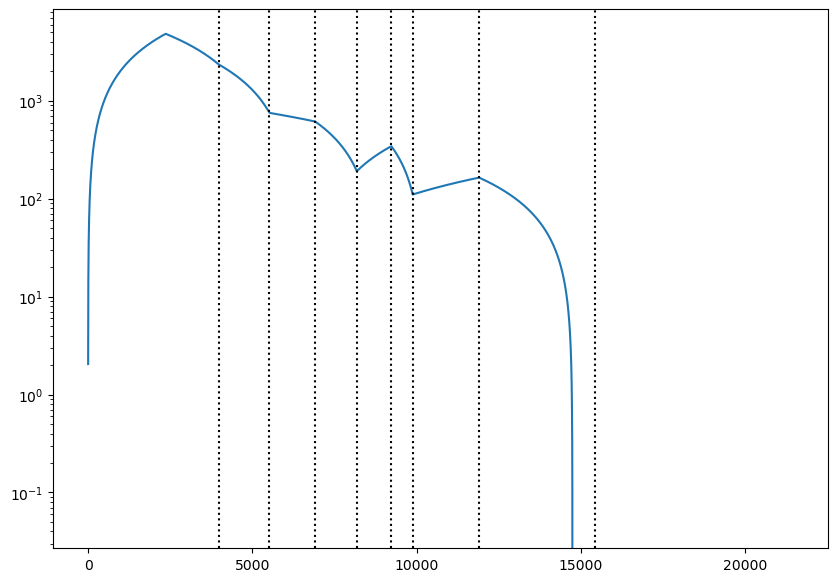

In [224]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111)
ax.plot(wl_baseline,piecewise_spec(wl_baseline,lambda_lims,a_vec))
ax.set_yscale("log")

for index,filter_ in enumerate(filters):
    ax.axvline(x=over_lambda[filter_],ls=':',color='k')
    
for index,filter_ in enumerate(eu_use):
    ax.axvline(x=over_lambda[filter_],ls=':',color='k')

(0.0, 1.0)

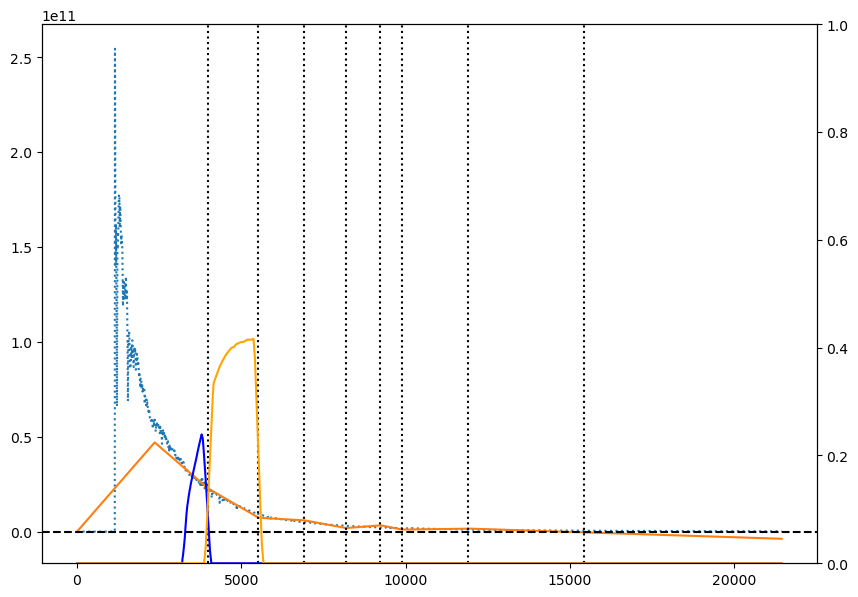

In [225]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111)
ax.plot(example_spec.wave,example_spec.flux*Seff*exptime,ls=':')
ax.plot(wl_baseline,piecewise_spec(wl_baseline,lambda_lims,a_vec)*Seff*exptime)

#ax.axvline(x=swift_eff_lambda['UVW1'],ls='--',color='b')
#for filter_ in gauss_filters:
#    plt.axvline(x=gauss_eff_lambda[filter_],ls='--',color='grey')
ax.axhline(y=0.,ls='--',color='k')
#ax.set_ylim(-0.05e10,6e10)
#ax.set_yscale("log")
#ax.set_xlim(0.,4000.)

for index,filter_ in enumerate(filters):
    ax.axvline(x=over_lambda[filter_],ls=':',color='k')
    
for index,filter_ in enumerate(eu_use):
    ax.axvline(x=over_lambda[filter_],ls=':',color='k')

ax2 = ax.twinx()
ax2.plot(wl_baseline,total_passband_ref['u'].throughput,color='b')
ax2.plot(wl_baseline,total_passband_ref['g'].throughput,color='orange')
ax2.set_ylim(0.,1.)

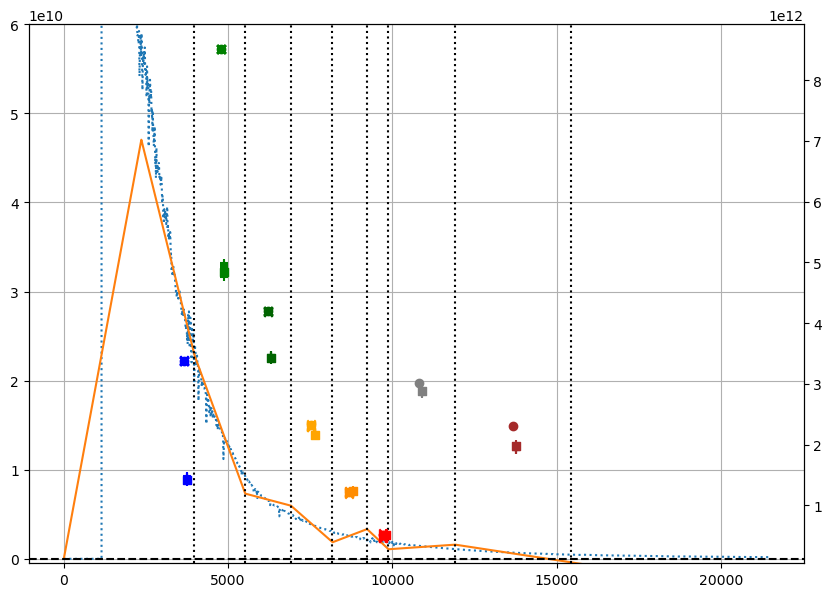

In [226]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111)
ax.plot(example_spec.wave,example_spec.flux*Seff*exptime,ls=':')
ax.plot(wl_baseline,piecewise_spec(wl_baseline,lambda_lims,a_vec)*Seff*exptime)

ax.axhline(y=0.,ls='--',color='k')
ax.set_ylim(-0.05e10,6e10)
#ax.set_yscale("log")
#ax.set_xlim(0.,4000.)
ax.grid()

ax2 = ax.twinx()

for index,filter_ in enumerate(filters):
    ax2.scatter(eff_lambda[filter_],phi_std_dict[example_id][filter_],marker='o',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_std_dict_r[example_id][filter_][ref_ind_],marker='s',color=filter_colors[index])
    for isim in range(n_sim):
        ax2.scatter(eff_lambda[filter_],phi_t_dict[example_id][filter_][isim],marker='x',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter_]+100.,guess_Phi_t_dict_r[example_id][filter_][isim],marker='+',color=filter_colors[index])
    ax.axvline(x=over_lambda[filter_],ls=':',color='k')
    
for index,filter_ in enumerate(eu_use):
    ax2.scatter(eu_eff_lambda[filter_],phi_eu_dict[example_id][filter_],marker='o',color=eu_colors[filter_])
    ax2.scatter(eu_eff_lambda[filter_]+100.,guess_Phi_eu_dict[example_id][filter_][ref_ind_],marker='s',color=eu_colors[filter_])
    for isim in range(n_sim):
        ax2.scatter(eu_eff_lambda[filter_]+100.,guess_Phi_eu_dict[example_id][filter_][isim],marker='+',color=eu_colors[filter_])
    ax.axvline(x=over_lambda[filter_],ls=':',color='k')


In [227]:
piecewise_spec(0.,lambda_lims,a_vec)

0.0

#### Test with one spectrum 

In [228]:
piecewise_spec_test_ = piecewise_spec(wl_baseline,lambda_lims,a_vec)
piecewise_spec_test0 = S.ArraySpectrum(wl_baseline,piecewise_spec_test_)
piecewise_spec_test0.fluxunits

Warning, 6707 of 21449 bins contained negative fluxes; they have been set to zero.


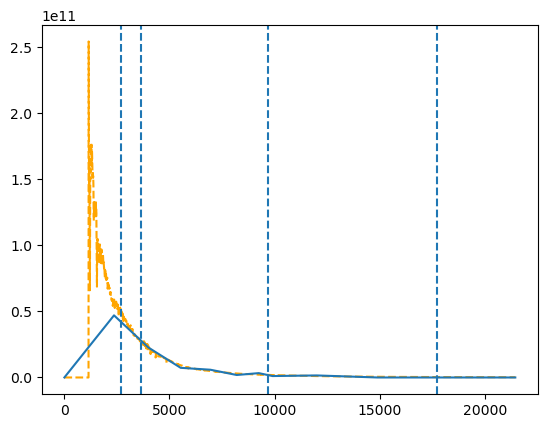

In [229]:
plt.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls='--',color='orange')
plt.plot(piecewise_spec_test0.wave,piecewise_spec_test0.flux*Seff*exptime)
plt.axvline(x=swift_eff_lambda['UVW1'],ls='--')
plt.axvline(x=eff_lambda['u'],ls='--')
plt.axvline(x=eff_lambda['Y'],ls='--')
plt.axvline(x=eu_eff_lambda['He'],ls='--')
#plt.xlim(WLMIN-500.,WLMAX+500.)

<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/144580318.py:10: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/144580318.py:11: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


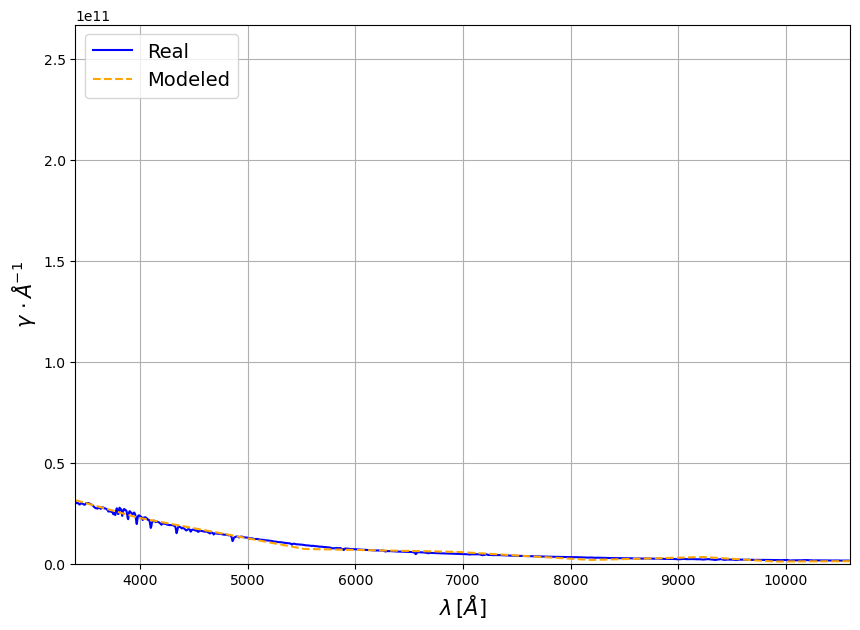

In [230]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111)
ax.plot(example_spec.wave,example_spec.flux*Seff*exptime,ls='-',color='b',label='Real')
ax.plot(wl_baseline,piecewise_spec_test_*Seff*exptime,ls='--',color='orange',label='Modeled')
#ax.axvline(x=WLMIN,ls=':',color='k')
#ax.axvline(x=WLMAX,ls=':',color='k')
ax.set_xlim(WLMIN,WLMAX)
ax.set_ylim(0.,)
ax.grid()
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.legend(loc="upper left",fontsize=14)


(0.0, 1.0)

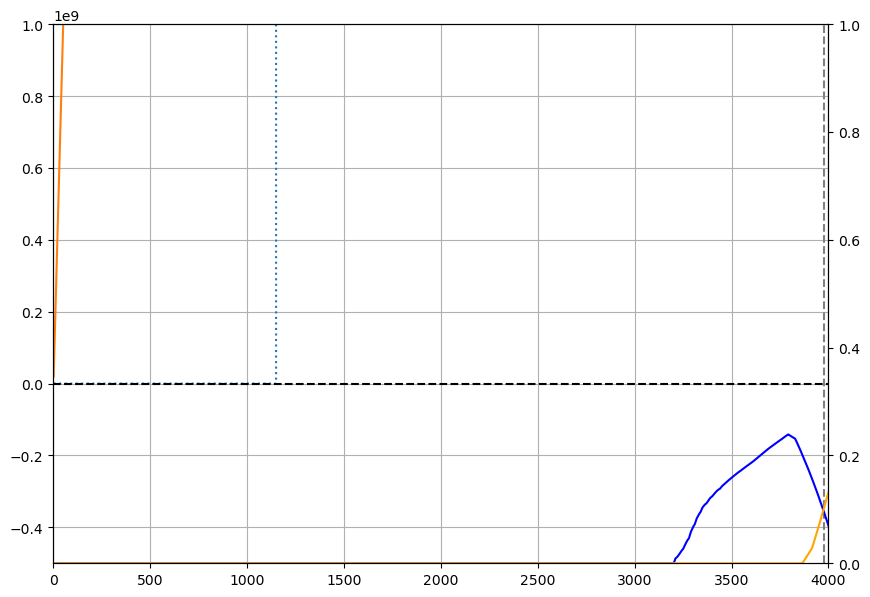

In [231]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111)
ax.plot(example_spec.wave,example_spec.flux*Seff*exptime,ls=':')
ax.plot(wl_baseline,piecewise_spec(wl_baseline,lambda_lims,a_vec)*Seff*exptime)
for filter_ in lsst_use:
    ax.axvline(x=over_lambda[filter_],ls='--',color='grey')
for filter_ in eu_use:
    ax.axvline(x=over_lambda[filter_],ls='--',color='grey')
ax.axhline(y=0.,ls='--',color='k')
ax.set_ylim(-0.05e10,0.1e10)
#plt.yscale("log")
ax.set_xlim(0.,4000.)
ax.grid()

ax2 = ax.twinx()
ax2.plot(wl_baseline,total_passband_ref['u'].throughput,color='b')
ax2.plot(wl_baseline,total_passband_ref['g'].throughput,color='orange')
ax2.set_ylim(0.,1.)

# Compute the matrices for all atmospheres 

In our formalism, only $I$ and $Q$ depend on the atmospheric transparency, while $\mathcal{R}$ depends only on the wavelength ranges that we defined for $\hat{F}(\lambda)$. 


In [232]:
I_std = np.zeros((len(X),Nr))

for i,filter_ in enumerate(X):
    if filter_ in swift_filters:
        bp_ = swift_bp[i]
        #wl_ = wl_baseline
    elif filter_ in gauss_filters:
            print('gauss')
            i_ = i-len(swift_use)
            bp_ = gauss_bp[i_]
    elif filter_ in filters:
        bp_ = total_passband_ref[filter_]
        #wl_ = wl
    elif filter_ in eu_filters:
        i_ = i-len(swift_use)-len(gauss_use)-len(lsst_use)
        bp_ = euclid_bp[i_]
        #wl_ = wl_baseline
    for j in range(Nr):
        #I_ij = I_xr(wl,ranges[r[j]],total_passband_ref[filter_])
        I_ij = I_xr(wl_baseline,ranges[r[j]],bp_)
        I_std[i,j] = I_ij

In [233]:
I_std.shape

(9, 9)

In [234]:
I_t_dict = {}

for isim in range(n_sim):
    I_t_ = np.zeros((len(X),Nr))
    for i,filter_ in enumerate(X):
        if filter_ in swift_filters:
            bp_ = swift_bp[i]
            #wl_ = wl_baseline
        elif filter_ in gauss_filters:
            print('gauss')
            i_ = i-len(swift_use)
            bp_ = gauss_bp[i_]
        elif filter_ in filters:
            bp_ = total_passband[filter_][isim]
            #wl_ = wl
        elif filter_ in eu_filters:
            i_ = i-len(swift_use)-len(gauss_use)-len(lsst_use)
            bp_ = euclid_bp[i_]
            #wl_ = wl_baseline
        for j in range(Nr):
            #I_ij = I_xr(wl,ranges[r[j]],total_passband_ref[filter_])
            I_ij = I_xr(wl_baseline,ranges[r[j]],bp_)
            I_t_[i,j] = I_ij
        I_t_dict[isim] = I_t_

In [235]:
Q_std = np.zeros((len(X),Nr))

for i,filter_ in enumerate(X):
    if filter_ in swift_filters:
        bp_ = swift_bp[i]
        #wl_ = wl_baseline
    elif filter_ in gauss_filters:
        print('gauss')
        i_ = i-len(swift_use)
        bp_ = gauss_bp[i_]
    elif filter_ in filters:
        bp_ = total_passband_ref[filter_]
        #wl_ = wl
    elif filter_ in eu_filters:
        i_ = i-len(swift_use)-len(gauss_use)-len(lsst_use)
        bp_ = euclid_bp[i_]
        #wl_ = wl_baseline
    for j in range(Nr):
        #print(filter_,r[j])
        Q_ij = Q_xr(wl_baseline,ranges[r[j]],bp_)
        Q_std[i,j] = Q_ij
    #print('---------')

In [236]:
Q_t_dict = {}

for isim in range(n_sim):
    Q_t_ = np.zeros((len(X),Nr))
    for i,filter_ in enumerate(X):
        if filter_ in swift_filters:
            bp_ = swift_bp[i]
            #wl_ = wl_baseline
        elif filter_ in gauss_filters:
            print('gauss')
            i_ = i-len(swift_use)
            bp_ = gauss_bp[i_]
        elif filter_ in filters:
            bp_ = total_passband[filter_][isim]
            #wl_ = wl
        elif filter_ in eu_filters:
            i_ = i-len(swift_use)-len(gauss_use)-len(lsst_use)
            bp_ = euclid_bp[i_]
            #wl_ = wl_baseline
        for j in range(Nr):
            #print(filter_,r[j])
            Q_ij = Q_xr(wl_baseline,ranges[r[j]],bp_)
            Q_t_[i,j] = Q_ij
        #print('---------')
    Q_t_dict[isim] = Q_t_

#### Compute $M_{\phi}^{std}$ and $M_{\phi}(t)$ matrices 

In [237]:
M_phi_std = I_std + Q_std@R
M_phi_inv_std = np.linalg.inv(M_phi_std)
M_phi_std.shape

(9, 9)

In [238]:
M_phi_t_dict = {}
M_phi_inv_t_dict = {}

for isim in range(n_sim):
    M_t_ = I_t_dict[isim]+Q_t_dict[isim]@R
    M_phi_t_dict[isim] = M_t_
    M_t_inv_ = np.linalg.inv(M_t_)
    M_phi_inv_t_dict[isim] = M_t_inv_
M_phi_t_dict[0].shape

(9, 9)

#### Set up $\vec{\varphi}^{std}$ and $\vec{\varphi}(t)$ vectors 

In [239]:
phi_vec_std_dict = {}

for spec_ in sed_dict.keys():
    phi_vec_ = []
    for filter_ in swift_use:
        #v_vec.append(phi_swift_dict[example_id][filter_])
        phi_vec_.append(guess_Phi_swift_dict[spec_][filter_][ref_ind_])
    for filter_ in gauss_use:
        #v_vec.append(phi_gauss_dict[example_id][filter_])
        phi_vec.append(guess_Phi_gauss_dict[spec_][filter_][ref_ind_])
    for filter_ in lsst_use:
        phi_vec_.append(phi_std_dict[spec_][filter_])
    for filter_ in eu_use:
        #v_vec.append(phi_eu_dict[example_id][filter_])
        phi_vec_.append(guess_Phi_eu_dict[spec_][filter_][ref_ind_])
    phi_vec_= np.array(phi_vec_)
    phi_vec_std_dict[spec_] = phi_vec_

In [240]:
phi_vec_t_dict = {}

for spec_ in sed_dict.keys():
    dict_t_ = {}
    for isim in range(n_sim):
        phi_vec_ = []
        for filter_ in swift_use:
            #phi_vec_.append(phi_swift_dict[spec_][filter_])
            phi_vec_.append(guess_Phi_swift_dict[spec_][filter_][isim])
        for filter_ in gauss_use:
            phi_vec.append(guess_Phi_gauss_dict[spec_][filter_][isim])
        for filter_ in lsst_use:
            #phi_vec_.append(phi_t_dict[spec_][filter_][isim])
            phi_vec_.append(phi_t_dict[spec_][filter_][isim])
        for filter_ in eu_use:
            #phi_vec_.append(phi_eu_dict[spec_][filter_])
            phi_vec_.append(guess_Phi_eu_dict[spec_][filter_][isim])
        phi_vec_= np.array(phi_vec_)
        dict_t_[isim] = phi_vec_
        
    phi_vec_t_dict[spec_] = dict_t_

In [241]:
phi_vec_std_dict[example_id],phi_vec

(array([1.15820140e+13, 3.38144990e+12, 8.51557523e+12, 4.19792635e+12,
        2.31959617e+12, 1.22720673e+12, 5.06609824e+11, 2.87891625e+12,
        1.97282638e+12]),
 array([1.15820140e+13, 3.38144990e+12, 8.51557523e+12, 4.19792635e+12,
        2.31959617e+12, 1.22720673e+12, 5.06609824e+11, 2.87891625e+12,
        1.97282638e+12]))

### Compute the $a_R$ coefficients for both standard and variable atmospheres for each object 

In [242]:
a_vec_std_dict = {}
a_vec_t_dict = {}

for ised in sed_dict.keys():
    
    a_vec_std_dict[ised] = np.matmul(M_phi_inv_std,phi_vec_std_dict[ised])
    
    a_vec_t_dict[ised] = []
    for isim in range(n_sim):
        a_vec_t_dict[ised].append(np.matmul(M_phi_inv_t_dict[isim],phi_vec_t_dict[ised][isim]))
    
#print(a_vec_std_dict)

In [243]:
len(a_vec_t_dict[example_id][0])

9

In [244]:
estim_spec_std_dict = {}
estim_spec_t_dict = {}

for ised in sed_dict.keys():
    estim_spec_std_dict[ised] = piecewise_spec(wl_baseline,lambda_lims,a_vec_std_dict[ised])
    
    estim_spec_t_dict[ised] = []
    for isim in range(n_sim):
        estim_spec_t_dict[ised].append(piecewise_spec(wl_baseline,lambda_lims,a_vec_t_dict[ised][isim]))

In [245]:
example_spec.fluxunits

In [246]:
estim_spec_std_dict[example_id]

array([   2.05021842,    4.10043685,    6.15065527, ..., -388.26956973,
       -388.32748435, -388.38539896])

In [247]:
estim_spec_t_dict[example_id][ref_ind_]

array([   2.05021842,    4.10043685,    6.15065527, ..., -388.26956973,
       -388.32748435, -388.38539896])

In [248]:
a_vec_std_dict[example_id],a_vec

(array([ 2.05021842, -1.53915431, -1.03588221, -0.09940936, -0.33394457,
         0.14562214, -0.35902685,  0.02670127, -0.05791461]),
 array([ 2.05021842, -1.53915431, -1.03588221, -0.09940936, -0.33394457,
         0.14562214, -0.35902685,  0.02670127, -0.05791461]))

<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/8364382.py:17: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/8364382.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


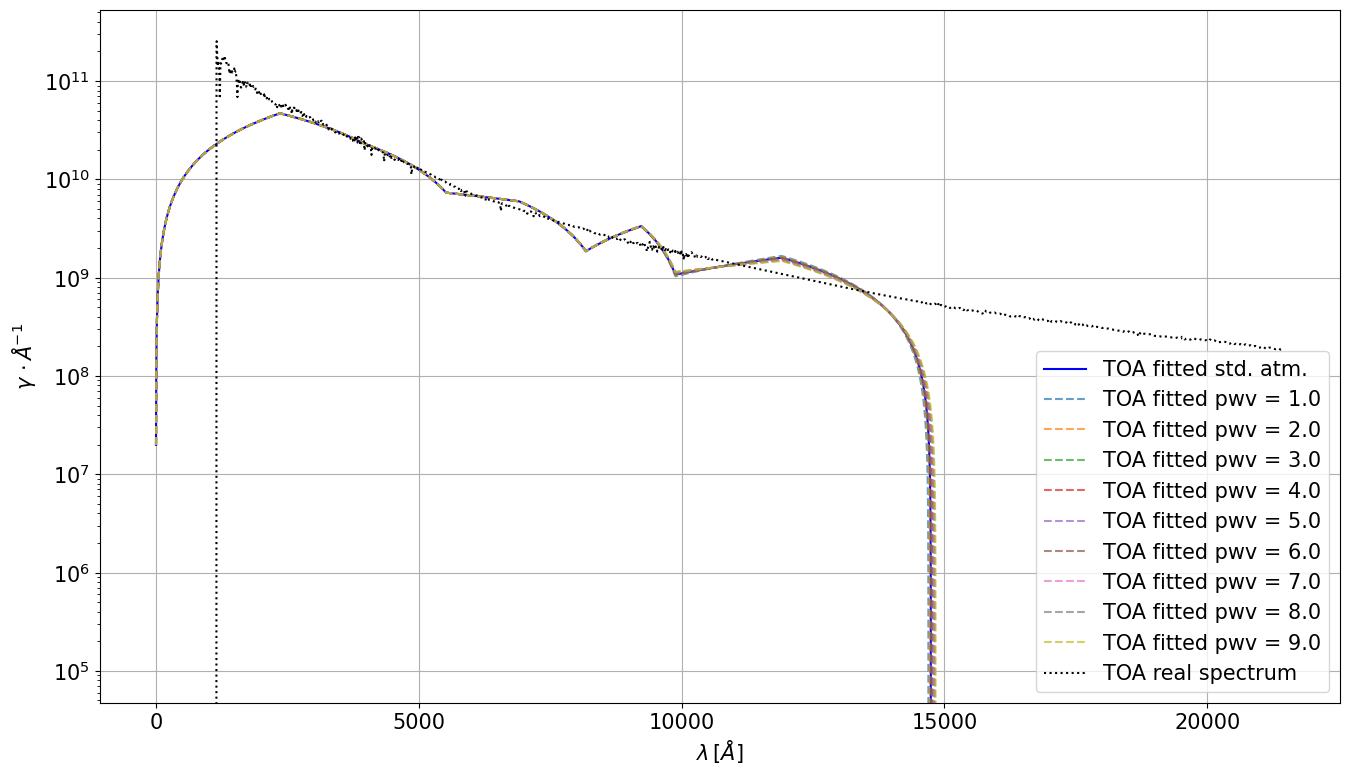

In [249]:
fig=plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)

ax.plot(wl_baseline,estim_spec_std_dict[example_id]*Seff*exptime,ls='-',color='b',label='TOA fitted std. atm.')
for isim in range(n_sim):
    ax.plot(wl_baseline,estim_spec_t_dict[example_id][isim]*Seff*exptime,ls='--',alpha=0.7,label='TOA fitted {0} = {1}'.format(variable_param,atm_vals[isim]))

ax.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls=':',color='k',label='TOA real spectrum')
#ax.plot(wl_baseline,piecewise_spec_test_*Seff*exptime,color='orange')

#ax.set_xlim(WLMIN,WLMAX)
#ax.set_xlim(9000,10500)
#ax.set_ylim(0.,3e10)
#ax.set_ylim(0,0.4e10)
ax.set_yscale("log")
ax.grid()
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)



### We make the estimated spectra pass through the different total passbands 

**NOTE:** for each object $\mu$ and for each atmospheric condition (standard and non-standard) we compute a $\hat{F}_i(\lambda)$, because this is what we will actually have at each moment. That is, $\hat{F}_i(\lambda) = \hat{F}_i(\lambda ; std)$ or $ \hat{F}_i(\lambda ; t)$. 

We pass the **estimated spectra** through the **standard atmosphere**, so we obtain what we call $\vec{\Phi}^{std}_i$. **Note that we will have one $\vec{\Phi}^{std}_i$ from each estimated $\hat{F}_i(\lambda)$, that is, for each $\vec{\varphi}_i(t)$.** 

For the two extreme cases (minimum and maximum total passbands), we pass the corresponding estimated spectra through the corresponding atmosphere, obtaining what we refer to as $\vec{\Phi}_i(t)$, that is, the **estimated spectrum** passing through the **current atmosphere**. It could also happen that the current atmosphere is equal to the standard one. In that case, $\vec{\Phi}_i(t)$ will be equal to $\vec{\Phi}^{std}_i$ and therefore the corrected flux, $\vec{\varphi}^{\, corr}_i$, will be equal to the observed one $\vec{\varphi}_i(t)$. 


### Set up the estimated spectra in pysynphot format 

In [250]:
estim_dict = {}

for ised in sed_dict.keys():
    estim_dict[ised] = {}
    estim0_ = S.ArraySpectrum(wl_baseline,estim_spec_std_dict[ised])
    estim_dict[ised]['std'] = estim0_
    
    for isim in range(n_sim):
        estim0_ = S.ArraySpectrum(wl_baseline,estim_spec_t_dict[ised][isim])
        estim_dict[ised][isim] = estim0_
        
    

Warning, 6707 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6753 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6727 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6707 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6689 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6672 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6656 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6642 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6629 of 21449 bins contained negative fluxes; they have been set to zero.
Warning, 6615 of 21449 bins contained negative fluxes; they have been set to zero.


### Compute the $\hat{F}(\lambda;t)$ through the corresponding **current atmosphere** 

**Note:** we store separately the $\hat{F}(\lambda;std)$ spectra through the standard atmosphere just for checking purposes 

In [251]:

obs_estim_std_dict = {}
obs_estim_t_dict = {}

for ised in sed_dict.keys():
    obs_estim_std_dict[ised] = {}
    obs_estim_t_dict[ised] = {}
    for filter_ in filters:
        estim_total_ = S.Observation(estim_dict[ised]['std'],total_passband_ref[filter_],force='taper')
        obs_estim_std_dict[ised][filter_] = estim_total_
        
        obs_estim_t_dict[ised][filter_] = []
        for isim in range(n_sim):
            estim_total_ = S.Observation(estim_dict[ised][isim],total_passband[filter_][isim],force='taper')
            obs_estim_t_dict[ised][filter_].append(estim_total_)
            
    

### Compute the $\hat{F}(\lambda;t)$ through the **standard atmosphere** 

In [252]:
std_estim_t_dict = {}

for ised in sed_dict.keys():
    
    std_estim_t_dict[ised] = {}
    
    for filter_ in filters:
        std_estim_t_dict[ised][filter_] = []
        for isim in range(n_sim):
            estim_cross_ = S.Observation(estim_dict[ised][isim],total_passband_ref[filter_],force='taper')
            std_estim_t_dict[ised][filter_].append(estim_cross_)
        
    

u


<>:15: SyntaxWarning: invalid escape sequence '\,'
<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\,'
<>:16: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/2341577746.py:15: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/2341577746.py:16: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


g
r
i
z
Y
photlam


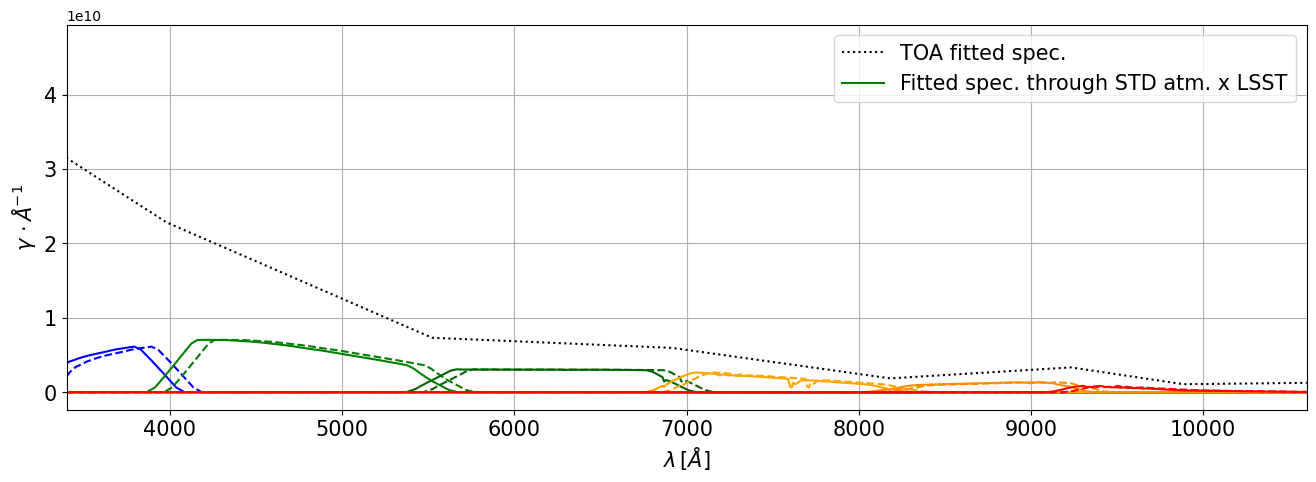

In [253]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)

ax.plot(estim_dict[example_id][ref_ind_].wave,estim_dict[example_id][ref_ind_].flux*Seff*exptime,ls=':',color='k',alpha=1.0)

for index,filter_ in enumerate(filters):
    print(filter_)
    obs = std_estim_t_dict[example_id][filter_][ref_ind_]
    ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=1.0)
    obs = obs_estim_std_dict[example_id][filter_]
    ax.plot(obs.binwave+100,obs.binflux*Seff*exptime,ls='--',color=filter_colors[index],alpha=1.0)

ax.set_xlim(WLMIN,WLMAX)
#ax.set_ylim(0.,0.5e13)
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.grid()
ax.plot([],[],ls=':',color='k',label='TOA fitted spec.')
ax.plot([],[],ls='-',color='g',label='Fitted spec. through STD atm. x LSST')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
print(spec.fluxunits)

<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:21: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/4097972199.py:21: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/4097972199.py:22: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


u
g
r
i
z
Y
photlam


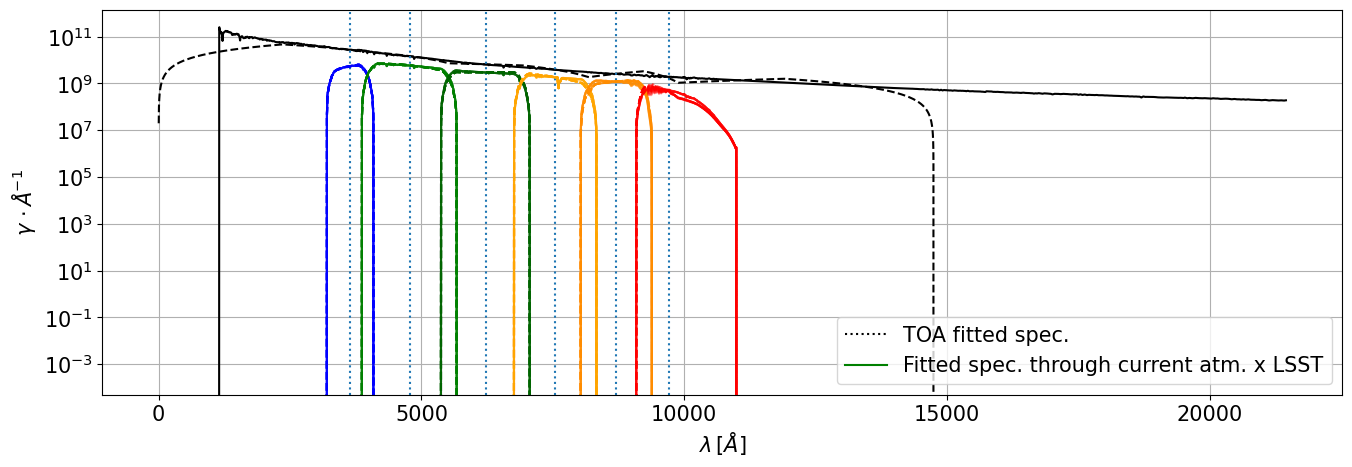

In [254]:
fig=plt.figure(figsize=(16,5))
ax = fig.add_subplot(111)

ax.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls='-',color='k')
ax.plot(estim_dict[example_id][ref_ind_].wave,estim_dict[example_id][ref_ind_].flux*Seff*exptime,ls='--',color='k',alpha=1.0)
#ax.plot(estim_atm_std.binwave,estim_atm_std.binflux*Seff*exptime,ls='--',color='cyan',alpha=1.0)

for index,filter_ in enumerate(filters):
    print(filter_)
    ax.axvline(x=eff_lambda[filter_],ls=':')
    for isim in range(n_sim):
        obs = obs_flux_t_dict[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='-',color=filter_colors[index],alpha=0.3)
        obs = obs_estim_t_dict[example_id][filter_][isim]
        ax.plot(obs.binwave,obs.binflux*Seff*exptime,ls='--',color=filter_colors[index],alpha=0.6)

#ax.set_xlim(WLMIN,WLMAX)
#ax.set_xlim(9000,11000)
#ax.set_ylim(0.,0.2e10)
ax.set_yscale("log")
ax.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax.grid()
ax.plot([],[],ls=':',color='k',label='TOA fitted spec.')
ax.plot([],[],ls='-',color='g',label='Fitted spec. through current atm. x LSST')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
print(spec.fluxunits)

## IMPORTANT NOTE: 

All the following integrated spectra correspond to $\vec{\Phi}_i(t)$, that is, to each estimated $\hat{F}_i(\lambda;t)$ passing through the atmosphere they were inferred from, i.e. the current atmosphere. **This includes the standard atmosphere case.** This is so because, as we mentioned before, one possible situation is that the current atmosphere corresponds to the standard one. WE MUST NOT interpret the following integrated fluxes as the different $\vec{\Phi}_i^{std}$ vectors, which will correspond to the different $\hat{F}_i(\lambda;t)$ passing through the standard atmosphere. 


Compute the $\vec{\Phi}_i(t)$ values. We also compute the magnitudes obtained from $\vec{\Phi}_i(t)$ as 

$$\vec{\mathbb{m}}_i(t) = -2.5 \log_{10} \frac{\vec{\Phi}_i(t)}{\Phi_{AB}} \, . $$ 

In [255]:
Phi_t_dict = {}
Mag_t_dict = {}

for ised in sed_dict.keys():
    Phi_t_dict[ised] = {}
    Mag_t_dict[ised] = {}
    for index,filter_ in enumerate(filters):
        Phi_t_dict[ised][filter_] = []
        Mag_t_dict[ised][filter_] = []
        for isim in range(n_sim):
            num_,mag_ = int_flux(estim_dict[ised][isim],total_passband[filter_][isim],return_mag=True,PhiAB=Phi_AB[index])
            Phi_t_dict[ised][filter_].append(num_)
            Mag_t_dict[ised][filter_].append(mag_)
        
    
    

Compute the $\vec{\Phi}_i^{std}$ values. Similarly, we also calculate the magnitudes obtained from $\vec{\Phi}_i^{std}$ as 

$$\vec{\mathbb{m}}_i^{std} = -2.5 \log_{10} \frac{\vec{\Phi}_i^{std}}{\Phi_{AB}} \, . $$ 

In [256]:
Phi_std_dict = {}
Mag_std_dict = {}

for ised in sed_dict.keys():
    Phi_std_dict[ised] = {}
    Mag_std_dict[ised] = {}
    for index,filter_ in enumerate(filters):
        Phi_std_dict[ised][filter_] = []
        Mag_std_dict[ised][filter_] = []
        for isim in range(n_sim):
            num_,mag_ = int_flux(estim_dict[ised][isim],total_passband_ref[filter_],return_mag=True,PhiAB=Phi_AB[index])
            Phi_std_dict[ised][filter_].append(num_)
            Mag_std_dict[ised][filter_].append(mag_)
        
    

### Comparison plots with respect to **standard (reference) atmosphere** 

We compare the integrated flux obtained from the **real spectrum** and the **fitted one** 

<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:15: SyntaxWarning: invalid escape sequence '\g'
<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:15: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/2802605645.py:14: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/2802605645.py:15: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


photlam


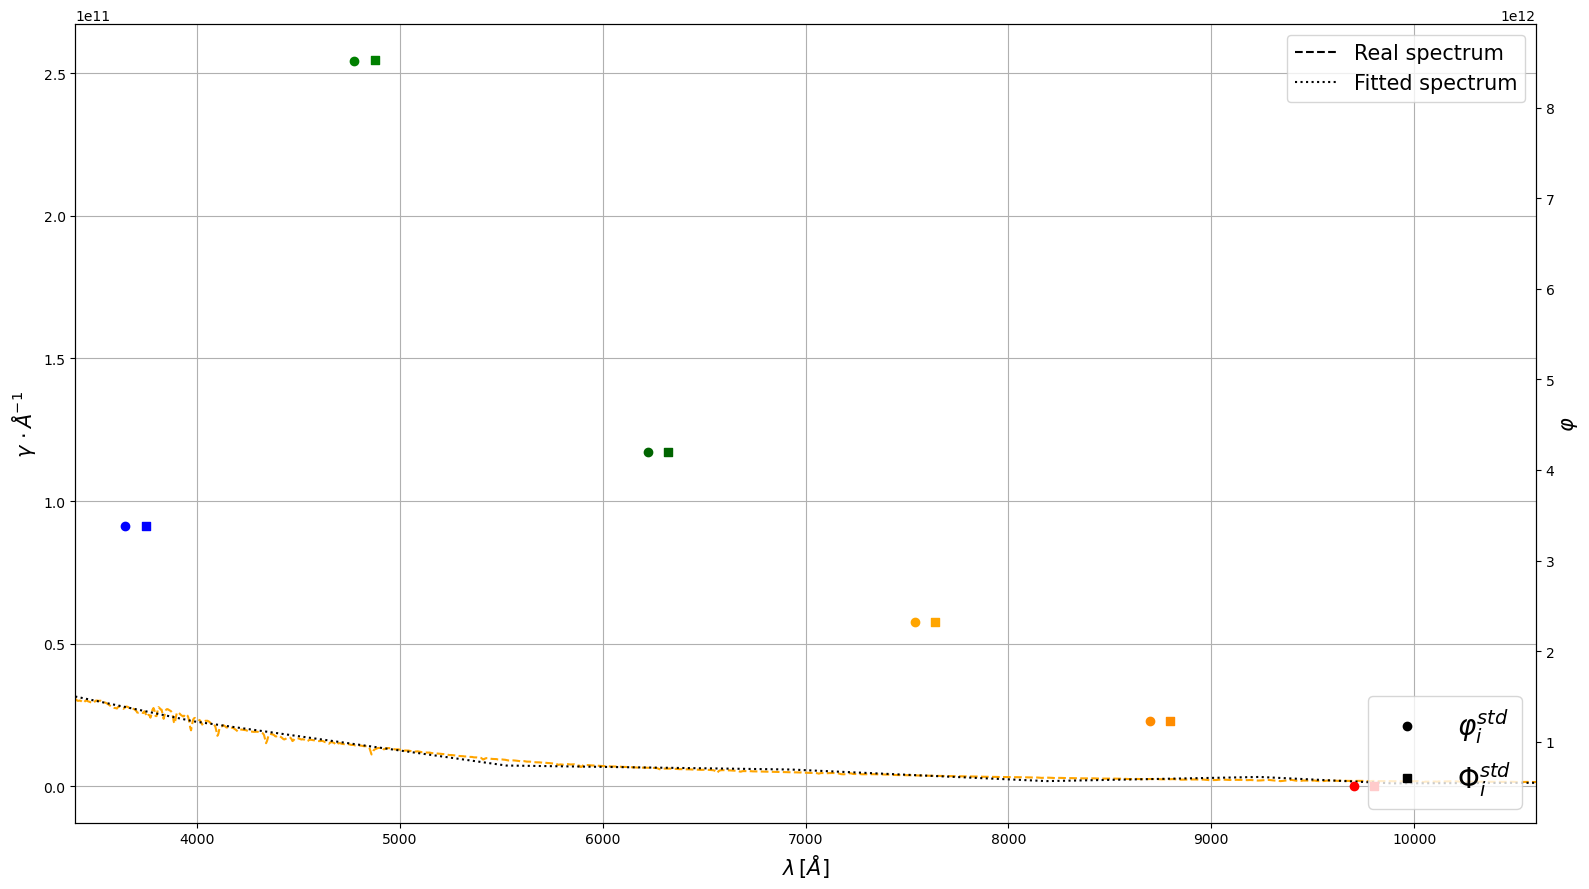

In [257]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,sed_dict[example_id].flux*Seff*exptime,ls='--',color='orange',alpha=1.0)
ax1.plot(estim_dict[example_id]['std'].wave,estim_dict[example_id]['std'].flux*Seff*exptime,ls=':',color='k',alpha=1.0)

ax2 = ax1.twinx()
    
ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,1.75e10)
#ax2.set_ylim(0,7.5e12)
ax1.plot([],[],ls='--',color='k',label='Real spectrum')
ax1.plot([],[],ls=':',color='k',label='Fitted spectrum')
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()

for index,filter_ in enumerate(filters):
    ax2.scatter(eff_lambda[filter_],phi_std_dict[example_id][filter_],marker='o',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter_]+100.,Phi_std_dict[example_id][filter_][ref_ind_],marker='s',color=filter_colors[index])

ax2.plot([],[],ls='',marker='o',color='k',label=r'$\varphi^{std}_i$')
ax2.plot([],[],ls='',marker='s',color='k',label=r'$\Phi^{std}_i$')
ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=15)
ax2.legend(fontsize=20,loc='lower right')
plt.tight_layout()
print(spec.fluxunits)

In [258]:
example_id

'pickles_uk_2'

In [259]:
phi_std_dict[example_id]['Y']

506609824276.50433

In [260]:
Phi_std_dict[example_id]['Y'][ref_ind_]

507490906039.81866

In [261]:
(Phi_std_dict[example_id]['Y'][ref_ind_]-phi_std_dict[example_id]['Y'])*100./phi_std_dict[example_id]['Y']

0.17391722803098314

In [262]:
(-2.5*np.log10(1.+0.07384592008880174/100.))*1000.

-0.8014759978869431

In [263]:
(-2.5*np.log10(1.+0.10583758404974399/100.))*1000.

-1.1485092981752119

### And now we compare with the integrated fluxes from the real spectrum for each atmospheric situation 

<>:16: SyntaxWarning: invalid escape sequence '\,'
<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:16: SyntaxWarning: invalid escape sequence '\,'
<>:17: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_34263/3158085489.py:16: SyntaxWarning: invalid escape sequence '\,'
  ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
/tmp/ipykernel_34263/3158085489.py:17: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)


photlam


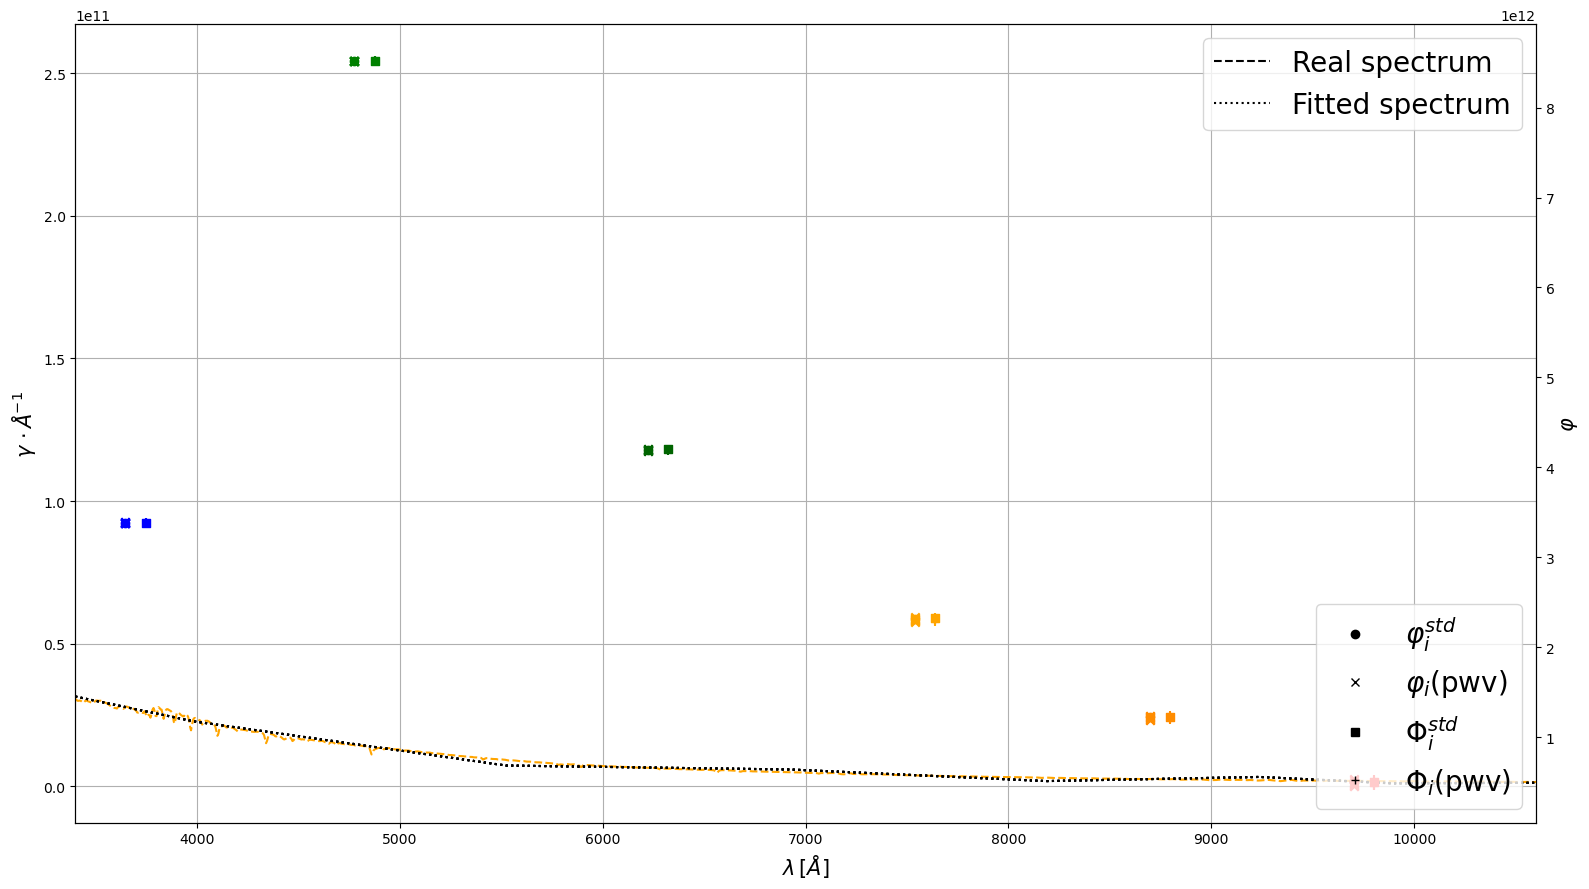

In [264]:
fig=plt.figure(figsize=(16,9))
ax1 = fig.add_subplot(111)

ax1.plot(sed_dict[example_id].wave,example_spec.flux*Seff*exptime,ls='--',color='orange',alpha=1.0)
ax1.plot(estim_dict[example_id]['std'].wave,estim_dict[example_id]['std'].flux*Seff*exptime,ls=':',color='k',alpha=1.0)
for isim in range(n_sim):
    ax1.plot(estim_dict[example_id]['std'].wave,estim_dict[example_id][isim].flux*Seff*exptime,ls=':',color='k',alpha=0.5)

ax2 = ax1.twinx()
    
ax1.set_xlim(WLMIN,WLMAX)
#ax1.set_ylim(0.,1.75e10)
#ax2.set_ylim(0,7.5e12)
ax1.plot([],[],ls='--',color='k',label='Real spectrum')
ax1.plot([],[],ls=':',color='k',label='Fitted spectrum')
ax1.set_xlabel('$\\lambda \, [$'+wavelabel+']',fontsize=15)
ax1.set_ylabel('$\gamma \, \cdot $'+wavelabel+'$^{-1}$',fontsize=15)
ax1.grid()

for index,filter_ in enumerate(filters):
    ax2.scatter(eff_lambda[filter_],phi_std_dict[example_id][filter_],marker='o',color=filter_colors[index])
    ax2.scatter(eff_lambda[filter_]+100.,Phi_std_dict[example_id][filter_][ref_ind_],marker='s',color=filter_colors[index])
    for isim in range(n_sim):
        ax2.scatter(eff_lambda[filter_],phi_t_dict[example_id][filter_][isim],marker='x',color=filter_colors[index])
        ax2.scatter(eff_lambda[filter_]+100.,Phi_t_dict[example_id][filter_][isim],marker='+',color=filter_colors[index])
    
ax2.plot([],[],ls='',marker='o',color='k',label=r'$\varphi^{std}_i$')
ax2.plot([],[],ls='',marker='x',color='k',label=r'$\varphi_i($'+'{0})'.format(variable_param))
ax2.plot([],[],ls='',marker='s',color='k',label=r'$\Phi^{std}_i$')
ax2.plot([],[],ls='',marker='+',color='k',label=r'$\Phi_i($'+'{0})'.format(variable_param))
#ax2.set_yscale("log")
ax2.set_ylabel(r'$\varphi$',fontsize=15)
ax1.legend(fontsize=20)
ax2.legend(fontsize=20,loc='lower right')
plt.tight_layout()
print(spec.fluxunits)

# Color compensation 

Let us introduce the notation and formalism: 

$$ m_{i,b}(t) = -2.5 \log_{10} \frac{\int F_i(\lambda) \, T_b(\lambda,t) \, S_{eff} \, t_{exp} \frac{d\lambda}{h\lambda}}{\int F_{AB} \, T_{tel,b}(\lambda) \, S_{eff} \, t_{exp} \frac{d\lambda}{h\lambda}} = -2.5 \log_{10} \frac{\varphi_{i,b}(t)}{\Phi_{AB,b}}$$ 

$$T_b (\lambda,t) = T_{tel,b}(\lambda) \cdot T_{atm}(\lambda,t) $$ 

$$T^{std}_b (\lambda) = T_{tel,b}(\lambda) \cdot T^{std}_{atm}(\lambda) $$ 

$$\vec{\varphi}^{\, corr}_i = \vec{\varphi}_i(t) \cdot \frac{\vec{\Phi}^{std}_i}{\vec{\Phi}_i(t)} $$

$$\Phi^{std}_{i,b} = \int \hat{F}_i(\lambda) \, T^{std}_b(\lambda) \, S_{eff} \, t_{exp} \, \frac{d\lambda}{h \lambda} $$

$$\Phi_{i,b}(t) = \int \hat{F}_i(\lambda) \, T_b(\lambda,t) \, S_{eff} \, t_{exp} \, \frac{d\lambda}{h \lambda} $$ 

$$\vec{\varphi}^{\, corr}_{i,\mu+1} = \vec{\varphi}_{i,\mu}(t) \cdot \frac{\vec{\Phi}^{std}_i}{\vec{\Phi}_i(t)} $$ 


We compute the integrated flux correction, 

$$ \vec{\varphi}^{\, corr}_i = \vec{\varphi}_i(t) \cdot \frac{\vec{\Phi}^{std}_i}{\vec{\Phi}_i(t)} \, . $$

In [265]:
phi_corr_dict = {}

for ised in sed_dict.keys():
    phi_corr_dict[ised] = {}
    for filter in filters:
        phi_corr_dict[ised][filter] = []
        for isim in range(n_sim):
            phi_corr_ = phi_t_dict[ised][filter][isim]*Phi_std_dict[ised][filter][isim]/Phi_t_dict[ised][filter][isim]
            phi_corr_dict[ised][filter].append(phi_corr_)
        

We compare the result of doing $ \vec{\varphi}^{\, corr}_i $ with the *real* result from the real spectrum passing through the *standard atmosphere*, that is, $\vec{\varphi}^{\, std}_i $, which we want to recover (and to which we will not have access in general)  

In [266]:
example_vec_phi_std = []
example_vec_phi_corr_dict = {}

for filter in filters:
    phi_std_ = phi_std_dict[example_id][filter]
    example_vec_phi_std.append(phi_std_)
example_vec_phi_std = np.array(example_vec_phi_std)

for isim in range(n_sim):
    example_vec_phi_corr_dict[isim] = []
    for filter in filters:
        phi_corr_ = phi_corr_dict[example_id][filter][isim]
        example_vec_phi_corr_dict[isim].append(phi_corr_)
    example_vec_phi_corr_dict[isim] = np.array(example_vec_phi_corr_dict[isim])
    

In [267]:
example_vec_phi_std

array([3.38144990e+12, 8.51557523e+12, 4.19792635e+12, 2.31959617e+12,
       1.22720673e+12, 5.06609824e+11])

In [268]:
example_vec_phi_corr_dict[n_sim-1]

array([3.38143130e+12, 8.51513967e+12, 4.19827753e+12, 2.32017862e+12,
       1.23243237e+12, 5.19028963e+11])

/tmp/ipykernel_34263/3652099363.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=yticks,fontsize=15)


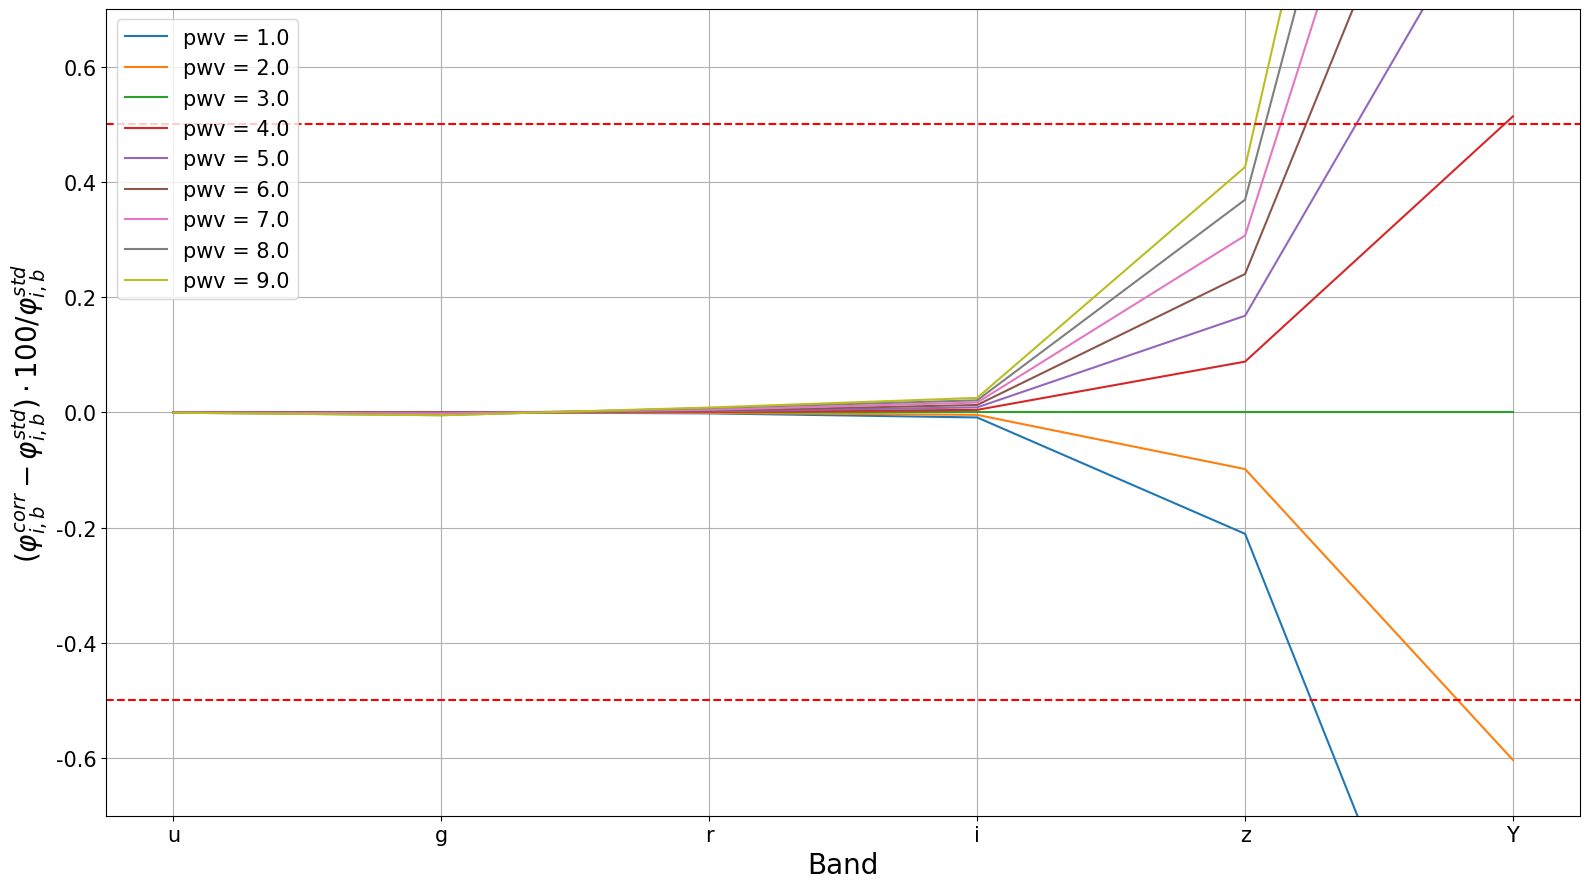

In [269]:
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
for isim in range(n_sim):
    ax.plot(np.arange(len(filters)),(example_vec_phi_corr_dict[isim]-example_vec_phi_std)*100./example_vec_phi_std,label='{0} = {1}'.format(variable_param,atm_vals[isim]))
ax.axhline(y=-0.5,ls='--',color='r')
ax.axhline(y=0.5,ls='--',color='r')
ax.set_ylim(-0.7,0.7)
ax.grid()
ax.set_xlabel('Band',fontsize=20)
xticks = ax.get_xticks()
yticks = np.round(ax.get_yticks(),3)
ax.set_xticks(ticks=xticks[1:-1])
ax.set_xticklabels(labels=filters,fontsize=15)
ax.set_yticklabels(labels=yticks,fontsize=15)
ax.set_ylabel(r'$(\varphi_{i,b}^{corr}-\varphi_{i,b}^{std}) \cdot 100 / \varphi_{i,b}^{std}$',fontsize=20)
ax.legend(loc="best",fontsize=15)
plt.tight_layout()

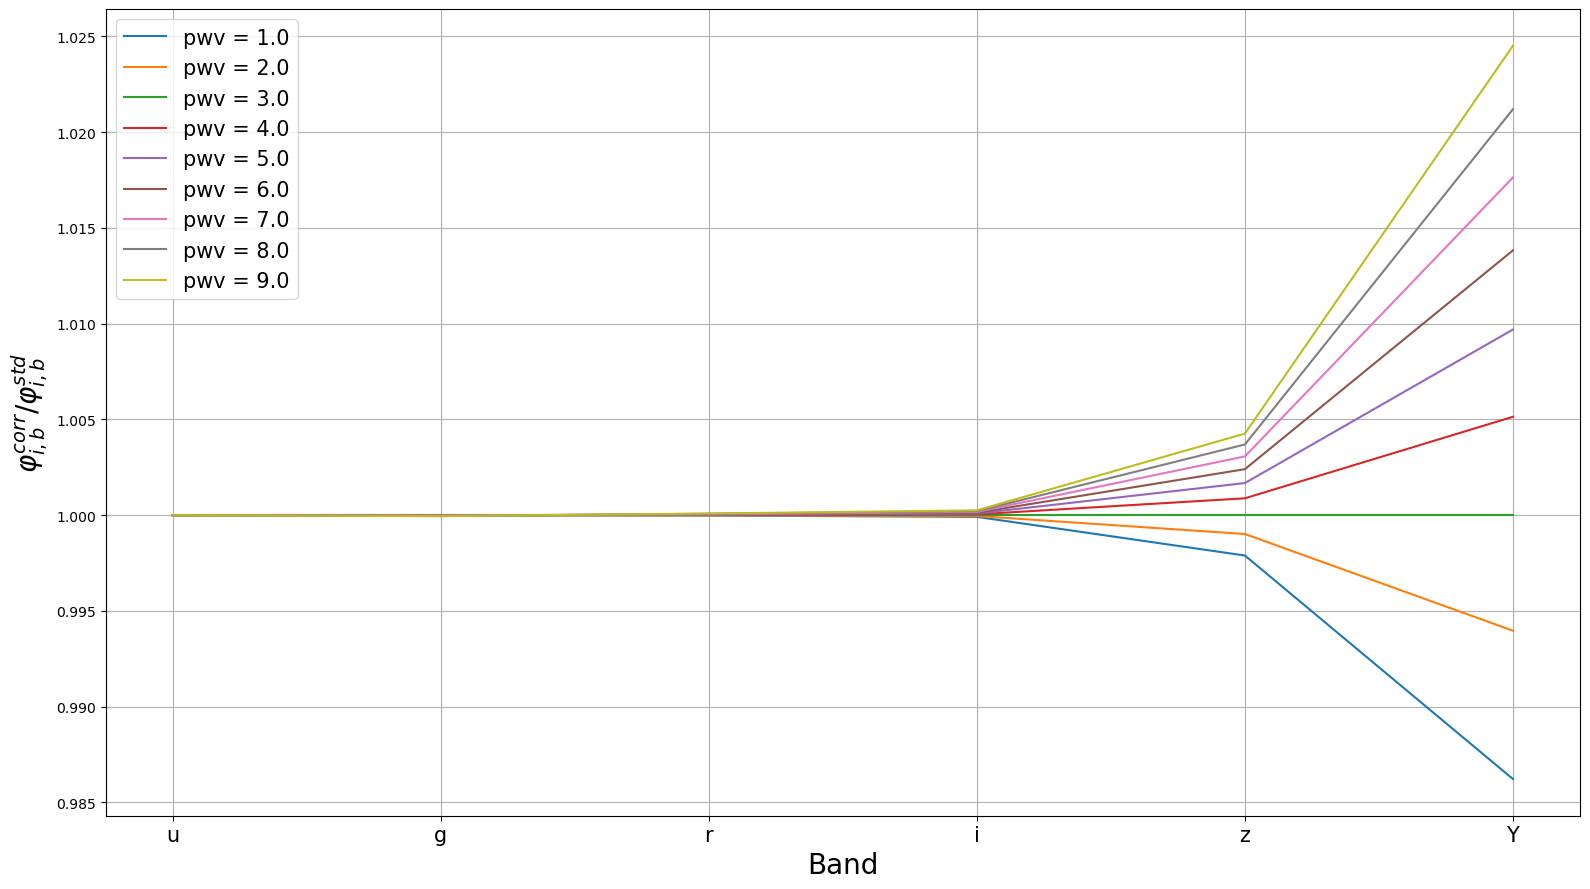

In [270]:
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
for isim in range(n_sim):
    ax.plot(np.arange(len(filters)),(example_vec_phi_corr_dict[isim]/example_vec_phi_std),label='{0} = {1}'.format(variable_param,atm_vals[isim]))
#ax.axhline(y=-0.5,ls='--',color='r')
#ax.axhline(y=0.5,ls='--',color='r')
#ax.set_ylim(-0.7,0.7)
ax.grid()
ax.set_xlabel('Band',fontsize=20)
xticks = ax.get_xticks()
#yticks = np.round(ax.get_yticks(),)
ax.set_xticks(ticks=xticks[1:-1])
ax.set_xticklabels(labels=filters,fontsize=15)
#ax.set_yticklabels(labels=yticks,fontsize=15)
ax.set_ylabel(r'$\varphi_{i,b}^{corr}/\varphi_{i,b}^{std}$',fontsize=20)
ax.legend(loc="best",fontsize=15)
plt.tight_layout()

### We now work with magnitudes 

If we express the correction in magnitudes, we have 

$$\vec{m}^{\, corr}_i = \vec{m}_i(t)+\vec{\mathbb{m}}^{std}_i - \vec{\mathbb{m}}_i(t) $$

In [271]:
mag_corr_dict = {}

for ised in sed_dict.keys():
    mag_corr_dict[ised] = {}
    for filter in filters:
        mag_corr_dict[ised][filter] = []
        for isim in range(n_sim):
            mag_corr_ = mag_t_dict[ised][filter][isim]+Mag_std_dict[ised][filter][isim]-Mag_t_dict[ised][filter][isim]
            mag_corr_dict[ised][filter].append(mag_corr_)
        

In [272]:
example_vec_mag_std = []
example_vec_mag_corr_dict = {}

for filter in filters:
    mag_std_ = mag_std_dict[example_id][filter]
    example_vec_mag_std.append(mag_std_)
example_vec_mag_std = np.array(example_vec_mag_std)

for isim in range(n_sim):
    example_vec_mag_corr_dict[isim] = []
    for filter in filters:
        mag_corr_ = mag_corr_dict[example_id][filter][isim]
        example_vec_mag_corr_dict[isim].append(mag_corr_)
    example_vec_mag_corr_dict[isim] = np.array(example_vec_mag_corr_dict[isim])
    

In [273]:
example_vec_mag_std

array([-0.09843037, -0.03839496,  0.41647124,  0.73211224,  0.99968251,
        1.28058481])

In [274]:
example_vec_mag_corr_dict[n_sim-1]

array([-0.0984244 , -0.03833943,  0.41638041,  0.73183964,  0.99506909,
        1.25428984])

/tmp/ipykernel_34263/3421522060.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=yticks,fontsize=15)


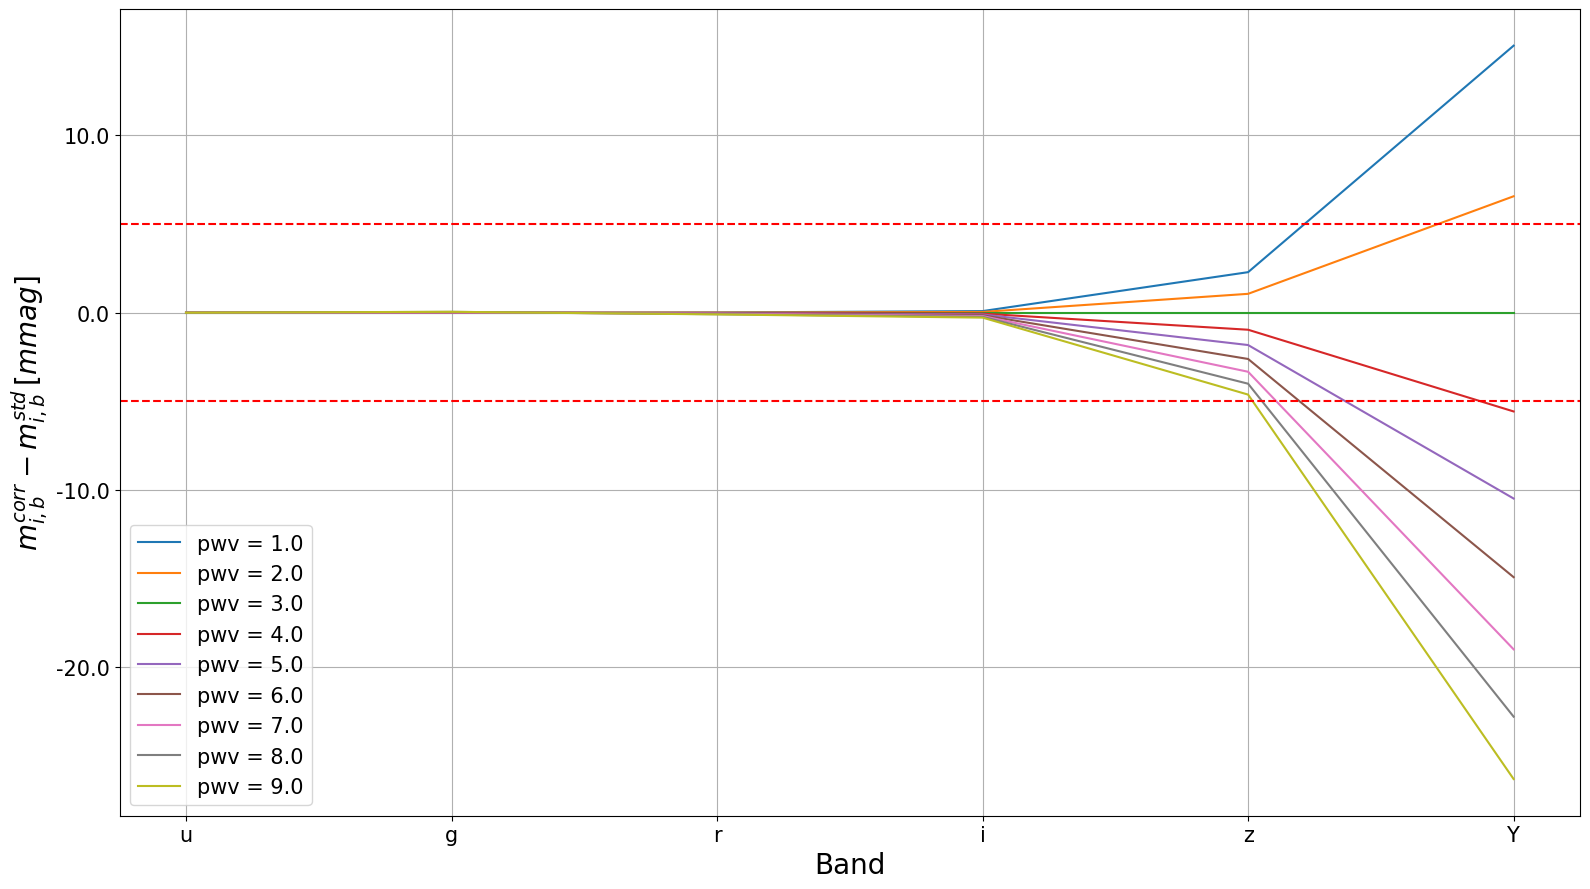

In [275]:
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
for isim in range(n_sim):
    ax.plot(np.arange(len(filters)),(example_vec_mag_corr_dict[isim]-example_vec_mag_std)*1000.,label='{0} = {1}'.format(variable_param,atm_vals[isim]))
ax.axhline(y=5.0,ls='--',color='r')
ax.axhline(y=-5.0,ls='--',color='r')
ax.grid()
ax.set_xlabel('Band',fontsize=20)
xticks = ax.get_xticks()
yticks = np.round(ax.get_yticks(),3)
ax.set_xticks(ticks=xticks[1:-1])
ax.set_xticklabels(labels=filters,fontsize=15)
ax.set_yticklabels(labels=yticks,fontsize=15)
ax.set_ylabel(r'$m_{i,b}^{corr}-m_{i,b}^{std} \, [mmag]$',fontsize=20)
ax.legend(loc="best",fontsize=15)
plt.tight_layout()

### Impact of different atmospheres with respect to standard one 

In [276]:
Mag_diff_dict = {}

for ised in sed_dict.keys():
    Mag_diff_dict[ised] = {}
    for filter in filters:
        Mag_diff_dict[ised][filter] = []
        for isim in range(n_sim):
            Mag_diff_ = Mag_std_dict[ised][filter][isim]-Mag_t_dict[ised][filter][isim]
            Mag_diff_dict[ised][filter].append(Mag_diff_)

In [277]:
example_vec_Mag_diff_dict = {}

for isim in range(n_sim):
    example_vec_Mag_diff_dict[isim] = []
    for filter in filters:
        Mag_diff_ = Mag_diff_dict[example_id][filter][isim]
        example_vec_Mag_diff_dict[isim].append(Mag_diff_)
    example_vec_Mag_diff_dict[isim] = np.array(example_vec_Mag_diff_dict[isim])
    

/tmp/ipykernel_34263/475109064.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=yticks,fontsize=15)


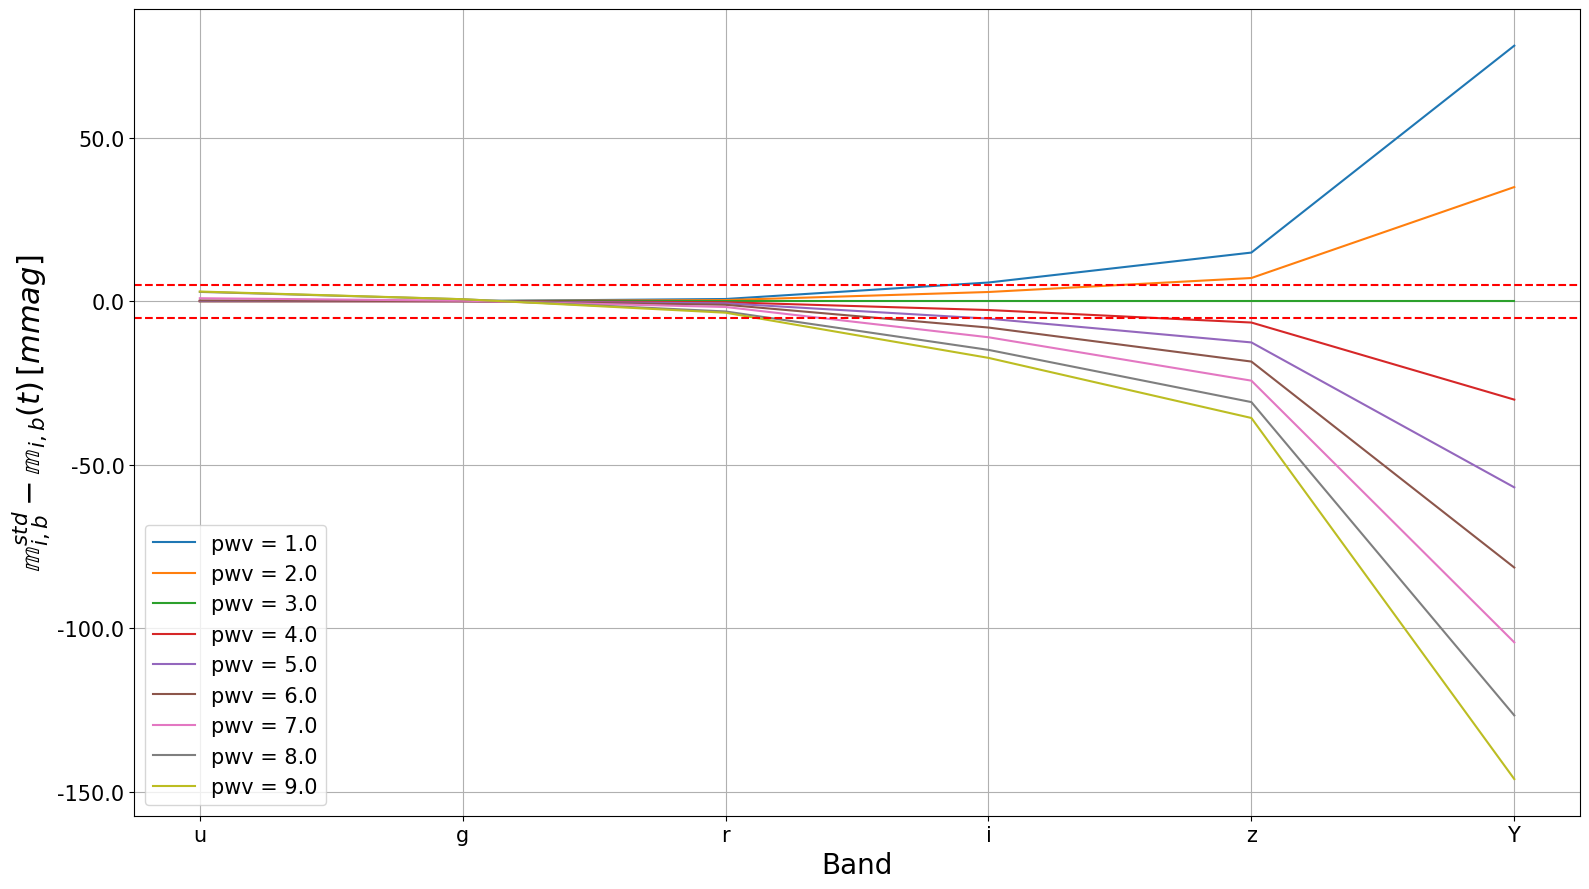

In [278]:
fig = plt.figure(figsize=(16,9))
ax = fig.add_subplot(111)
for isim in range(n_sim):
    ax.plot(np.arange(len(filters)),example_vec_Mag_diff_dict[isim]*1000.,label='{0} = {1}'.format(variable_param,atm_vals[isim]))
ax.axhline(y=5.0,ls='--',color='r')
ax.axhline(y=-5.0,ls='--',color='r')
ax.grid()
ax.set_xlabel('Band',fontsize=20)
xticks = ax.get_xticks()
yticks = np.round(ax.get_yticks(),3)
ax.set_xticks(ticks=xticks[1:-1])
ax.set_xticklabels(labels=filters,fontsize=15)
ax.set_yticklabels(labels=yticks,fontsize=15)
ax.set_ylabel(r'$\mathbb{m}_{i,b}^{std}-\mathbb{m}_{i,b}(t) \, [mmag]$',fontsize=22)
ax.legend(loc="best",fontsize=15)
plt.tight_layout()

In [279]:
ratio_phi_dict = {}

for ised in sed_dict.keys():
    ratio_phi_dict[ised] = {}
    for filter in filters:
        ratio_phi_dict[ised][filter] = []
        for isim in range(n_sim):
            ratio_phi_ = phi_corr_dict[ised][filter][isim]/phi_std_dict[ised][filter]
            ratio_phi_dict[ised][filter].append(ratio_phi_)

In [280]:
delta_mag_dict = {}

for ised in sed_dict.keys():
    delta_mag_dict[ised] = {}
    for filter in filters:
        delta_mag_dict[ised][filter] = []
        for isim in range(n_sim):
            delta_mag_ = mag_corr_dict[ised][filter][isim]-mag_std_dict[ised][filter]
            delta_mag_dict[ised][filter].append(delta_mag_)

In [281]:
#delta_mag_dict

In [282]:
#id_by_type

In [283]:
#delta_mag_dict[example_id]

In [284]:
type_colors

{'O': 'b',
 'B': 'dodgerblue',
 'A': 'cyan',
 'F': 'g',
 'G': 'gold',
 'K': 'r',
 'M': 'brown'}

u
g
r
i
z
Y


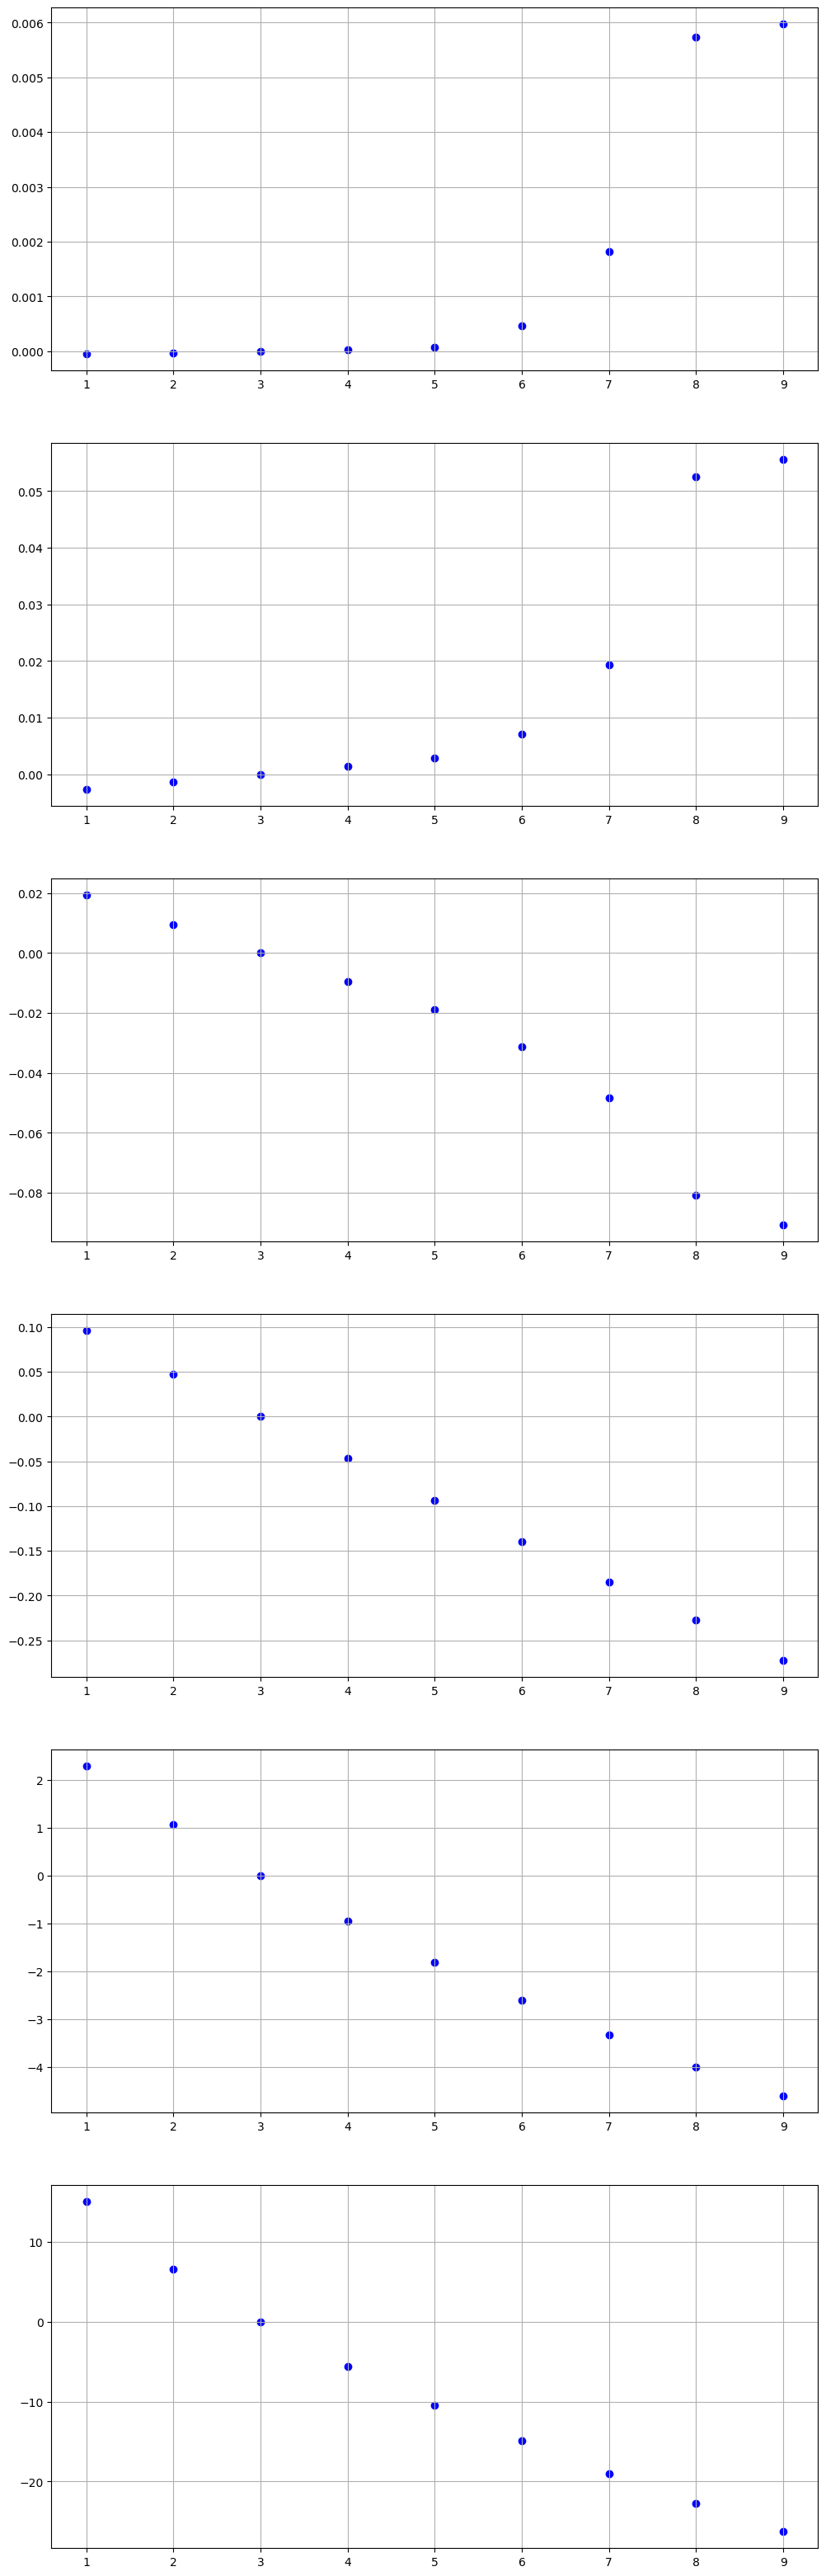

In [285]:
fig = plt.figure(figsize=(12,40))

for i,filter in enumerate(filters):
    print(filter)
    pos_ = int('{0}1{1}'.format(len(filters),i+1))
    ax = fig.add_subplot(pos_)
    
    for isim in range(n_sim):
        for type_ in spectral_types:
            
            ids_ = id_by_type[type_]
            for id_ in ids_:
                delta_mag_ = delta_mag_dict[id_][filter][isim]*1000.
                
                if id_==example_id:
                    alpha = 1.0
                    marker = 'o'
                    
                    ax.scatter(atm_vals[isim],delta_mag_,marker=marker,color=type_colors[type_],alpha=alpha)
                    ax.grid()
                


In [286]:
id_by_type

{'O': ['pickles_uk_2']}

u
g
r
i
z
Y


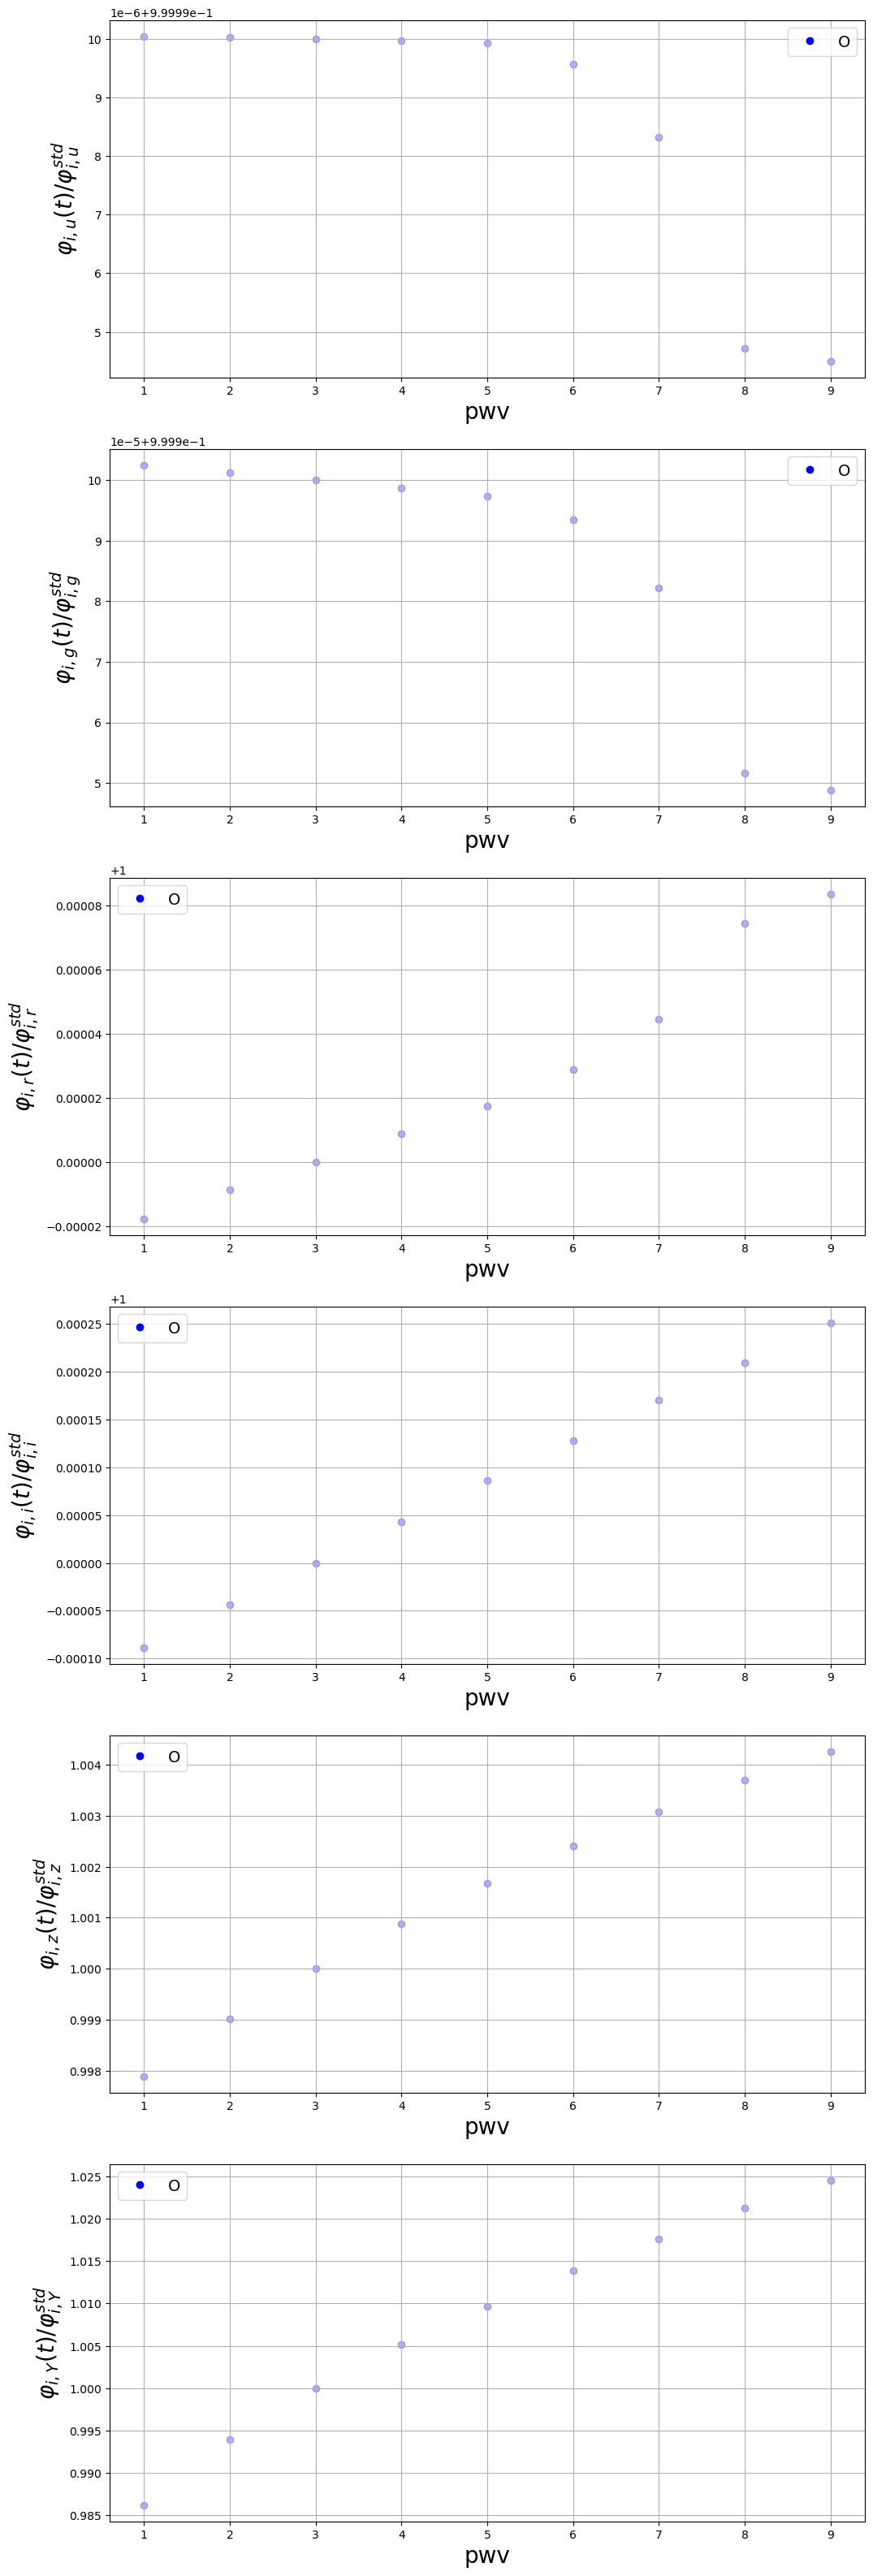

In [287]:
fig = plt.figure(figsize=(12,40))

for i,filter_ in enumerate(filters):
    print(filter_)
    pos_ = int('{0}1{1}'.format(len(filters),i+1))
    ax = fig.add_subplot(pos_)
    
    for isim in range(n_sim):
        for type_ in spectral_types:
            
            ids_ = id_by_type[type_]
            for id_ in ids_:
                ratio_phi_ = ratio_phi_dict[id_][filter_][isim]

                ax.scatter(atm_vals[isim],ratio_phi_,marker='o',color=type_colors[type_],alpha=0.3)
                ax.grid()
                ax.set_xlabel(variable_param,fontsize=20)
                ax.set_ylabel(r'$\varphi_{i,'+r'{0}'.format(filter_)+r'}(t) / \varphi^{std}_{i,'+r'{0}'.format(filter_)+r'}$',fontsize=20)
    
    for type_ in spectral_types:
        ax.plot([],[],ls='',marker='o',color=type_colors[type_],label=type_)
        
    ax.legend(loc="best",fontsize=14)


u
g
r
i
z
Y


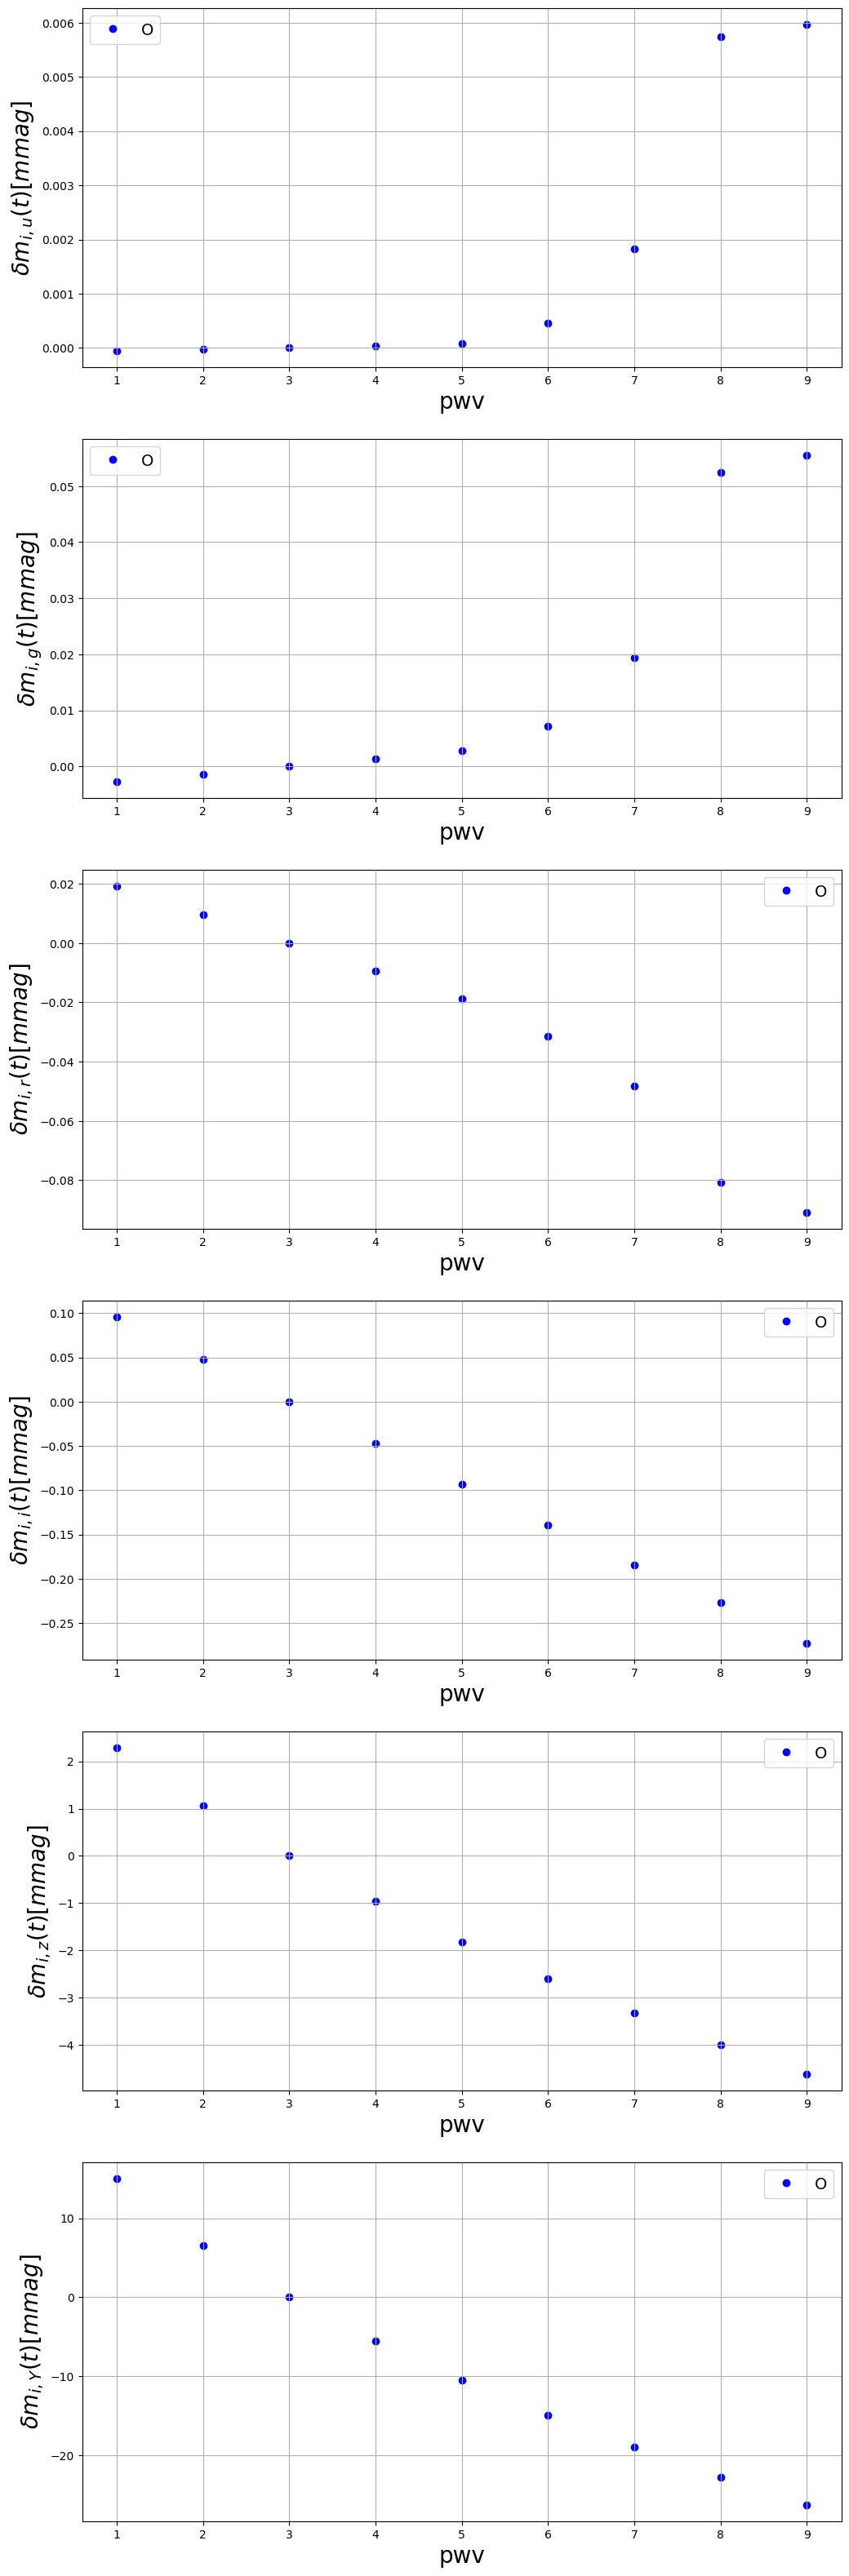

In [288]:
fig = plt.figure(figsize=(12,40))

for i,filter_ in enumerate(filters):
    print(filter_)
    pos_ = int('{0}1{1}'.format(len(filters),i+1))
    ax = fig.add_subplot(pos_)
    
    for isim in range(n_sim):
        for type_ in spectral_types:
            
            ids_ = id_by_type[type_]
            for id_ in ids_:
                delta_mag_ = delta_mag_dict[id_][filter_][isim]*1000.

                ax.scatter(atm_vals[isim],delta_mag_,marker='o',color=type_colors[type_],alpha=1./len(ids_))
                ax.grid()
                ax.set_xlabel(variable_param,fontsize=20)
                ax.set_ylabel(r'$\delta '+r'm_{i,'+r'{0}'.format(filter_)+r'}(t) [mmag]$',fontsize=20)
    
    for type_ in spectral_types:
        ax.plot([],[],ls='',marker='o',color=type_colors[type_],label=type_)
        
    ax.legend(loc="best",fontsize=14)


In [289]:
10**((1.5e-2)/2.5)

1.0139113857366795

In [290]:
id_by_type['O']

['pickles_uk_2']

u
g
r
i
z
Y


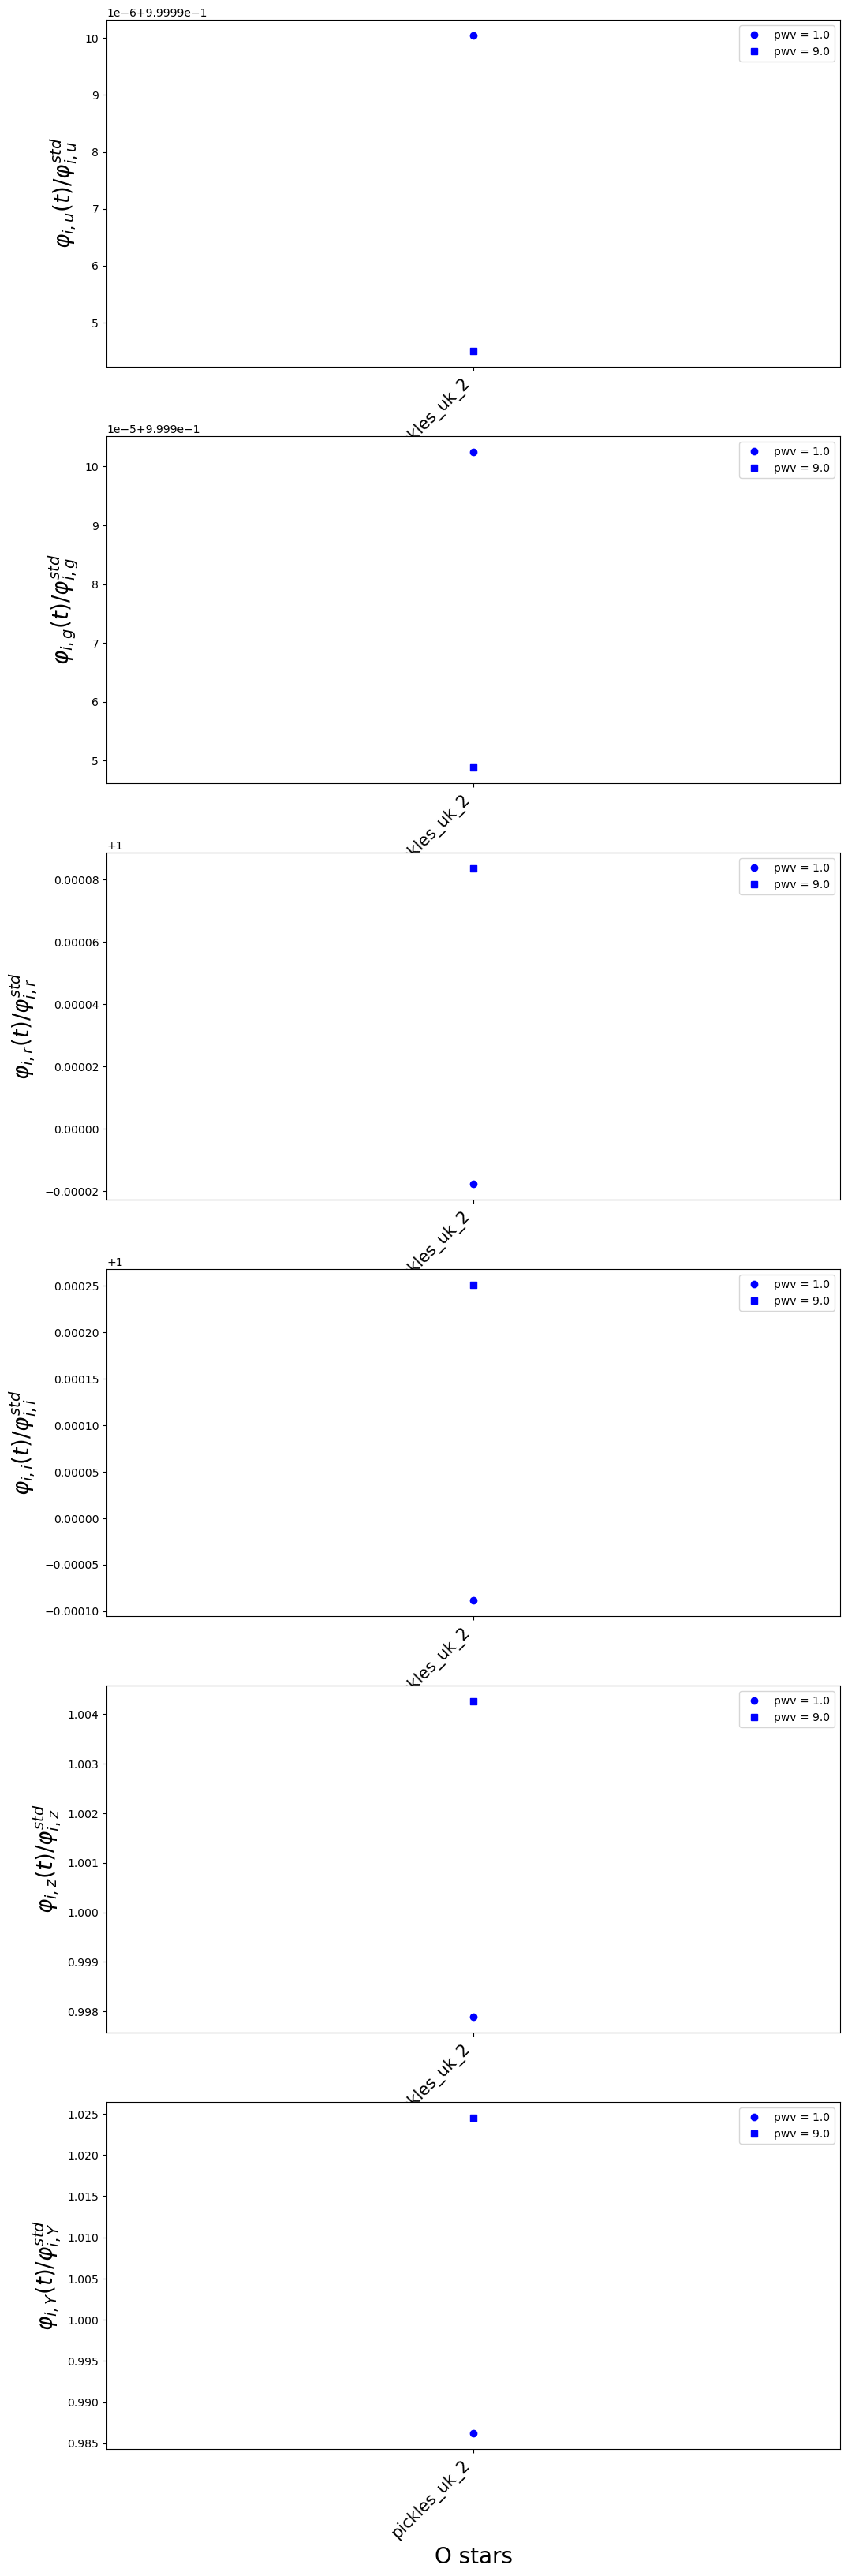

In [291]:
fig = plt.figure(figsize=(12,40))
type_ = 'O'

for i,filter_ in enumerate(filters):
    print(filter_)
    pos_ = int('{0}1{1}'.format(len(filters),i+1))
    ax = fig.add_subplot(pos_)

    ids_ = id_by_type[type_]
    for i,id_ in enumerate(ids_):
        ratio_phi_min_ = ratio_phi_dict[id_][filter_][min_ind_]
        ratio_phi_max_ = ratio_phi_dict[id_][filter_][max_ind_]
        
        ax.scatter(i,ratio_phi_min_,marker='o',color=type_colors[type_],alpha=1.0)
        ax.scatter(i,ratio_phi_max_,marker='s',color=type_colors[type_],alpha=1.0)
        ax.grid()
        ax.set_xlabel('{0} stars'.format(type_),fontsize=20)
        ax.set_ylabel(r'$\varphi_{i,'+r'{0}'.format(filter_)+r'}(t) / \varphi^{std}_{i,'+r'{0}'.format(filter_)+'}$',fontsize=20)
    ax.plot([],[],ls='',marker='o',color=type_colors[type_],label='{0} = {1}'.format(variable_param,atm_vals[min_ind_]))
    ax.plot([],[],ls='',marker='s',color=type_colors[type_],label='{0} = {1}'.format(variable_param,atm_vals[max_ind_]))
    '''
    ax.axhline(y=-5.0,ls='--',color='k')
    ax.axhline(y=5.0,ls='--',color='k')
    ax.axhline(y=-2.0,ls='--',color='k')
    ax.axhline(y=2.0,ls='--',color='k')
    '''
    ax.grid()
    xticks_ = np.arange(len(ids_))
    ax.set_xticks(ticks=xticks_)
    ax.set_xticklabels(labels=ids_,fontsize=15,rotation=45,ha='right')
    ax.legend(loc="best")


u
g
r
i
z
Y


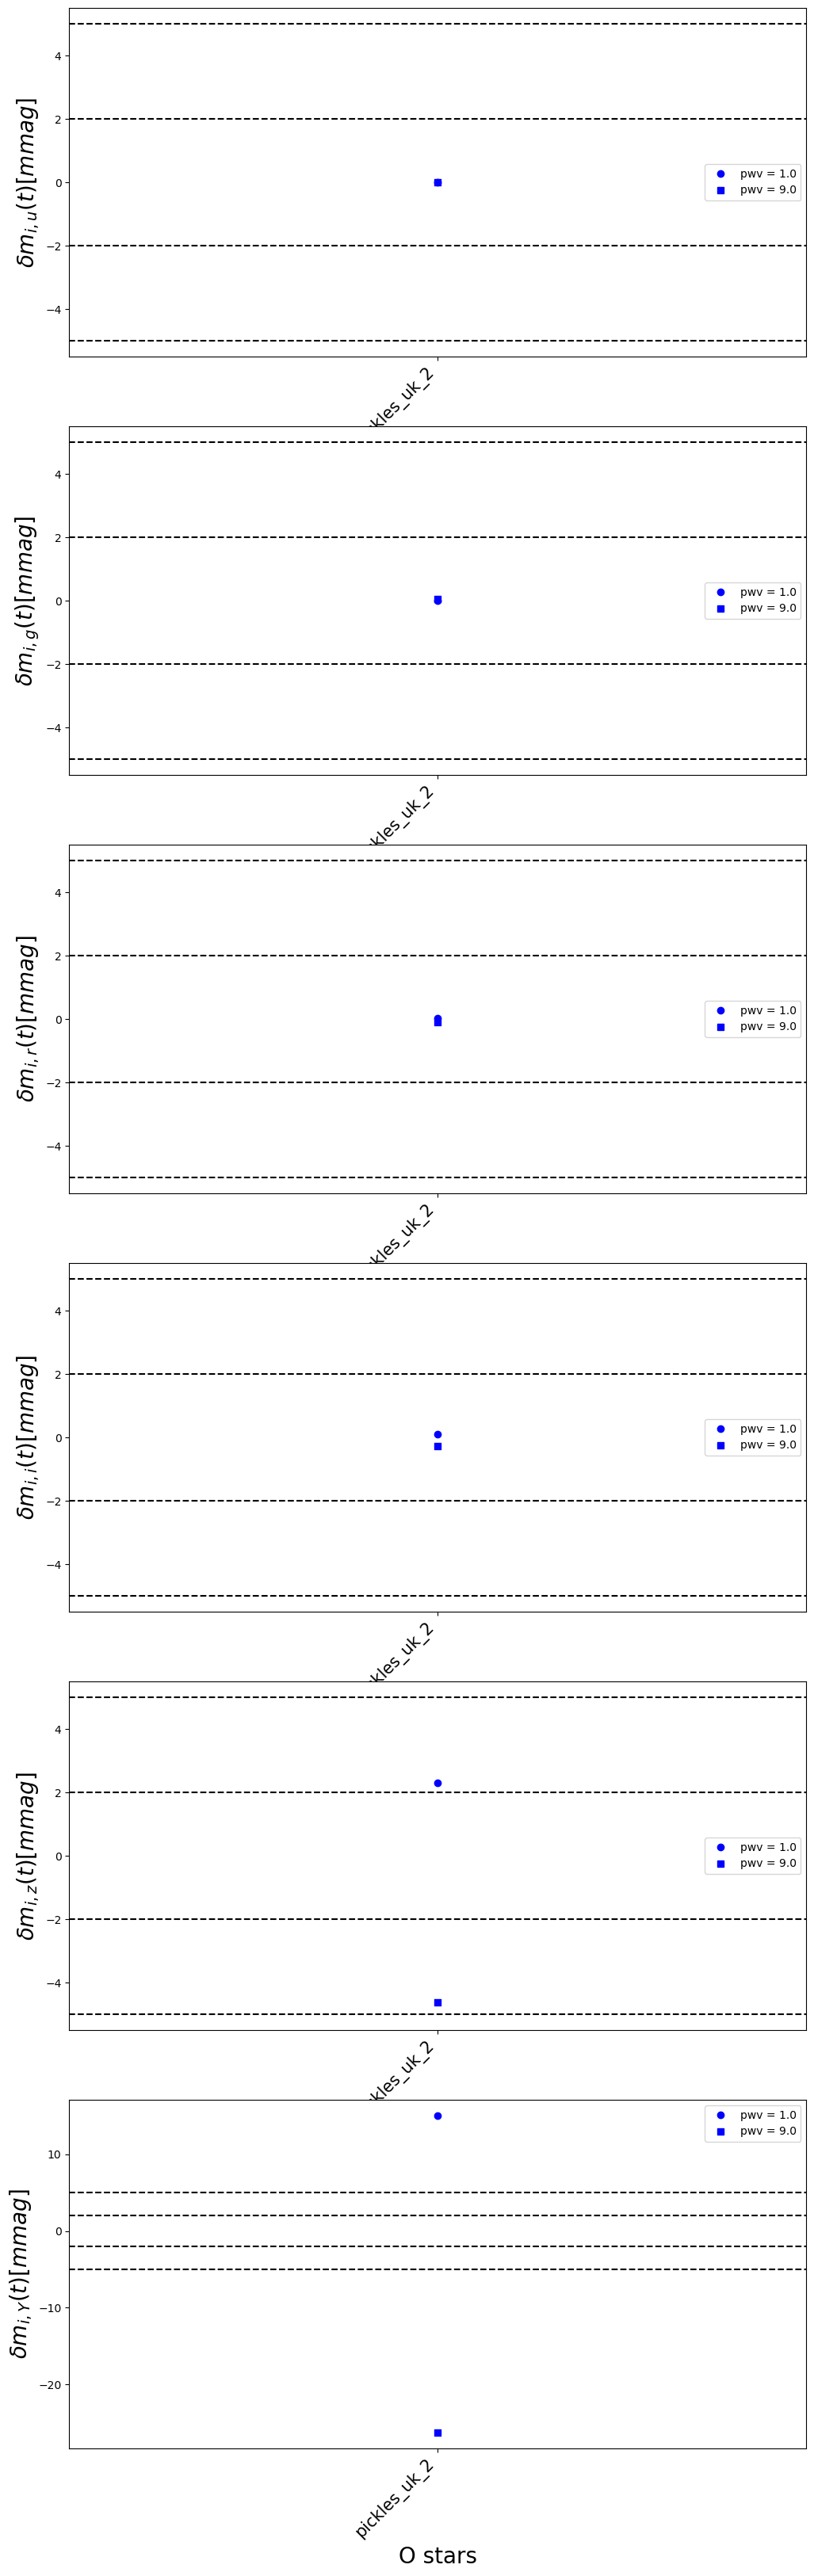

In [292]:
fig = plt.figure(figsize=(12,40))
type_ = 'O'

for i,filter_ in enumerate(filters):
    print(filter_)
    pos_ = int('{0}1{1}'.format(len(filters),i+1))
    ax = fig.add_subplot(pos_)

    ids_ = id_by_type[type_]
    for i,id_ in enumerate(ids_):
        delta_mag_min_ = delta_mag_dict[id_][filter_][min_ind_]*1000.
        delta_mag_max_ = delta_mag_dict[id_][filter_][max_ind_]*1000.

        ax.scatter(i,delta_mag_min_,marker='o',color=type_colors[type_],alpha=1.0)
        ax.scatter(i,delta_mag_max_,marker='s',color=type_colors[type_],alpha=1.0)
        ax.grid()
        ax.set_xlabel('{0} stars'.format(type_),fontsize=20)
        ax.set_ylabel(r'$\delta '+r'm_{i,'+r'{0}'.format(filter_)+r'}(t) [mmag]$',fontsize=20)
    
    ax.plot([],[],ls='',marker='o',color=type_colors[type_],label='{0} = {1}'.format(variable_param,atm_vals[min_ind_]))
    ax.plot([],[],ls='',marker='s',color=type_colors[type_],label='{0} = {1}'.format(variable_param,atm_vals[max_ind_]))
    ax.axhline(y=-5.0,ls='--',color='k')
    ax.axhline(y=5.0,ls='--',color='k')
    ax.axhline(y=-2.0,ls='--',color='k')
    ax.axhline(y=2.0,ls='--',color='k')
    ax.grid()
    xticks_ = np.arange(len(ids_))
    ax.set_xticks(ticks=xticks_)
    ax.set_xticklabels(labels=ids_,fontsize=15,rotation=45,ha='right')
    ax.legend(loc="best")


In [293]:
example_id

'pickles_uk_2'

In [294]:
bad_ids_ = [example_id]

In [295]:
test_type_ = 'O'
test_band_ = 'Y'
ids_ = id_by_type[test_type_]
print(len(ids_))

1


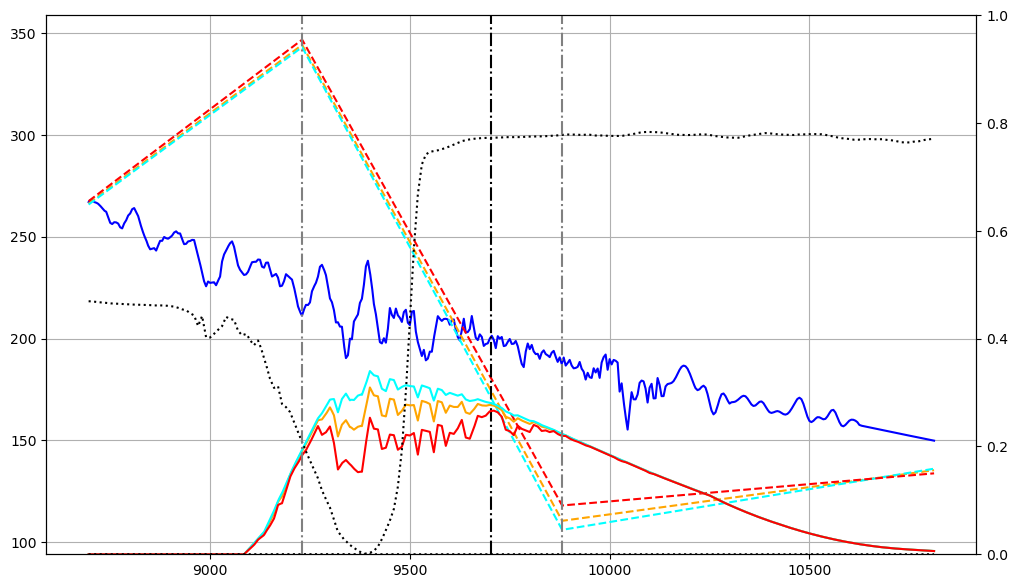

In [296]:
fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111)

wl_mask_ = (wl_baseline>=eff_lambda['z'])*(wl_baseline<eu_eff_lambda['Ye'])
ax.plot(sed_dict[example_id].wave[wl_mask_],sed_dict[example_id].flux[wl_mask_],ls='-',color='b')
ax.plot(estim_dict[example_id]['std'].wave[wl_mask_],estim_dict[example_id]['std'].flux[wl_mask_],ls='--',color='orange')
ax.plot(estim_dict[example_id][min_ind_].wave[wl_mask_],estim_dict[example_id][min_ind_].flux[wl_mask_],ls='--',color='cyan')
ax.plot(estim_dict[example_id][max_ind_].wave[wl_mask_],estim_dict[example_id][max_ind_].flux[wl_mask_],ls='--',color='r')
ax.axvline(x=eff_lambda['Y'],ls='-.',color='k')
ax.grid()

ax2 = ax.twinx()
ax2.plot(total_passband_ref['Y'].wave[wl_mask_],total_passband_ref['Y'].throughput[wl_mask_],color='orange')
ax2.plot(total_passband['Y'][min_ind_].wave[wl_mask_],total_passband['Y'][min_ind_].throughput[wl_mask_],color='cyan')
ax2.plot(total_passband['Y'][max_ind_].wave[wl_mask_],total_passband['Y'][max_ind_].throughput[wl_mask_],color='r')
ax2.set_ylim(0.,1.)

ax2.plot(total_passband_ref['z'].wave[wl_mask_],total_passband_ref['z'].throughput[wl_mask_],ls=':',color='k')
ax2.plot(euclid_bp[0].wave[wl_mask_],euclid_bp[0].throughput[wl_mask_],ls=':',color='k')
ax2.axvline(x=over_lambda['z'],ls='-.',color='grey')
ax2.axvline(x=over_lambda['Y'],ls='-.',color='grey')


In [297]:
a_ = np.trapz(estim_dict[example_id]['std'].flux*total_passband_ref['Y'].throughput,x=wl_baseline)*K
a_

507490906039.81854

In [298]:
b_ = np.trapz(sed_dict[example_id].flux*total_passband_ref['Y'].throughput,x=wl_baseline)*K
b_

506609824276.5043

In [299]:
-2.5*np.log(a_/b_) #mmag

-0.0043441541785464105

In [300]:
phi_std_dict[example_id]['Y']

506609824276.50433

In [301]:
Phi_std_dict[example_id]['Y'][ref_ind_]

507490906039.81866

In [302]:
Phi_std_dict[example_id]['Y'][ref_ind_]-a_

0.0001220703125

In [303]:
phi_std_dict[example_id]['Y']-b_

6.103515625e-05

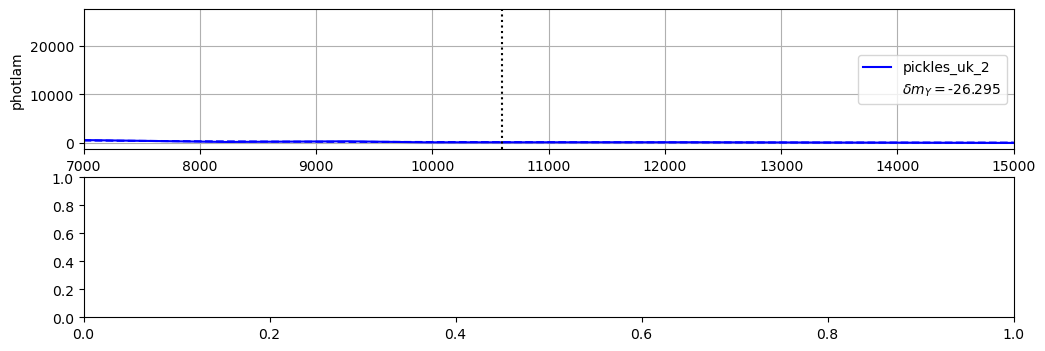

In [304]:

fig,axs = plt.subplots(len(bad_ids_)+1,figsize=(12,len(bad_ids_)*4))

for i,id_ in enumerate(bad_ids_):
    
    #estim_spec_ = estim_dict[id_]['std']
    estim_spec_ = estim_dict[id_][max_ind_]
    #spec_ = spec_by_type[test_type_][i]
    spec_ = sed_dict[id_]
    spec.convert('photlam')
    axs[i].plot(spec_.wave,spec_.flux,ls='--',color=type_colors[test_type_],alpha=1.0)
    axs[i].plot(estim_spec_.wave,estim_spec_.flux,ls='-',color=type_colors[test_type_],alpha=1.0,label=id_)
    axs[i].plot([],[],ls='',marker='',label=r'$\delta m_{0} ='.format(test_band_)+' $'+str(np.round(delta_mag_dict[id_][test_band_][max_ind_]*1000.,4)))
    axs[i].axvline(x=WLMIN,ls=':',color='k')
    axs[i].axvline(x=WLMAX,ls=':',color='k')
    axs[i].set_xlim(7000,15000)
    #axs[i].set_ylim(-100,500)
    #axs[i].set_yscale("log")
    axs[i].grid()
    axs[i].set_xlabel(wavelabel)
    axs[i].set_ylabel(spec.fluxunits)
    axs[i].legend(loc="center right")
    '''
    axs2 = axs[i].twinx()
    for i,filter_ in enumerate(filters):
        axs2.plot(lsst_bp[i].wave,lsst_bp[i].throughput,label=filter_names[i],color=filter_colors[i])
        axs2.axvline(x=eff_lambda[filter_],ls=':',color=filter_colors[i],alpha=1.0)
    
    for i,filter_ in enumerate(eu_filters):
        axs2.plot(euclid_bp[i].wave,euclid_bp[i].throughput,ls='--',color=eu_colors[filter_],label=filter_+r'$_E$')
        axs2.axvline(x=eu_eff_lambda[filter_],ls=':',color=eu_colors[filter_],alpha=1.0)
    
    for i,filter_ in enumerate(swift_filters):
        axs2.plot(euclid_bp[i].wave,swift_bp[i].throughput,ls='--',color=swift_colors[filter_],label=filter_)
        axs2.axvline(x=swift_eff_lambda[filter_],ls=':',color=swift_colors[filter_],alpha=1.0)
    '''
    #axs2.set_ylabel(r'$T_b(\lambda)$')


In [305]:
WLMAX

10600.0

In [306]:
total_passband_ref['u'].wave.max(),total_passband_ref['u'].throughput[-1]

(21449.0, 0.0)

In [307]:
eff_lambda

{'u': 3646.662679925946,
 'g': 4775.691487833466,
 'r': 6221.859926396509,
 'i': 7538.740989090991,
 'z': 8695.989678941447,
 'Y': 9703.267866775377}

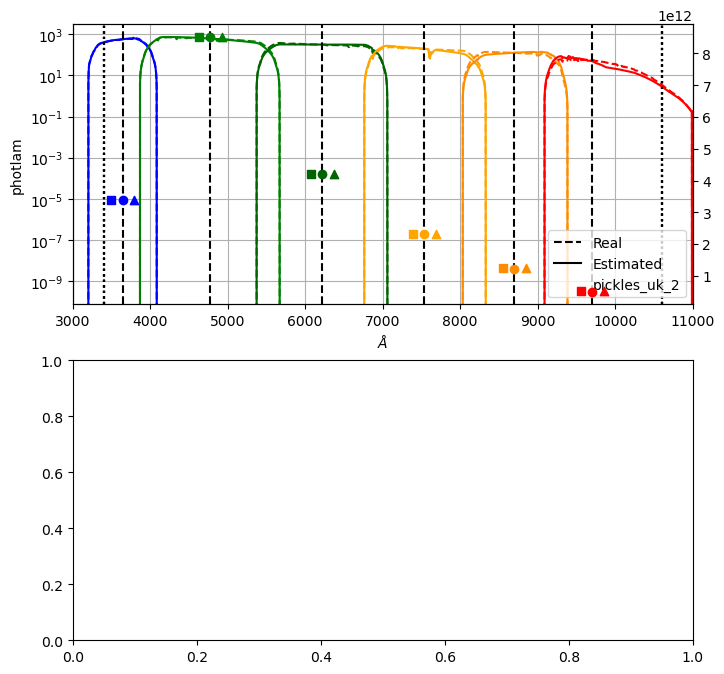

In [308]:

fig,axs = plt.subplots(len(bad_ids_)+1,figsize=(8,(len(bad_ids_)+1)*4))

for i,id_ in enumerate(bad_ids_):
    axs[i].grid()
    axs2 = axs[i].twinx()
    for j,filter_ in enumerate(filters):
        
        estim_spec_ = obs_estim_std_dict[id_][filter_]
        spec_ = obs_flux_std_dict[id_][filter_]
        spec.convert('photlam')
        axs[i].plot(spec_.wave,spec_.flux,ls='--',color=filter_colors[j],alpha=1.0)
        axs[i].plot(estim_spec_.wave,estim_spec_.flux,ls='-',color=filter_colors[j],alpha=1.0)
        axs[i].axvline(x=WLMIN,ls=':',color='k')
        axs[i].axvline(x=WLMAX,ls=':',color='k')
        axs[i].set_xlim(3000,11000)
        #axs[i].set_ylim(10,10000)
        axs[i].set_yscale("log")
        axs[i].set_xlabel(wavelabel)
        axs[i].set_ylabel(spec.fluxunits)
        
        axs[i].axvline(x=eff_lambda[filter_],ls='--',color='k')
        
        axs2.scatter(eff_lambda[filter_],phi_std_dict[id_][filter_],marker='o',color=filter_colors[j])
        axs2.scatter(eff_lambda[filter_]-150.,Phi_std_dict[id_][filter_][max_ind_],marker='s',color=filter_colors[j])
        axs2.scatter(eff_lambda[filter_]+150.,phi_corr_dict[id_][filter_][max_ind_],marker='^',color=filter_colors[j])
        
    axs[i].plot([],[],ls='--',color='k',label='Real')
    axs[i].plot([],[],ls='-',color='k',label='Estimated')
    axs[i].plot([],[],ls='',marker='',label=id_)
    axs[i].legend(loc="lower right")
    
    
